# Transient and Secular Equilibrium in U-238 Decay Chain

## Alessandro Selmi
### Bachelor's Thesis in Physics @ University of Pavia
### April 2024

---

Analysis of radioactive equilibria establishing in the U-238 decay chain, particularly across
Rn-222, Po-218, Pb-214 and Bi-214. Numerical modelling of radioactive decay chains through
the Bateman differential equations and least-squares fitting to experimental decay data.



*Note: This notebook contains the original code used for my Bachelor's degree.
Documentation is in English, while code comments are in Italian.*

#Import librerie

In [ ]:
# (c) 2024, Alessandro Selmi

import numpy as np
import math as mt
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
import sympy as sp
import os
import pandas as pd
! pip install numpy-indexed
import numpy_indexed as npi
! pip install lmfit
from lmfit import minimize, Parameters, Parameter, report_fit
from scipy import optimize as sop
from scipy import constants as scc
from scipy.optimize import curve_fit
from scipy import odr
from scipy.integrate import odeint
from scipy import integrate
from scipy import interpolate as itp
from ipywidgets import interact, interact_manual, FloatSlider, Checkbox, BoundedFloatText
from google.colab import files
from google.colab import drive
drive.mount('/content/drive')
#import uncertainties as unc
#import uncertainties.unumpy as unumpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.7/97.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.6 MB/s eta 0:00:00
Mounted at /content/drive


# Spettro Ra226

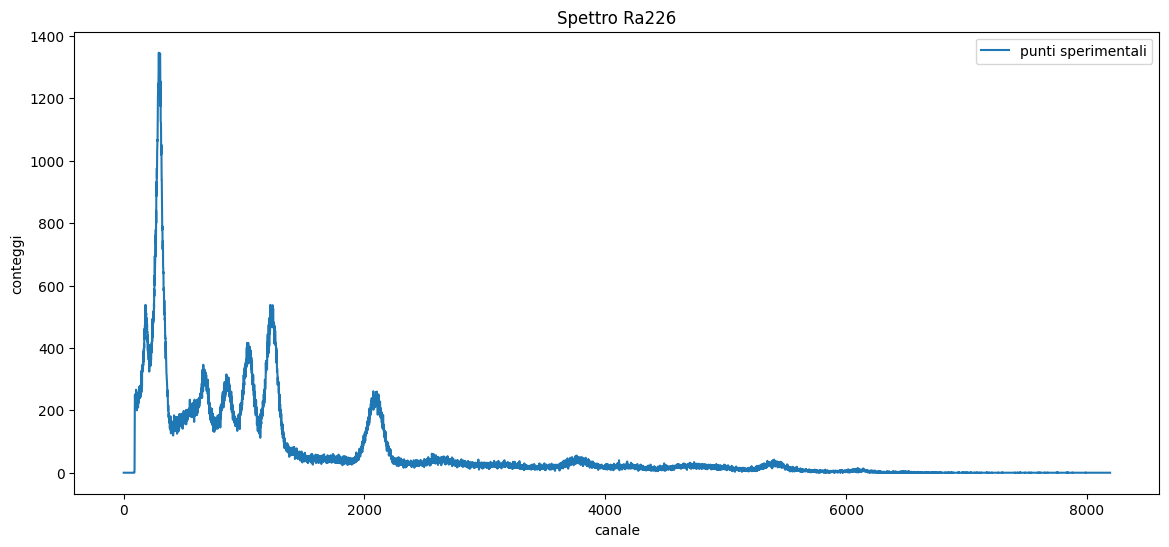

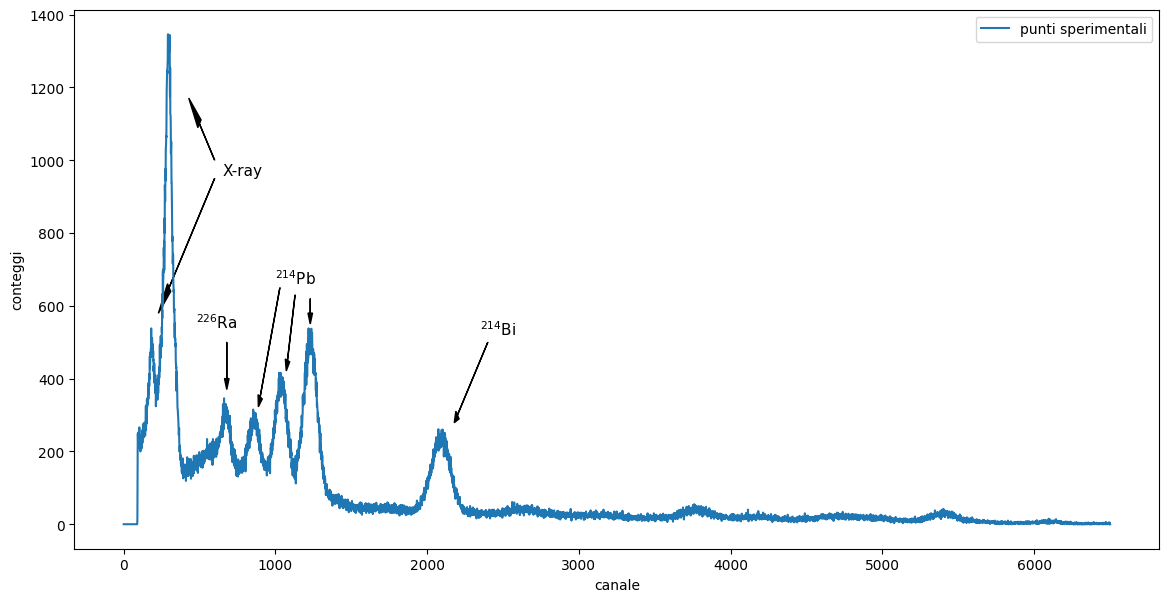

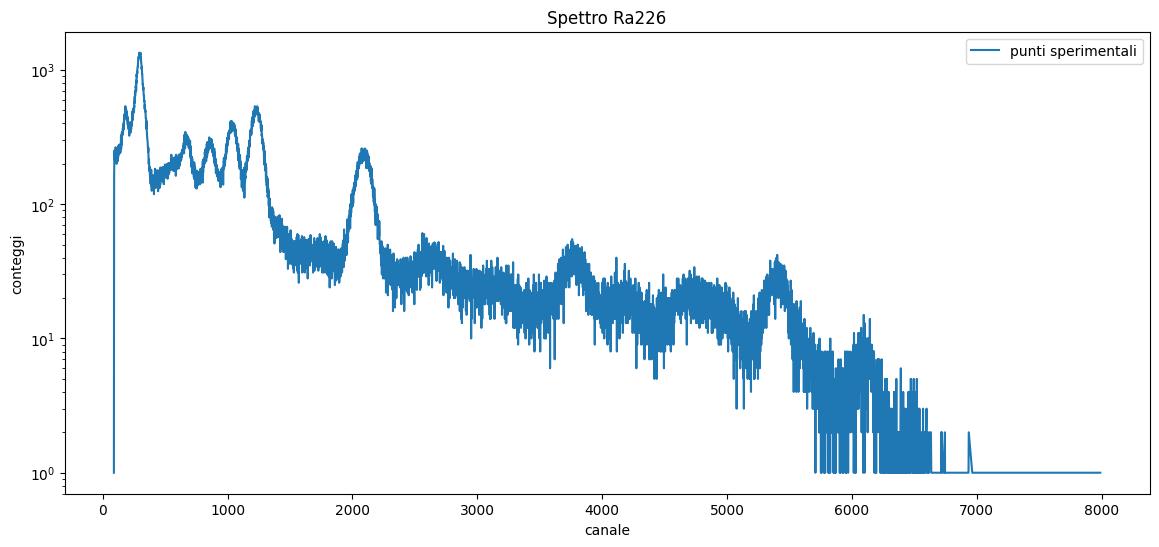

In [ ]:
dati_sp=np.loadtxt('/content/drive/MyDrive/Tesi/DatiSperimentali/Spettro/Ra226spe.txt', dtype=float, delimiter="\t", skiprows=0)
chan = np.arange(len(dati_sp))
#dati_sp=dati_sp[dati_sp[:] > 0]

plt.figure(figsize=(14,6))
plt.plot(chan+1, dati_sp, label='punti sperimentali')
plt.legend()
plt.xlabel(r"canale")
plt.ylabel(r"conteggi")
plt.title("Spettro Ra226")

plt.figure(figsize=(14,7))
plt.plot(chan[chan[:] < 6500] +1, dati_sp[chan[:] < 6500], label='punti sperimentali')
plt.legend()
plt.xlabel(r"canale")
plt.ylabel(r"conteggi")
#plt.title(r"Spettro gamma in presenza di $^{226}$Ra")

# (starting_x, starting_y, dx, dy, ...)
#adding text inside the plot
plt.text(650, 960, 'X-ray', fontsize = 11)
plt.arrow(600, 950, -300, -300, head_width=30, head_length=100, color='black')
plt.arrow(600, 1000, -100, 100, head_width=30, head_length=100, color='black')
#adding text inside the plot
plt.text(480, 540, '$^{226}$Ra', fontsize = 11)
plt.arrow(680, 500, 0, -100, head_width=30, head_length=30, color='black')
#adding text inside the plot
plt.text(1000, 660, '$^{214}$Pb', fontsize = 11)
plt.arrow(1030, 650, -130, -300, head_width=30, head_length=30, color='black')
plt.arrow(1130, 630, -50, -180, head_width=30, head_length=30, color='black')
plt.arrow(1230, 620, 0, -40, head_width=30, head_length=30, color='black')
#adding text inside the plot
plt.text(2350, 520, '$^{214}$Bi', fontsize = 11)
plt.arrow(2400, 500, -200, -200, head_width=30, head_length=30, color='black')
plt.show()

plt.figure(figsize=(14,6))
plt.plot(chan[dati_sp[:] > 0] +1, dati_sp[dati_sp[:] > 0], label='punti sperimentali')
plt.legend()
plt.xlabel(r"canale")
plt.ylabel(r"conteggi")
plt.title("Spettro Ra226")
plt.yscale('log')

# Modello teorico con soluzioni analitiche particolari

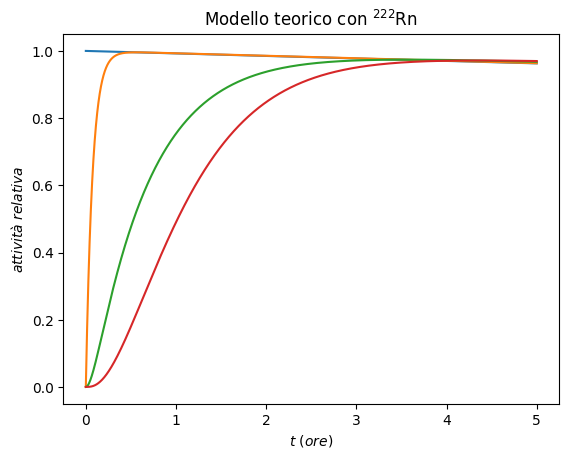

In [ ]:
#@title
lam0 = 2.10e-6*3600    # costante di decadimento del Rn 222 in Po 218 (h-1)
lam1 = 3.73e-3*3600    # costante di decadimento del Po 218 in Pb 214 (h-1)
lam2 = 4.27e-4*3600    # costante di decadimento del Pb 214 in Bi 214 (h-1)
lam3 = 5.86e-4*3600    # costante di decadimento del Bi 214 in Po 214 (h-1)

t = np.linspace(0, 5, 10000)

# attività
Ar0 = np.exp(-lam0 * t)
Ar1 = (lam1 / (lam1-lam0))*(np.exp(-lam0*t) - np.exp(-lam1*t))
Ar2 = lam1*lam2*((np.exp(-lam0*t)/((lam1-lam0)*(lam2-lam0)))-(np.exp(-lam1*t)/((lam1-lam0)*(lam2-lam1)))+(np.exp(-lam2*t)/((lam2-lam0)*(lam2-lam1))))
Ar3 = lam1*lam2*lam3*((np.exp(-lam0*t)/((lam1-lam0)*(lam2-lam0)*(lam3-lam0)))-(np.exp(-lam1*t)/((lam1-lam0)*(lam2-lam1)*(lam3-lam1)))+(np.exp(-lam2*t)/((lam2-lam0)*(lam2-lam1)*(lam3-lam2)))-(np.exp(-lam3*t)/((lam3-lam0)*(lam3-lam1)*(lam3-lam2))))


plt.figure()
plt.plot(t, Ar0)
plt.plot(t, Ar1)
plt.plot(t, Ar2)
plt.plot(t, Ar3)
plt.xlabel("$t \ (ore)$")
plt.ylabel(r"$attività \ relativa$")
plt.title(r"Modello teorico con $^{222}$Rn")

# To avoid matplotlib text output
plt.show()


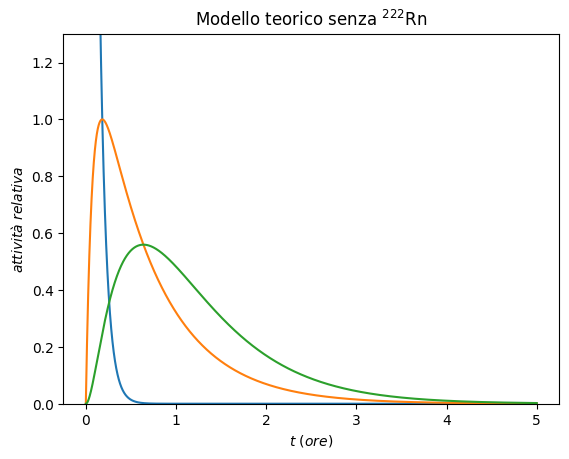

In [ ]:
#@title
lam0 = 2.10e-6*3600    # costante di decadimento del Rn 222 in Po 218 (h-1)
lam1 = 3.73e-3*3600    # costante di decadimento del Po 218 in Pb 214 (h-1)
lam2 = 4.27e-4*3600    # costante di decadimento del Pb 214 in Bi 214 (h-1)
lam3 = 5.86e-4*3600    # costante di decadimento del Bi 214 in Po 214 (h-1)

t = np.linspace(0, 5, 10000)

# attività
Art1 = np.exp(-lam1*t)
Art2 = (lam2/(lam2-lam1))*(np.exp(-lam1*t) - np.exp(-lam2*t))
Art3 = lam2*lam3*((np.exp(-lam1*t)/((lam2-lam1)*(lam3-lam1)))-(np.exp(-lam2*t)/((lam2-lam1)*(lam3-lam2)))+(np.exp(-lam3*t)/((lam3-lam1)*(lam3-lam2))))
Art1 = Art1/max(Art2)
Art3 = Art3/max(Art2)
Art2 = Art2/max(Art2)

plt.figure()
plt.plot(t, Art1)
plt.plot(t, Art2)
plt.plot(t, Art3)
plt.xlabel("$t \ (ore)$")
plt.ylabel(r"$attività \ relativa$")
plt.title(r"Modello teorico senza $^{222}$Rn")
plt.ylim([0,1.3])


# To avoid matplotlib text output
plt.show()

# Dati sperimentali e modello ode, senza Radon

## Modello con interpolazione secco

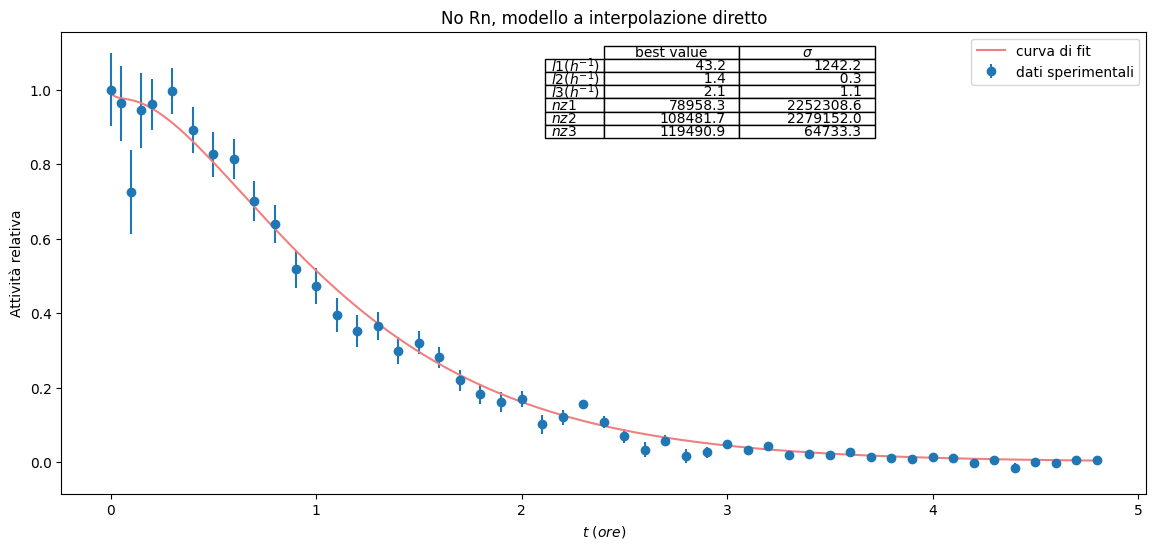

R2 = 0.9824


In [ ]:
#@title
# dati conteggi bismuto, no radon
# parametri di fit l1, l2, l3, nz1, nz2, nz3
# catena formata da Po218, Pb214, Bi214 (e Po214)
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy import integrate
from scipy import interpolate as itp

dati1=np.loadtxt('/content/drive/MyDrive/Tesi/DatiSperimentali/EqTran/Dati2_Bateman.txt', dtype=float, delimiter="\t", skiprows=0)
# !rm -r /content/drive.google.com
# dati in quattro colonne, formato    t (min) \ t (s) \ n cont \ inc cont
dati1[:,0] = dati1[:,0]/60       #     t (h)      "        "        "
ut = 0      # colonna da usare per le unità di tempo: 0 == ore, 1 == secondi
tmax = dati1[-1,ut]
A3_0 = dati1[0,2]
dati1[:,3] = dati1[:,3]/A3_0
dati1[:,2] = dati1[:,2]/A3_0


def eq3(ts, l1, l2, l3, nz1, nz2, nz3):
     #-time-grid-----------------------------------
     t  = np.linspace(0, tmax, 10000)                            # per opzione interpolazione si può usare questo
     #differential-eq-system----------------------
     def funct(y,t):
        Nm1=y[0]
        Nm2=y[1]
        Nm3=y[2]
        # the model equations
        f1 = -l1*Nm1         # = dN1/dt
        f2 = -l2*Nm2+l1*Nm1
        f3 = -l3*Nm3+l2*Nm2
        return [f1, f2, f3]
     #integrate------------------------------------
     Nz = nz1,nz2,nz3
     N  = integrate.odeint(funct,Nz,t)

     #opzione interpolazione
     N3 = N[:,2]
     N3f= itp.interp1d(t,N3,'cubic',fill_value="extrapolate")
     n3 = N3f(ts)

     #A1 = l1*n[:,0]
     #A2 = l2*n[:,1]
     A3 = l3*n3                           # attività in cont/h se ut=0, in cont/s se ut=1
     A3 = A3/pow(3600,1-ut)               # attività in cont/s come dati sperimentali [l3*n3]=[cont/h]=[cont/(3600s)]
     A3 = A3/A3_0                         # normalizzazione
     return (A3)
eq3v=np.vectorize(eq3)


min=[5, 0.5, 0.7]/(pow(3600,ut)*np.ones(3))                  # minimum values for l1, l2, l3, nz1, nz2, nz3
min = np.hstack((min, [0, 0, 0]))
max=[100, 10, 15]/(pow(3600,ut)*np.ones(3))                  # maximum values for l1, l2, l3, nz1, nz2, nz3
max = np.hstack((max, [mt.inf, mt.inf, mt.inf]))
bounds=(min,max)
p0 = [13.42,1.536,2.109]/(pow(3600,ut)*np.ones(3))           # guess iniziali
p0 = np.hstack((p0, [100000,100000,100000]))
popt,  pcov = sop.curve_fit(eq3, dati1[:,ut], dati1[:,2], p0=p0, sigma=dati1[:,3], bounds=bounds)      # p0=[13.42,1.536,2.109,1700,1600,1800]  p0=[40,1.2,2,100,10,35]
ndata = len(dati1[:,0])
l1 = popt[0]
l2 = popt[1]
l3 = popt[2]
nz1= popt[3]
nz2= popt[4]
nz3= popt[5]
standard_error1 = np.sqrt(np.diag(pcov))
sigma = np.sqrt(ndata*np.diag(pcov))

# calcolo il coefficiente R2 per valutare la bontà del fit
ts = dati1[:,ut]
y  = dati1[:,2]
tfit=np.linspace(0, tmax, num=1000)
residuals = y - eq3(ts,popt[0],popt[1],popt[2],popt[3],popt[4],popt[5])
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y-np.mean(y))**2)
r_squared = 1 - (ss_res / ss_tot)


plt.figure(figsize=(14,6))
plt.errorbar(dati1[:,ut], dati1[:,2], yerr=dati1[:,3], marker='o', fmt='', linestyle='', label='dati sperimentali')
plt.plot(tfit, eq3(tfit,l1,l2,l3,nz1,nz2,nz3), color='lightcoral', label='curva di fit')
plt.legend()
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività relativa")
#plt.title("Dati sperimentali e fit senza Radon")
plt.title("No Rn, modello a interpolazione diretto")

# tabella parametri fit
rows = [r"$l1 (h^{-1})$", r"$l2 (h^{-1})$", r"$l3 (h^{-1})$", r"$nz1$", r"$nz2$", r"$nz3$"]
cols = [r"best value", r"$ \sigma $"]
w, h = 2, 6
O = [[0 for x in range(w)] for y in range(h)]
for h in range(0,6):
  O[h][0]="%5.1f"%(popt[h])
  O[h][1]="%5.1f"%(standard_error1[h])
  #O[h][1]="%5.4f"%(sigma[h])
plt.table(cellText=O[:], rowLabels=rows, colLabels=cols,loc='top', bbox=[0.5,0.77,0.25,0.2])

plt.show()
print("R2 = %2.4f" %(r_squared))

lam1 = 13.43 h-1
lam3 = 2.11 h-1


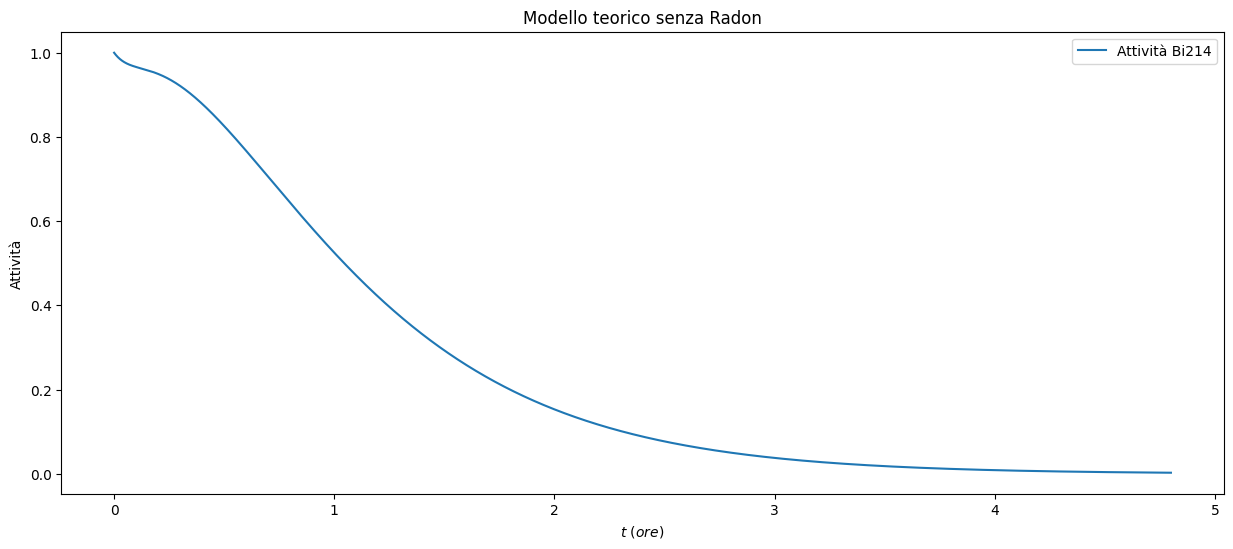

In [ ]:
#@title
# simulazione numerica no Rn

#lam0 = 2.10e-6*3600    # costante di decadimento del Rn 222 in Po 218 (h-1)
lam1 = 3.73e-3*3600    # costante di decadimento del Po 218 in Pb 214 (h-1)
lam2 = 4.27e-4*3600    # costante di decadimento del Pb 214 in Bi 214 (h-1)
lam3 = 5.86e-4*3600    # costante di decadimento del Bi 214 in Po 214 (h-1)
#lam1 = l1
#lam2 = l2
#lam3 = l3

# numero di nuclei iniziali
N1_0 = nz1
N2_0 = nz2
N3_0 = nz3

Dur = tmax        # durata osservazione in ore
Nt = 10000     # numero osservazioni temporali
t = np.linspace(0, Dur, Nt)

N1 = np.zeros(Nt)
N2 = np.zeros(Nt)
N3 = np.zeros(Nt)
dN1dt = np.zeros(Nt)
dN2dt = np.zeros(Nt)
dN3dt = np.zeros(Nt)
A1 = np.zeros(Nt)
A2 = np.zeros(Nt)
A3 = np.zeros(Nt)

N1[0] = N1_0
N2[0] = N2_0
N3[0] = N3_0

for i in range(0,Nt-1):
  dN1dt[i] = -lam1*N1[i]
  dN2dt[i] = -lam2*N2[i]+lam1*N1[i]
  dN3dt[i] = -lam3*N3[i]+lam2*N2[i]
  A1[i] = lam1*N1[i]/pow(3600,1-ut)
  A2[i] = lam2*N2[i]/pow(3600,1-ut)
  A3[i] = lam3*N3[i]/pow(3600,1-ut)
  N1[i+1] = N1[i]+dN1dt[i]*Dur/(Nt-1)
  N2[i+1] = N2[i]+dN2dt[i]*Dur/(Nt-1)
  N3[i+1] = N3[i]+dN3dt[i]*Dur/(Nt-1)
dN1dt[Nt-1] = -lam1*N1[Nt-1]
dN2dt[Nt-1] = -lam2*N2[Nt-1]+lam1*N1[Nt-1]
dN3dt[Nt-1] = -lam3*N3[Nt-1]+lam2*N2[Nt-1]
A1[Nt-1] = lam1*N1[Nt-1]/pow(3600,1-ut)
A2[Nt-1] = lam2*N2[Nt-1]/pow(3600,1-ut)
A3[Nt-1] = lam3*N3[Nt-1]/pow(3600,1-ut)

plt.figure(figsize=(15,6))
#plt.plot(t, A1/A3[0], label='Attività Po218')
#plt.plot(t, A2/A3[0], label='Attività Pb214')
plt.plot(t, A3/A3[0], label='Attività Bi214')
plt.title("Modello teorico senza Radon")
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività")
#plt.ylim([0,25])
#plt.yscale('log')
plt.legend()

print("lam1 = %2.2f h-1" %(lam1))
print("lam3 = %2.2f h-1" %(lam3))

# To avoid matplotlib text output
plt.show()

## Modello a doppio linspace secco

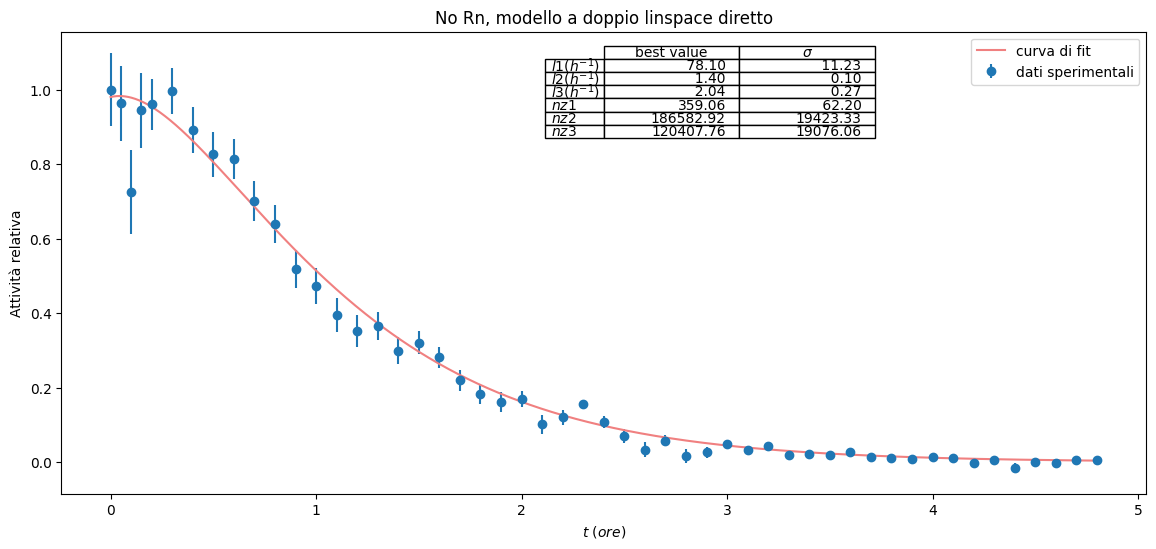

R2 = 0.9818


In [ ]:
#@title
# dati conteggi bismuto, no radon
# parametri di fit l1, l2, l3, nz1, nz2, nz3
# catena formata da Po218, Pb214, Bi214 (e Po214)

dati1=np.loadtxt('/content/drive/MyDrive/Tesi/DatiSperimentali/EqTran/Dati2_Bateman.txt', dtype=float, delimiter="\t", skiprows=0)
# !rm -r /content/drive.google.com
# dati in quattro colonne, formato    t (min) \ t (s) \ n cont \ inc cont
dati1[:,0] = dati1[:,0]/60       #     t (h)      "        "        "
ut = 0      # colonna da usare per le unità di tempo: 0 == ore, 1 == secondi
tmax = dati1[-1,ut]
A3_0 = dati1[0,2]
dati1[:,3] = dati1[:,3]/A3_0
dati1[:,2] = dati1[:,2]/A3_0

lam1 = 3.73e-3*3600    # costante di decadimento del Po 218 in Pb 214 (h-1)
nt = 30000    # numero di osservazioni temporali in ognuno dei due linspace


def eq3(ts, l1, l2, l3, nz1, nz2, nz3):
     #-time-grid-----------------------------------
     t1 = np.linspace(0, ts, nt)
     t2 = np.linspace(ts, tmax, nt)
     t = np.hstack((t1, t2))        # ts in posizione nt
     #print(np.shape(t))
     #differential-eq-system----------------------
     def funct(y,t):
        Nm1=y[0]
        Nm2=y[1]
        Nm3=y[2]
        # the model equations
        f1 = -l1*Nm1         # = dN1/dt
        f2 = -l2*Nm2+l1*Nm1
        f3 = -l3*Nm3+l2*Nm2
        return [f1, f2, f3]
     #integrate------------------------------------
     Nz = nz1,nz2,nz3
     N  = integrate.odeint(funct,Nz,t)
     n3 = N[nt,2]

     #A1 = l1*n[:,0]
     #A2 = l2*n[:,1]
     A3 = l3*n3                           # attività in cont/h se ut=0, in cont/s se ut=1
     A3 = A3/pow(3600,1-ut)               # attività in cont/s come dati sperimentali [l3*n3]=[cont/h]=[cont/(3600s)]
     A3 = A3/A3_0                         # normalizzazione
     return (A3)
eq3v=np.vectorize(eq3)


min=[5, 0.5, 0.7, 0, 0, 0]                  # minimum values for l1, l2, l3, nz1, nz2, nz3
max=[100, 10, 15, mt.inf, mt.inf, mt.inf]   # maximum values for l1, l2, l3, nz1, nz2, nz3
bounds=(min,max)
popt,  pcov = sop.curve_fit(eq3v, dati1[:,0], dati1[:,2], p0=[13.42,1.536,2.109,10000,10000,10000], sigma=dati1[:,3], bounds=bounds)      # p0=[13.42,1.536,2.109,100,100,35]
ndata = len(dati1[:,0])
l1 = popt[0]
l2 = popt[1]
l3 = popt[2]
nz1= popt[3]
nz2= popt[4]
nz3= popt[5]
standard_error1 = np.sqrt(np.diag(pcov))
sigma = np.sqrt(ndata*np.diag(pcov))

# calcolo il coefficiente R2 per valutare la bontà del fit
ts = dati1[:,0]
y  = dati1[:,2]
tfit=np.linspace(0, tmax, num=1000)
residuals = y - eq3v(ts,popt[0],popt[1],popt[2],popt[3],popt[4],popt[5])
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y-np.mean(y))**2)
r_squared = 1 - (ss_res / ss_tot)


plt.figure(figsize=(14,6))
plt.errorbar(dati1[:,0], dati1[:,2], yerr=dati1[:,3], marker='o', fmt='', linestyle='', label='dati sperimentali')
plt.plot(tfit, eq3v(tfit,l1,l2,l3,nz1,nz2,nz3), color='lightcoral', label='curva di fit')
plt.legend()
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività relativa")
#plt.title("Dati sperimentali e fit senza Radon")
plt.title("No Rn, modello a doppio linspace diretto")

# tabella parametri fit
rows = [r"$l1 (h^{-1})$", r"$l2 (h^{-1})$", r"$l3 (h^{-1})$", r"$nz1$", r"$nz2$", r"$nz3$"]
cols = [r"best value", r"$ \sigma $"]
w, h = 2, 6
O = [[0 for x in range(w)] for y in range(h)]
for h in range(0,6):
  O[h][0]="%6.2f"%(popt[h])
  O[h][1]="%6.2f"%(standard_error1[h])
  #O[h][1]="%5.4f"%(sigma[h])
plt.table(cellText=O[:], rowLabels=rows, colLabels=cols,loc='top', bbox=[0.5,0.77,0.25,0.2])

plt.show()
print("R2 = %2.4f" %(r_squared))

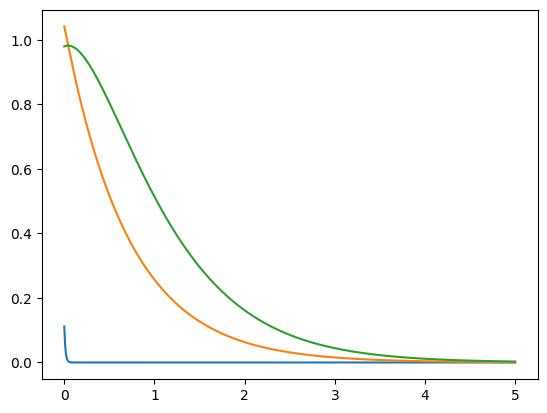

In [ ]:
#@title
#differential-eq-system----------------------
t  = np.linspace(0, mt.ceil(tmax), 100*mt.ceil(tmax)+1)
def funct(y,t):
        Nm1=y[0]
        Nm2=y[1]
        Nm3=y[2]
        # the model equations
        f1 = -l1*Nm1         # = dN1/dt
        f2 = -l2*Nm2+l1*Nm1
        f3 = -l3*Nm3+l2*Nm2
        return [f1, f2, f3]
#integrate------------------------------------
Nz = nz1,nz2,nz3
N  = integrate.odeint(funct,Nz,t)
#print(N)
plt.figure()
plt.plot(t, l1*N[:,0]/3600/A3_0)
plt.plot(t, l2*N[:,1]/3600/A3_0)
plt.plot(t, l3*N[:,2]/3600/A3_0)

## Modello a interpolazione a due step

R2 = 0.9896, 0.9896


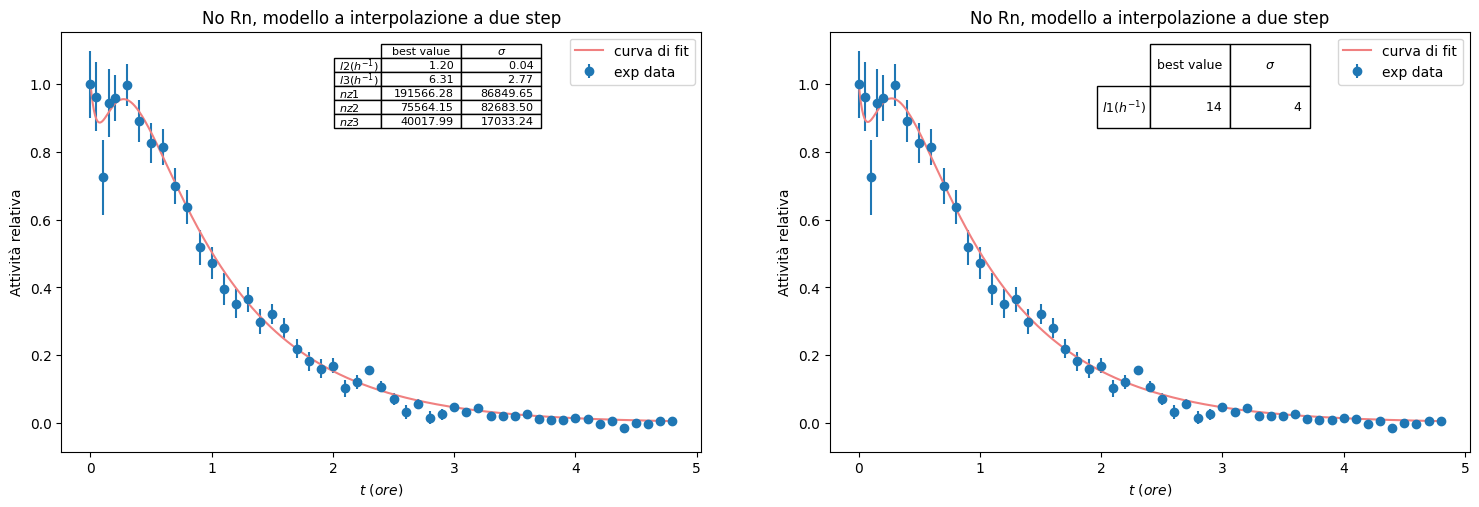

In [ ]:
#@title
# dati conteggi bismuto, no radon
# parametri di fit l2, l3, nz1, nz2, nz3 con lam1 tabulato
# catena formata da Po218, Pb214, Bi214 (e Po214)
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy import integrate
from scipy import interpolate as itp

dati1=np.loadtxt('/content/drive/MyDrive/Tesi/DatiSperimentali/EqTran/Dati2_Bateman.txt', dtype=float, delimiter="\t", skiprows=0)
# !rm -r /content/drive.google.com
# dati in quattro colonne, formato    t (min) \ t (s) \ n cont \ inc cont
dati1[:,0] = dati1[:,0]/60       #     t (h)      "        "        "
ut = 0      # colonna da usare per le unità di tempo: 0 == ore, 1 == secondi
tmax = dati1[-1,ut]
A3_0 = dati1[0,2]
dati1[:,3] = dati1[:,3]/A3_0
dati1[:,2] = dati1[:,2]/A3_0


lam1 = 3.73e-3*3600    # costante di decadimento del Po 218 in Pb 214 (h-1)

def eq3(ts, l2, l3, nz1, nz2, nz3):
     #-time-grid-----------------------------------
     t  = np.linspace(0, tmax, 50000)                            # per opzione interpolazione si può usare questo
     #differential-eq-system----------------------
     def funct(y,t):
        Nm1=y[0]
        Nm2=y[1]
        Nm3=y[2]
        # the model equations
        f1 = -lam1*Nm1         # = dN1/dt
        f2 = -l2*Nm2+lam1*Nm1
        f3 = -l3*Nm3+l2*Nm2
        return [f1, f2, f3]
     #integrate------------------------------------
     Nz = nz1,nz2,nz3
     N  = integrate.odeint(funct,Nz,t)

     #opzione interpolazione
     N3 = N[:,2]
     N3f= itp.interp1d(t,N3,'cubic',fill_value="extrapolate")
     n3 = N3f(ts)

     #A1 = l1*n[:,0]
     #A2 = l2*n[:,1]
     A3 = l3*n3                           # attività in cont/h se ut=0, in cont/s se ut=1
     A3 = A3/pow(3600,1-ut)               # attività in cont/s come dati sperimentali [l3*n3]=[cont/h]=[cont/(3600s)]
     A3 = A3/A3_0                         # normalizzazione
     return (A3)
eq3v=np.vectorize(eq3)


min=[0.5, 0.7]/(pow(3600,ut)*np.ones(2))                  # minimum values for l2, l3, nz1, nz2, nz3
min = np.hstack((min, [0, 0, 0]))
max=[10, 15]/(pow(3600,ut)*np.ones(2))                    # maximum values for l2, l3, nz1, nz2, nz3
max = np.hstack((max, [mt.inf, mt.inf, mt.inf]))
bounds=(min,max)
p0 = [1.536,2.109]/(pow(3600,ut)*np.ones(2))              # guess iniziali
p0 = np.hstack((p0, [100000,100000,100000]))                                                                        # p0=[1.536,2.109,1700,1600,1800]
popt,  pcov = sop.curve_fit(eq3, dati1[:,ut], dati1[:,2], p0=p0, sigma=dati1[:,3], bounds=bounds)
ndata = len(dati1[:,0])
l2 = popt[0]
l3 = popt[1]
nz1= popt[2]
nz2= popt[3]
nz3= popt[4]
standard_error1 = np.sqrt(np.diag(pcov))
sigma = np.sqrt(ndata*np.diag(pcov))

# calcolo il coefficiente R2 per valutare la bontà del fit
ts = dati1[:,ut]
y  = dati1[:,2]
tfit=np.linspace(0, tmax, num=1000)
residuals = y - eq3(ts,popt[0],popt[1],popt[2],popt[3],popt[4])
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y-np.mean(y))**2)
r_squared_1 = 1 - (ss_res / ss_tot)


plt.figure(figsize=(38,12))
plt.subplot(241)
plt.errorbar(dati1[:,ut], dati1[:,2], yerr=dati1[:,3], marker='o', fmt='', linestyle='', label='exp data')
plt.plot(tfit, eq3(tfit,l2,l3,nz1,nz2,nz3), color='lightcoral', label='curva di fit')
plt.legend()
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività relativa")
#plt.title("Dati sperimentali e fit senza Radon")
plt.title("No Rn, modello a interpolazione a due step")

# tabella parametri fit
rows = [r"$l2 (h^{-1})$", r"$l3 (h^{-1})$", r"$nz1$", r"$nz2$", r"$nz3$"]
cols = [r"best value", r"$ \sigma $"]
w, h = 2, 5
O = [[0 for x in range(w)] for y in range(h)]
for h in range(0,5):
  O[h][0]="%6.2f"%(popt[h])
  O[h][1]="%6.2f"%(standard_error1[h])
  #O[h][1]="%5.4f"%(sigma[h])
plt.table(cellText=O[:], rowLabels=rows, colLabels=cols,loc='top', bbox=[0.5,0.77,0.25,0.2])

#print("R2 = %2.4f" %(r_squared))


#-di-nuovo----------------------------------------------------------------
# parametro di fit l1 con parametri l2, l3, nz1, nz2, nz3 di prima fissati

def eqq3(ts, l1):
     #-time-grid-----------------------------------
     t  = np.linspace(0, tmax, 10000)                            # per opzione interpolazione si può usare questo
     #differential-eq-system----------------------
     def funct(y,t):
        Nm1=y[0]
        Nm2=y[1]
        Nm3=y[2]
        # the model equations
        f1 = -l1*Nm1         # = dN1/dt
        f2 = -l2*Nm2+l1*Nm1
        f3 = -l3*Nm3+l2*Nm2
        return [f1, f2, f3]
     #integrate------------------------------------
     Nz = nz1,nz2,nz3
     N  = integrate.odeint(funct,Nz,t)

     #opzione interpolazione
     N3 = N[:,2]
     N3f= itp.interp1d(t,N3,'cubic',fill_value="extrapolate")
     n3 = N3f(ts)

     #A1 = l1*n[:,0]
     #A2 = l2*n[:,1]
     A3 = l3*n3                           # attività in cont/h se ut=0, in cont/s se ut=1
     A3 = A3/pow(3600,1-ut)               # attività in cont/s come dati sperimentali [l3*n3]=[cont/h]=[cont/(3600s)]
     A3 = A3/A3_0
     return (A3)
eqq3v=np.vectorize(eqq3)

min=5/pow(3600,ut)                    # minimum value for l1
max=100/pow(3600,ut)                  # maximum value for l1
bounds=(min,max)
p0 = 13.42/pow(3600,ut)               # guess iniziale 13.42
popt,  pcov = sop.curve_fit(eqq3, dati1[:,ut], dati1[:,2], p0=p0, sigma=dati1[:,3], bounds=bounds)
ndata = len(dati1[:,0])
l1 = popt[0]
standard_error1 = np.sqrt(np.diag(pcov))
sigma = np.sqrt(ndata*np.diag(pcov))

# calcolo il coefficiente R2 per valutare la bontà del fit
ts = dati1[:,ut]
y  = dati1[:,2]
tfit=np.linspace(0, tmax, num=1000)
residuals = y - eqq3(ts,popt[0])
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y-np.mean(y))**2)
r_squared = 1 - (ss_res / ss_tot)
print("R2 = %2.4f, %2.4f" %(r_squared_1, r_squared))

plt.subplot(242)
plt.errorbar(dati1[:,ut], dati1[:,2], yerr=dati1[:,3], marker='o', fmt='', linestyle='', label='exp data')
plt.plot(tfit, eqq3(tfit,l1), color='lightcoral', label='curva di fit')
plt.legend()
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività relativa")
#plt.title("Dati sperimentali e fit senza Radon")
plt.title("No Rn, modello a interpolazione a due step")

# tabella parametri fit
rows = [r"$l1 (h^{-1})$"]
cols = [r"best value", r"$ \sigma $"]
w, h = 2, 1
O = [[0 for x in range(w)] for y in range(h)]
for h in range(0,1):
  O[h][0]="%6.0f"%(popt[h])
  O[h][1]="%6.0f"%(standard_error1[h])
  #O[h][1]="%5.4f"%(sigma[h])
plt.table(cellText=O[:], rowLabels=rows, colLabels=cols,loc='top', bbox=[0.5,0.77,0.25,0.2])

plt.show()

## Modello a doppio linspace a due step

R2 = 0.9896, 0.9896


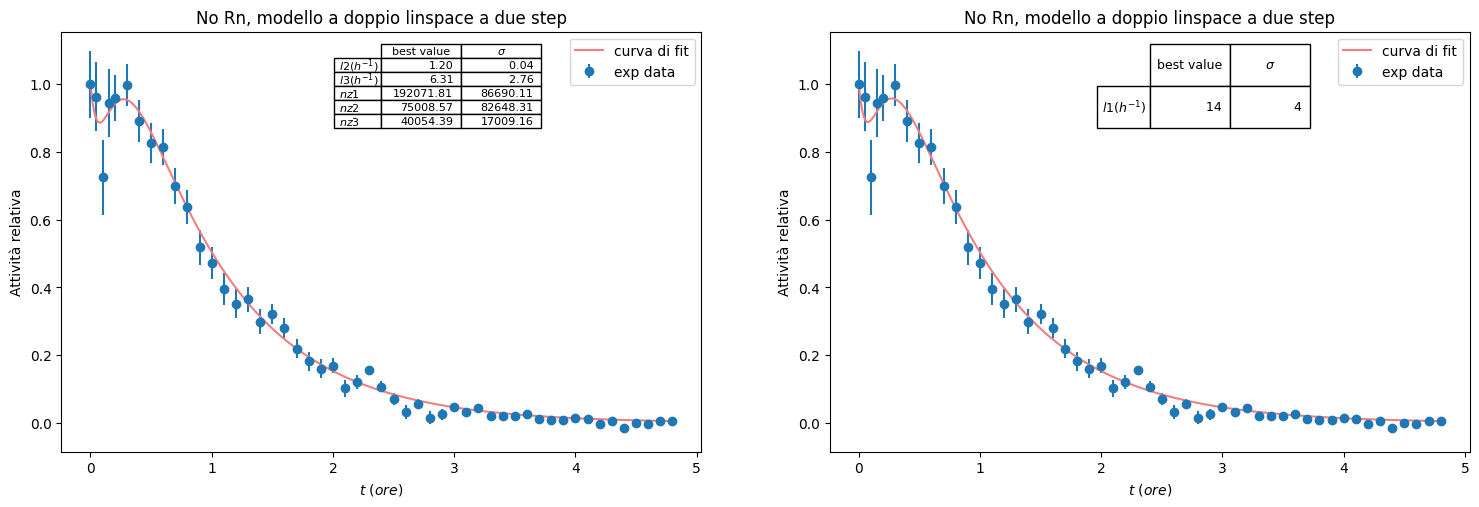

In [ ]:
#@title
# dati conteggi bismuto, no radon
# parametri di fit l2, l3, nz1, nz2, nz3 con lam1 tabulato
# catena formata da Po218, Pb214, Bi214 (e Po214)

dati1=np.loadtxt('/content/drive/MyDrive/Tesi/DatiSperimentali/EqTran/Dati2_Bateman.txt', dtype=float, delimiter="\t", skiprows=0)
# !rm -r /content/drive.google.com
# dati in quattro colonne, formato    t (min) \ t (s) \ n cont \ inc cont
dati1[:,0] = dati1[:,0]/60       #     t (h)      "        "        "
ut = 0      # colonna da usare per le unità di tempo: 0 == ore, 1 == secondi
tmax = dati1[-1,ut]
A3_0 = dati1[0,2]
dati1[:,3] = dati1[:,3]/A3_0
dati1[:,2] = dati1[:,2]/A3_0

lam1 = 3.73e-3*3600    # costante di decadimento del Po 218 in Pb 214 (h-1)
nt = 10000    # numero di osservazioni temporali in ognuno dei due linspace

def eq3(ts, l2, l3, nz1, nz2, nz3):
     #-time-grid-----------------------------------
     t1 = np.linspace(0, ts, nt)
     t2 = np.linspace(ts, tmax, nt)
     t = np.hstack((t1, t2))        # ts in posizione nt
     #print(np.shape(t))
     #differential-eq-system----------------------
     def funct(y,t):
        Nm1=y[0]
        Nm2=y[1]
        Nm3=y[2]
        # the model equations
        f1 = -lam1*Nm1         # = dN1/dt
        f2 = -l2*Nm2+lam1*Nm1
        f3 = -l3*Nm3+l2*Nm2
        return [f1, f2, f3]
     #integrate------------------------------------
     Nz = nz1,nz2,nz3
     N  = integrate.odeint(funct,Nz,t)
     n3 = N[nt,2]

     #A1 = l1*n[:,0]
     #A2 = l2*n[:,1]
     A3 = l3*n3                           # attività in cont/h se ut=0, in cont/s se ut=1
     A3 = A3/pow(3600,1-ut)               # attività in cont/s come dati sperimentali [l3*n3]=[cont/h]=[cont/(3600s)]
     A3 = A3/A3_0
     return (A3)
eq3v=np.vectorize(eq3)


min=[0.5, 0.7]/(pow(3600,ut)*np.ones(2))                  # minimum values for l2, l3, nz1, nz2, nz3
min = np.hstack((min, [0, 0, 0]))
max=[10, 15]/(pow(3600,ut)*np.ones(2))                    # maximum values for l2, l3, nz1, nz2, nz3
max = np.hstack((max, [mt.inf, mt.inf, mt.inf]))
bounds=(min,max)
p0 = [1.536,2.109]/(pow(3600,ut)*np.ones(2))              # guess iniziali
p0 = np.hstack((p0, [100000,100000,100000]))                                                                        # p0=[1.536,2.109,1700,1600,1800]
popt,  pcov = sop.curve_fit(eq3v, dati1[:,ut], dati1[:,2], p0=p0, sigma=dati1[:,3], bounds=bounds)
ndata = len(dati1[:,0])
l2 = popt[0]
l3 = popt[1]
nz1= popt[2]
nz2= popt[3]
nz3= popt[4]
standard_error1 = np.sqrt(np.diag(pcov))
sigma = np.sqrt(ndata*np.diag(pcov))

# calcolo il coefficiente R2 per valutare la bontà del fit
ts = dati1[:,ut]
y  = dati1[:,2]
tfit=np.linspace(0, tmax, num=1000)
residuals = y - eq3v(ts,popt[0],popt[1],popt[2],popt[3],popt[4])
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y-np.mean(y))**2)
r_squared_1 = 1 - (ss_res / ss_tot)


plt.figure(figsize=(38,12))
plt.subplot(241)
plt.errorbar(dati1[:,ut], dati1[:,2], yerr=dati1[:,3], marker='o', fmt='', linestyle='', label='exp data')
plt.plot(tfit, eq3v(tfit,l2,l3,nz1,nz2,nz3), color='lightcoral', label='curva di fit')
plt.legend()
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività relativa")
#plt.title("Dati sperimentali e fit senza Radon")
plt.title("No Rn, modello a doppio linspace a due step")

# tabella parametri fit
rows = [r"$l2 (h^{-1})$", r"$l3 (h^{-1})$", r"$nz1$", r"$nz2$", r"$nz3$"]
cols = [r"best value", r"$ \sigma $"]
w, h = 2, 5
O = [[0 for x in range(w)] for y in range(h)]
for h in range(0,5):
  O[h][0]="%4.2f"%(popt[h])
  O[h][1]="%6.2f"%(standard_error1[h])
  #O[h][1]="%5.4f"%(sigma[h])
plt.table(cellText=O[:], rowLabels=rows, colLabels=cols,loc='top', bbox=[0.5,0.77,0.25,0.2])

#print("R2 = %2.4f" %(r_squared_1))


#-di-nuovo----------------------------------------------------------------
# parametro di fit l1 con parametri l2, l3, nz1, nz2, nz3 di prima fissati

def eqq3(ts, l1):
     #-time-grid-----------------------------------
     t1 = np.linspace(0, ts, nt)
     t2 = np.linspace(ts, tmax, nt)
     t = np.hstack((t1, t2))        # ts in posizione nt
     #print(np.shape(t))
     #differential-eq-system----------------------
     def funct(y,t):
        Nm1=y[0]
        Nm2=y[1]
        Nm3=y[2]
        # the model equations
        f1 = -l1*Nm1         # = dN1/dt
        f2 = -l2*Nm2+l1*Nm1
        f3 = -l3*Nm3+l2*Nm2
        return [f1, f2, f3]
     #integrate------------------------------------
     Nz = nz1,nz2,nz3
     N  = integrate.odeint(funct,Nz,t)
     n3 = N[nt,2]

     #A1 = l1*n[:,0]
     #A2 = l2*n[:,1]
     A3 = l3*n3                           # attività in cont/h se ut=0, in cont/s se ut=1
     A3 = A3/pow(3600,1-ut)               # attività in cont/s come dati sperimentali [l3*n3]=[cont/h]=[cont/(3600s)]
     A3 = A3/A3_0                         # attività relativa
     return (A3)
eqq3v=np.vectorize(eqq3)

min=5/pow(3600,ut)                    # minimum value for l1
max=100/pow(3600,ut)                  # maximum value for l1
bounds=(min,max)
p0 = 40.00/pow(3600,ut)               # guess iniziale 13.42
popt,  pcov = sop.curve_fit(eqq3v, dati1[:,ut], dati1[:,2], p0=p0, sigma=dati1[:,3], bounds=bounds)
ndata = len(dati1[:,0])
l1 = popt[0]
standard_error1 = np.sqrt(np.diag(pcov))
sigma = np.sqrt(ndata*np.diag(pcov))

# calcolo il coefficiente R2 per valutare la bontà del fit
ts = dati1[:,ut]
y  = dati1[:,2]
tfit=np.linspace(0, tmax, num=1000)
residuals = y - eqq3v(ts,popt[0])
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y-np.mean(y))**2)
r_squared = 1 - (ss_res / ss_tot)
print("R2 = %2.4f, %2.4f" %(r_squared_1, r_squared))

plt.subplot(242)
plt.errorbar(dati1[:,ut], dati1[:,2], yerr=dati1[:,3], marker='o', fmt='', linestyle='', label='exp data')
plt.plot(tfit, eqq3v(tfit,l1), color='lightcoral', label='curva di fit')
plt.legend()
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività relativa")
#plt.title("Dati sperimentali e fit senza Radon")
plt.title("No Rn, modello a doppio linspace a due step")

# tabella parametri fit
rows = [r"$l1 (h^{-1})$"]
cols = [r"best value", r"$ \sigma $"]
w, h = 2, 1
O = [[0 for x in range(w)] for y in range(h)]
for h in range(0,1):
  O[h][0]="%4.0f"%(popt[h])
  O[h][1]="%6.0f"%(standard_error1[h])
  #O[h][1]="%5.4f"%(sigma[h])
plt.table(cellText=O[:], rowLabels=rows, colLabels=cols,loc='top', bbox=[0.5,0.77,0.25,0.2])

plt.show()

## Modello Giacomo Salsi

Parameters([('N1_0', <Parameter 'N1_0', value=10000.0, bounds=[0:inf]>), ('N2_0', <Parameter 'N2_0', value=10000.0, bounds=[0:inf]>), ('N3_0', <Parameter 'N3_0', value=10000.0, bounds=[0:inf]>), ('l_Po', <Parameter 'l_Po', value=13.425896028414595, bounds=[0:inf]>), ('l_Pb', <Parameter 'l_Pb', value=1.5365853658536586, bounds=[0:inf]>), ('l_Bi', <Parameter 'l_Bi', value=2.10958904109589, bounds=[0:inf]>)])
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 112
    # data points      = 51
    # variables        = 6
    chi-square         = 67.9318340
    reduced chi-square = 1.50959631
    Akaike info crit   = 26.6206355
    Bayesian info crit = 38.2115893
[[Variables]]
    N1_0:  216686.029 +/- 34903.1820 (16.11%) (init = 10000)
    N2_0:  617.764168 +/- 8516.16058 (1378.55%) (init = 10000)
    N3_0:  90218.3785 +/- 35486.1130 (39.33%) (init = 10000)
    l_Po:  123.656277 +/- 800.928154 (647.71%) (init = 13.4259)
    l_Pb:  1.29206794 +/- 0.11178809 (8.65%) (i

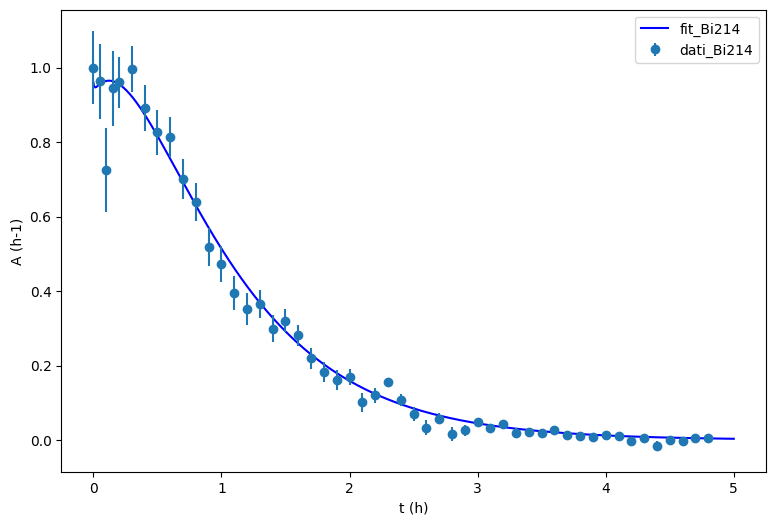

In [ ]:
# Script per la soluzione di un sistema di equazioni differenziali accoppiate e fit su dati sperimentali

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Load dei dati
data = np.loadtxt('/content/drive/MyDrive/Tesi/DatiSperimentali/EqTran/Dati2_Bateman.txt', dtype=float, delimiter="\t", skiprows=0)
data[:,0] = data[:,0]/60
A3_0 = data[0,2]
data[:,3] = data[:,3]/A3_0
data[:,2] = data[:,2]/A3_0
# dati in quattro colonne, formato    t (h) \ t (s) \ n cont/h \ inc cont/h


# Definizione del modello
def model(N, t, l):

	N1, N2, N3 = N
	l1, l2, l3 = l

	dN1dt = - l1 * N1
	dN2dt = - l2 * N2 + l1 * N1
	dN3dt = - l3 * N3 + l2 * N2

	dNdt = [dN1dt, dN2dt, dN3dt]

	return dNdt


# Soluzione delle equazioni differenziali
def risolvi(t, N_0, l):

	x = odeint(model, N_0, t, args = (l,) )

	return x



# Residui per il fit
def residui(paras, t, data, errors):

	N0 = paras['N1_0'].value, paras['N2_0'].value, paras['N3_0'].value
	l = paras['l_Po'].value, paras['l_Pb'].value, paras['l_Bi'].value
	model = risolvi(t, N0, l)

	N3_model = model[:, 2]
	#print(np.shape(N3_model))
	A3_model = N3_model*l[2]/3600
	Ar3_model= A3_model/A3_0
	#print(N3_model)

	# Definizione dei residui
	resids = Ar3_model - data
	weighted = np.sqrt(resids ** 2 / errors ** 2)
	return weighted




# Condizioni iniziali
N1_0 = 10000.
N2_0 = 10000.
N3_0 = 10000.

N_0 = (N1_0, N2_0, N3_0)

# Punti temporali
n = 10000                        # numero di punti
t = np.linspace(0, 5, n)

# Parametri:

# Tempi di dimezzamento isotopi (h)
hl_Po218 = 3.097/60
hl_Pb214 = 27.06/60
hl_Bi214 = 19.71/60

# Costanti decadimento    (1/h)
Po218 = 0.693 / hl_Po218
Pb214 = 0.693 / hl_Pb214
Bi214 = 0.693 / hl_Bi214



l = (Po218, Pb214, Bi214)



# Risoluzione delle equazioni con il guess dei parametri
result = risolvi(t, N_0, l)


# Fit modello sui dati sperimentali:

# 1) Impostazione dei parametri
params = Parameters()
params.add('N1_0', value = N_0[0], min=0)
params.add('N2_0', value = N_0[1], min=0)
params.add('N3_0', value = N_0[2], min=0)
params.add('l_Po', value = l[0], min=0)
params.add('l_Pb', value = l[1], min=0)
params.add('l_Bi', value = l[2], min=0)
print(params)


# 2) Fit con il metodo dei minimi quadrati
fit = minimize(residui, params, args = (data[:, 0], data[:, 2], data[:, 3]))

# 3) Risoluzione delle equazioni con i parametri del fit
N10_fit = fit.params['N1_0'].value
N20_fit = fit.params['N2_0'].value
N30_fit = fit.params['N3_0'].value
l1_fit = fit.params['l_Po'].value
l2_fit = fit.params['l_Pb'].value
l3_fit = fit.params['l_Bi'].value
N0_fit = (N10_fit, N20_fit, N30_fit)
l_fit = (l1_fit, l2_fit, l3_fit)

data_fit = risolvi(t, N0_fit, l_fit)

# 4) Risultati del fit
report_fit(fit)
print(" ")
t1mezzi=0.693/l1_fit
t2mezzi=0.693/l2_fit
t3mezzi=0.693/l3_fit

et1mezzi=(fit.covar[3][3]**0.5/l1_fit)*t1mezzi
et2mezzi=(fit.covar[4][4]**0.5/l2_fit)*t2mezzi
et3mezzi=(fit.covar[5][5]**0.5/l3_fit)*t3mezzi


print('218Po fitted Half life' ,"%.2f" %t1mezzi ,"+-","%.2f"%et1mezzi,"h" ,  '(Initial', hl_Po218 ,")")
print('214Pb fitted Half life' ,"%.2f" %t2mezzi,"+-","%.2f" %et2mezzi, "h" , '(Initial', hl_Pb214 ,")")
print('214Bi fitted Half life' ,"%.2f" %t3mezzi,"+-","%.2f" %et3mezzi,"h" , '(Initial', hl_Bi214 ,")")



# Plot grafico dei risultati
plt.figure(figsize=(20,6))
plt.subplot(121)
#plt.plot(t, l1_fit*data_fit[:, 0], 'r-', label='Pb')
#plt.plot(t, l2_fit*data_fit[:, 1], 'g-', label='Po')
plt.plot(t, l3_fit*data_fit[:, 2]/(A3_0*3600), 'b-', label='fit_Bi214')
plt.errorbar(data[:, 0], data[:, 2], yerr = data[:, 3], fmt='o', label='dati_Bi214')
#plt.scatter(data[:, 0], data[:, 2], label='dati_Bi')
plt.xlabel("t (h)")
plt.ylabel("A (h-1)")
plt.legend()
#plt.subplot(122)
#plt.plot(t, data_fit[:, 2], 'b-', label='Bi')
#plt.errorbar(data[:, 0], data[:, 2]/l3_fit, yerr = data[:, 3]/l3_fit, fmt='o', label='dati_Bi')
#plt.xlabel("t (min)")
#plt.ylabel("N")
#plt.legend()
plt.show()
plt.close()

## Fit esponenziale per t grandi

### Solo con ore

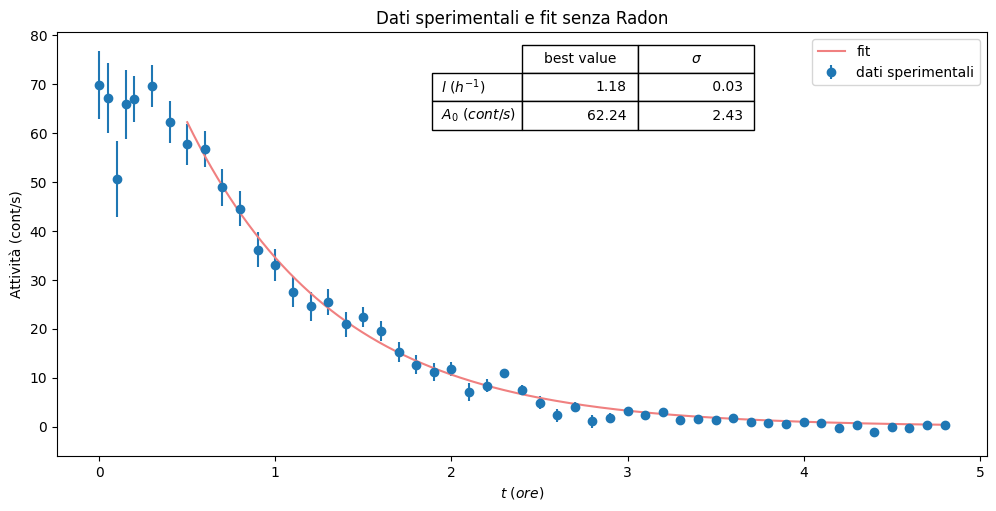

Il valore tabulato per Pb214 è lambda_Pb = 1.54h-1


In [ ]:
#@title
# fit esponenziale per t >= 1.5h (solo in ore)

dati1=np.loadtxt('/content/drive/MyDrive/Tesi/DatiSperimentali/EqTran/Dati2_Bateman.txt', dtype=float, delimiter="\t", skiprows=0)
# !rm -r /content/drive.google.com
# dati in quattro colonne, formato    t (min) \ t (s) \ n cont \ inc cont
dati1[:,0] = dati1[:,0]/60       #     t (h)      "        "        "
ut = 0        # colonna da usare per le unità di tempo: 0 == ore, 1 == secondi          tenere 0
tmax = dati1[-1,ut]

tmin = 0.5    # ore, limite inferiore per il fit

def esp(tesp, l, A0):
  As = A0*np.exp(-l*(tesp-tmin))
  return As
espv = np.vectorize(esp)

dati2 = dati1[dati1[:,0] >= tmin, :]

min=[1e-6, 0]       # minimum values for lRn, ARn0
max=[1000, mt.inf]  # maximum values for lRn, ARn0
bounds=(min,max)
popt,  pcov = sop.curve_fit(espv, dati2[:,0], dati2[:,2], p0=[1.32,0.7], sigma=dati2[:,3])
ndata = len(dati2[:,0])
l = popt[0]
A0= popt[1]
standard_error1 = np.sqrt(np.diag(pcov))
sigma = np.sqrt(ndata*np.diag(pcov))

tf = np.linspace(tmin, tmax, num=1000)
plt.figure(figsize=(12,5.5))
plt.errorbar(dati1[:,0], dati1[:,2], yerr=dati1[:,3], marker='o', fmt='', linestyle='', label='dati sperimentali')
plt.plot(tf, espv(tf, l, A0), color='lightcoral', label='fit')
plt.legend()
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività (cont/s)")
plt.title("Dati sperimentali e fit senza Radon")
# tabella parametri fit
rows = [r"$ l \ (h^{-1})$", r"$ A_0 \ (cont/s)$"]
cols = [r"best value", r"$ \sigma $"]
w, h = 2, 2
O = [[0 for x in range(w)] for y in range(h)]
for h in range(0,2):
  O[h][0]="%4.2f"%(popt[h])
  O[h][1]="%5.2f"%(standard_error1[h])
  #O[h][1]="%5.2f"%(sigma[h])
plt.table(cellText=O[:], rowLabels=rows, colLabels=cols,loc='top', bbox=[0.5,0.77,0.25,0.2])
plt.show()

print('Il valore tabulato per Pb214 è lambda_Pb = 1.54h-1')

### Generalizzazione anche a secondi

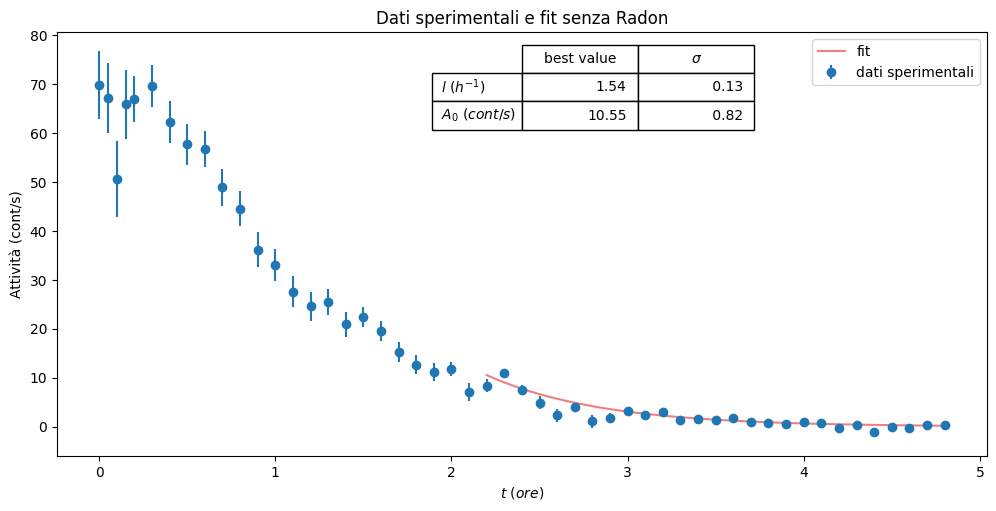

Il valore tabulato per Pb214 è lambda_Pb = 1.32h-1


In [ ]:
#@title
# fit esponenziale per t >= tmin
# usa dati in ore o secondi dipendentemente da ut (se 0 ore, se 1 secondi)

tmin = 2.2    # ore, limite inferiore per il fit

def esp(tesp, l, A0):
  As = A0*np.exp(-l*(tesp-tmin))
  return As
espv = np.vectorize(esp)


dati2 = dati1[dati1[:,0] >= tmin, :]

min=[1e-6, 0]/(pow(3600,ut)*np.ones(2))       # minimum values for lRn, ARn0
max=[1000, mt.inf]/(pow(3600,ut)*np.ones(2))  # maximum values for lRn, ARn0
p0 =[1/pow(3600,ut)]
p0 = np.hstack((p0, 1))
bounds=(min,max)
popt,  pcov = sop.curve_fit(espv, dati2[:,0], dati2[:,2], p0=p0, sigma=dati2[:,3])
ndata = len(dati2[:,0])
l = popt[0]
A0= popt[1]
standard_error1 = np.sqrt(np.diag(pcov))
sigma = np.sqrt(ndata*np.diag(pcov))

tf = np.linspace(tmin, tmax, num=1000)
plt.figure(figsize=(12,5.5))
plt.errorbar(dati1[:,ut], dati1[:,2], yerr=dati1[:,3], marker='o', fmt='', linestyle='', label='dati sperimentali')
plt.plot(tf, espv(tf, l, A0), color='lightcoral', label='fit')
plt.legend()
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività (cont/s)")
plt.title("Dati sperimentali e fit senza Radon")
# tabella parametri fit
rows = [r"$ l \ (h^{-1})$", r"$ A_0 \ (cont/s)$"]
cols = [r"best value", r"$ \sigma $"]
w, h = 2, 2
O = [[0 for x in range(w)] for y in range(h)]
for h in range(0,2):
  O[h][0]="%4.2f"%(popt[h])
  O[h][1]="%5.2f"%(standard_error1[h])
  #O[h][1]="%5.2f"%(sigma[h])
plt.table(cellText=O[:], rowLabels=rows, colLabels=cols,loc='top', bbox=[0.5,0.77,0.25,0.2])
plt.show()

print('Il valore tabulato per Pb214 è lambda_Pb = 1.32h-1')

### grafico l2 - tmin

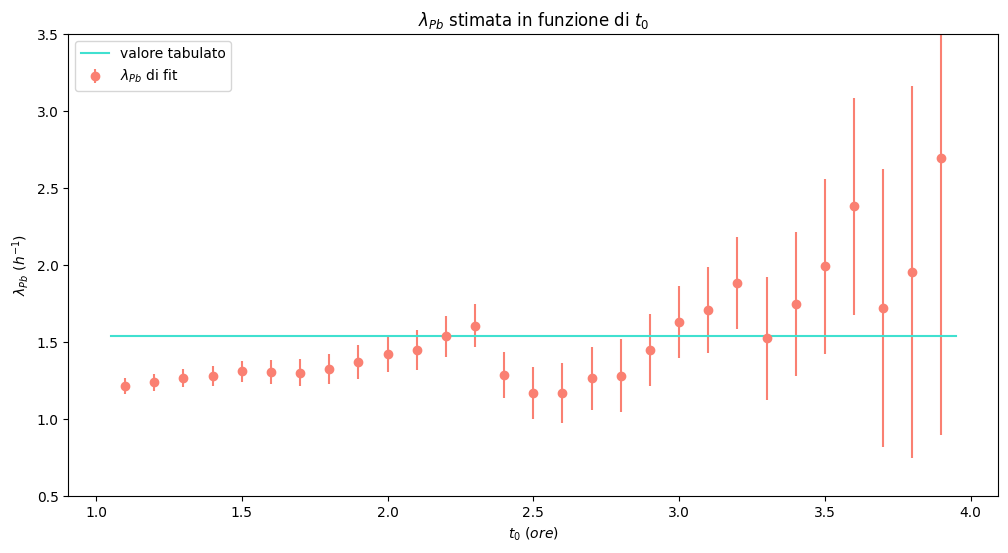

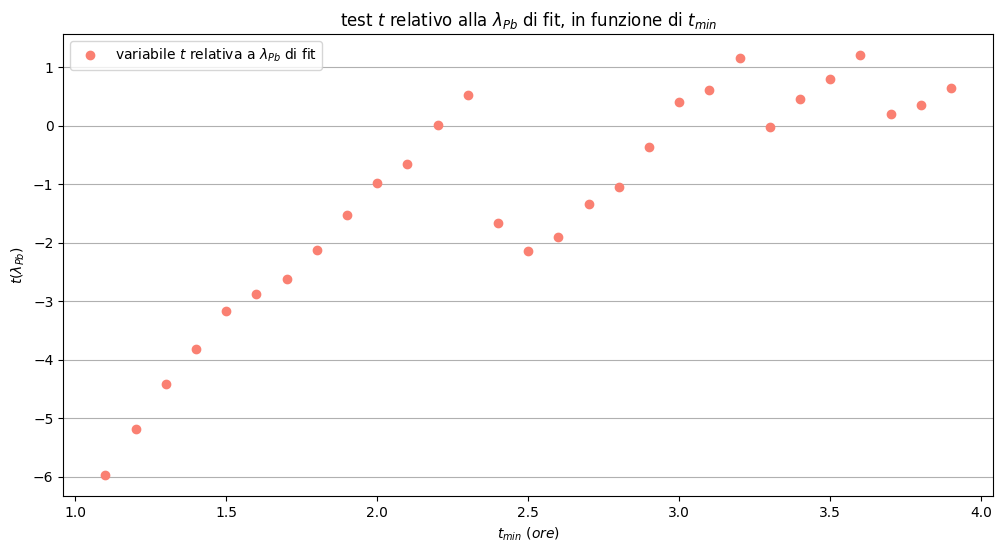

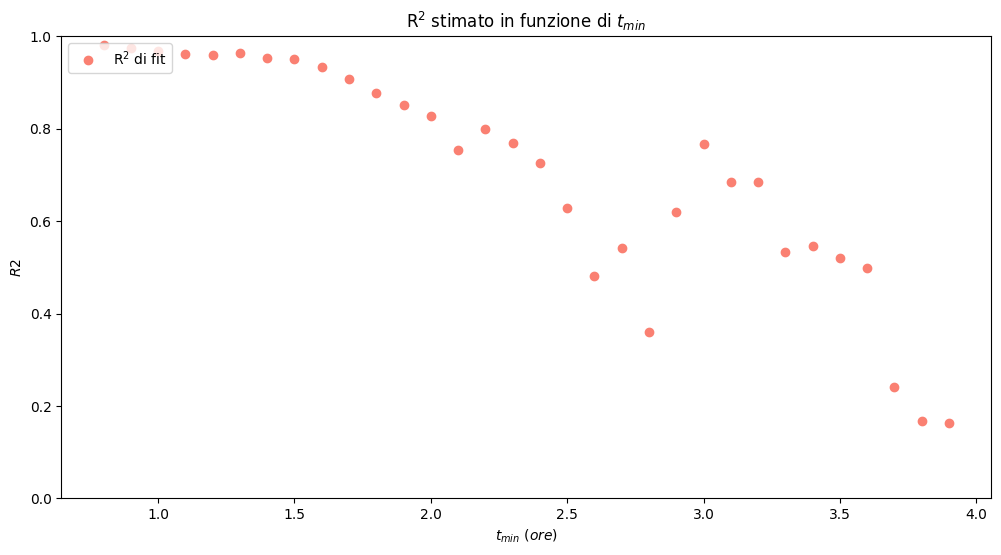

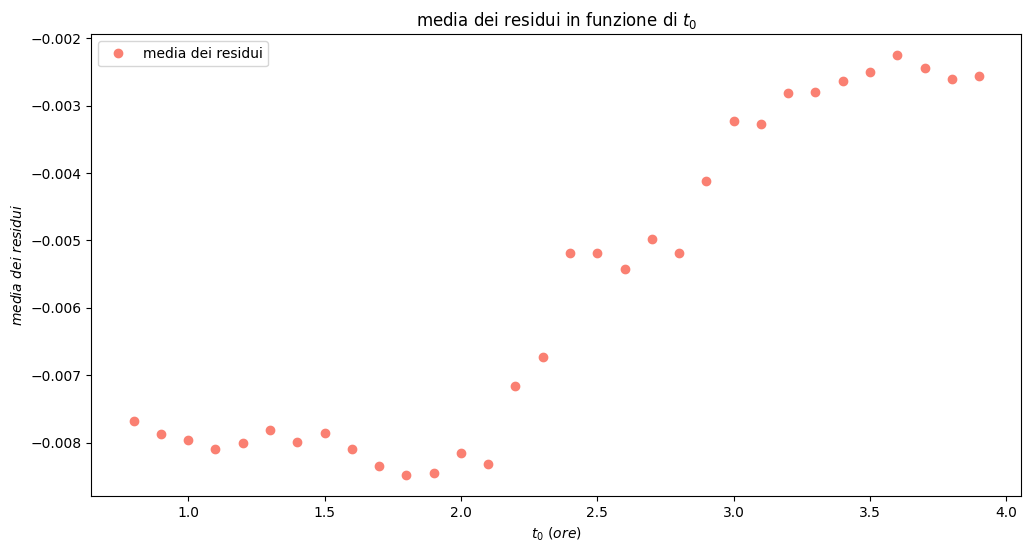

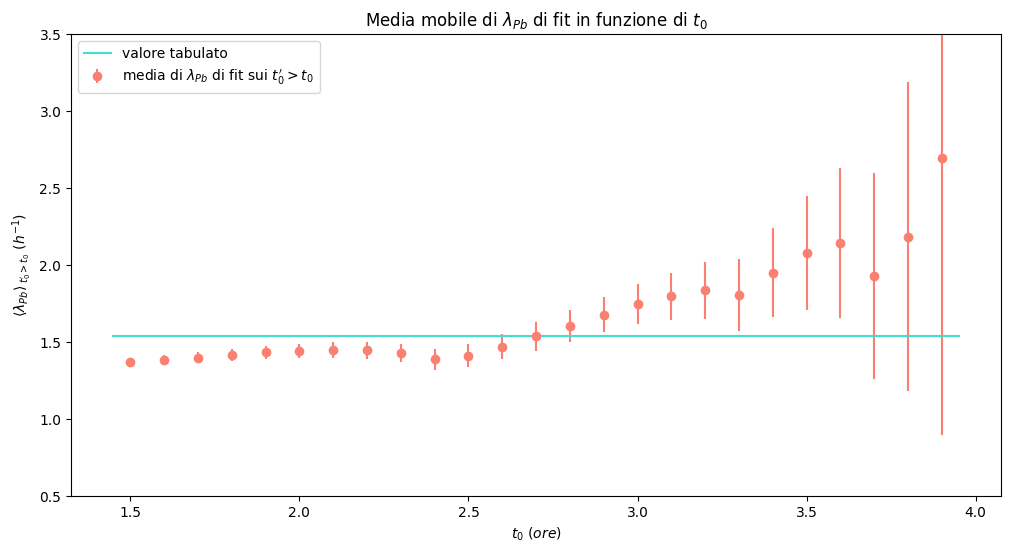

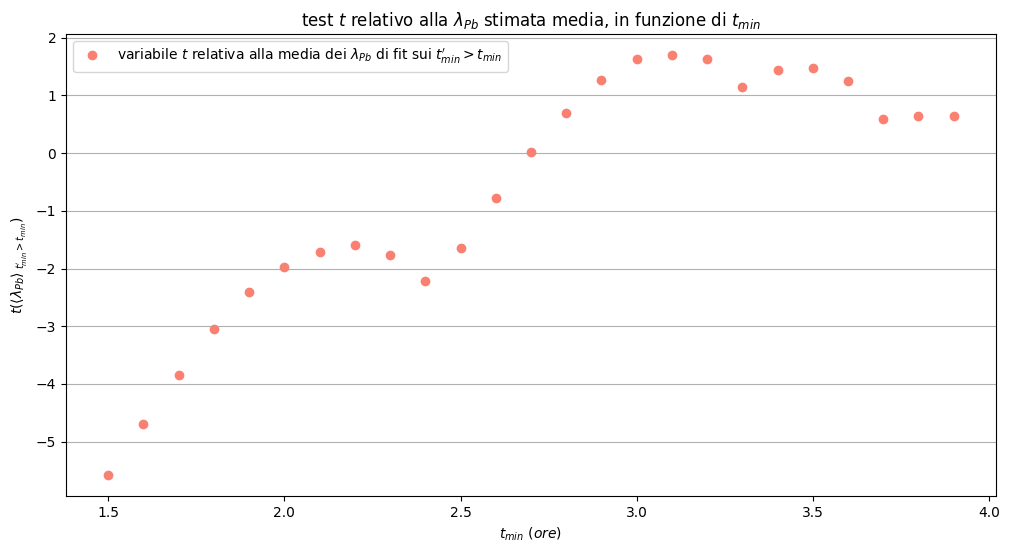

In [ ]:
#@title
# fit esponenziale per t >= 1.5h (solo in ore)

dati1=np.loadtxt('/content/drive/MyDrive/Tesi/DatiSperimentali/EqTran/Dati2_Bateman.txt', dtype=float, delimiter="\t", skiprows=0)
# !rm -r /content/drive.google.com
# dati in quattro colonne, formato    t (min) \ t (s) \ n cont \ inc cont
dati1[:,0] = dati1[:,0]/60       #     t (h)      "        "        "
ut = 0        # colonna da usare per le unità di tempo: 0 == ore, 1 == secondi          tenere 0

A3_0 = dati1[0,2]
dati1[:,3] = dati1[:,3]/A3_0
dati1[:,2] = dati1[:,2]/A3_0
#dati1 = dati1[dati1[:,0] >= 0.05, :]
#dati1 = dati1[dati1[:,2] > 0, :]
#plt.figure(figsize=(12,6))
#plt.errorbar(dati1[:,0], dati1[:,2], yerr=dati1[:,3], marker='o', fmt='', linestyle='', label='dati sperimentali')

l2v = np.zeros(len(dati1[:,0])-2)
s2v = np.zeros(len(dati1[:,0])-2)
t2v = np.zeros(len(dati1[:,0])-2)
l2m = np.zeros(len(dati1[:,0])-2)
s2m = np.zeros(len(dati1[:,0])-2)
t2m = np.zeros(len(dati1[:,0])-2)
R2v = np.zeros(len(dati1[:,0])-2)
res = np.zeros(len(dati1[:,0])-2)


for i in range(0,len(dati1[:,0])-2):
  tmin = dati1[i,0]   # ore, limite inferiore per il fit su l2
  dati2 = dati1[dati1[:,0] >= tmin, :]
  #print(len(dati2[0]))

  def esp(tesp, l, A0):
    As = A0*np.exp(-l*(tesp-tmin))
    return As
  espv = np.vectorize(esp)

  min=[1e-6, 0]/(pow(3600,ut)*np.ones(2))       # minimum values for lRn, ARn0
  max=[1000, mt.inf]/(pow(3600,ut)*np.ones(2))  # maximum values for lRn, ARn0
  p0 =[1/pow(3600,ut)]
  p0 =np.hstack((p0, 1))
  bounds=(min,max)
  popt,  pcov = sop.curve_fit(espv, dati2[:,0], dati2[:,2], p0=p0, sigma=dati2[:,3])
  ndata = len(dati2[:,0])
  l2 = popt[0]
  A0 = popt[1]
  standard_error1 = np.sqrt(np.diag(pcov))
  sigma = np.sqrt(ndata*np.diag(pcov))

  # calcolo il coefficiente R2 per valutare la bontà del fit
  tPb = dati2[:,ut]
  yPb  = dati2[:,2]
  res_Pb = yPb - espv(tPb,popt[0],popt[1])
  ss_res_Pb = np.sum(res_Pb**2)
  ss_tot_Pb = np.sum((yPb-np.mean(yPb))**2)
  r_squared = 1 - (ss_res_Pb / ss_tot_Pb)
  #print(r"$R^2_{\lambda_{Pb}}$ = %2.3f" %r_squared)
  media_res_Pb = np.mean(res_Pb)
  #print("media dei residui Pb = %2.3f" %media_res_Pb)

  l2v[i] = l2
  s2v[i] = standard_error1[0]
  t2v[i] = (l2v[i]-1.536)/s2v[i]
  R2v[i] = r_squared
  res[i] = media_res_Pb


for i in range(0,len(dati1[:,0])-9):
  l2m[i] = (np.sum(l2v[i:-7]*pow(s2v[i:-7],-2)))/(np.sum(pow(s2v[i:-7],-2)))
  s2m[i] = 1/np.sqrt(np.sum(pow(s2v[i:-7],-2)))
  t2m[i] = (l2m[i]-1.536)/s2m[i]


plt.figure(figsize=(12,6))
plt.errorbar(dati1[13:-9,0], l2v[13:-7], yerr=s2v[13:-7], marker='o', fmt='', linestyle='', label='$\lambda_{Pb}$ di fit', color='salmon')
plt.plot(np.linspace(1.05, 3.95, num=10), 1.54*np.ones(10), color='turquoise', label='valore tabulato')
plt.legend(loc='upper left')
plt.xlabel(r"$ t_0 \ (ore)$")
plt.ylabel(r"$\lambda_{Pb} \ (h^{-1})$")
#plt.xlim([-1.45, 4.05])
plt.ylim([0.5, 3.5])
#plt.yscale('log')
plt.title(r"$\lambda_{Pb}$ stimata in funzione di $t_0$")

plt.figure(figsize=(12,6))
plt.errorbar(dati1[13:-9,0], t2v[13:-7], marker='o', fmt='', linestyle='', label='variabile $t$ relativa a $\lambda_{Pb}$ di fit', color='salmon')
#plt.plot(np.linspace(1.45, 3.95, num=10), 1.54*np.ones(10), color='turquoise', label='valore tabulato')
plt.legend(loc='upper left')
plt.xlabel(r"$ t_{min} \ (ore)$")
plt.ylabel(r"$t(\lambda_{Pb})$")
#plt.xlim([-1.45, 4.05])
#plt.ylim([0.5, 3.5])
#plt.yscale('log')
plt.title(r"test $t$ relativo alla $\lambda_{Pb}$ di fit, in funzione di $t_{min}$")
plt.grid(axis = 'y')

plt.figure(figsize=(12,6))
plt.errorbar(dati1[10:-9,0], R2v[10:-7], marker='o', fmt='', linestyle='', label='R$^2$ di fit', color='salmon')
#plt.plot(np.linspace(1.45, 3.95, num=10), 1.54*np.ones(10), color='turquoise', label='valore tabulato')
plt.legend(loc='upper left')
plt.xlabel(r"$ t_{min} \ (ore)$")
plt.ylabel(r"$R2$")
#plt.xlim([-1.45, 4.05])
plt.ylim([0, 1])
#plt.yscale('log')
plt.title(r"R$^2$ stimato in funzione di $t_{min}$")

plt.figure(figsize=(12,6))
plt.errorbar(dati1[10:-9,0], res[10:-7], marker='o', fmt='', linestyle='', label='media dei residui', color='salmon')
#plt.plot(np.linspace(1.45, 3.95, num=10), 1.54*np.ones(10), color='turquoise', label='valore tabulato')
plt.legend(loc='upper left')
plt.xlabel(r"$ t_0 \ (ore)$")
plt.ylabel(r"$media\ dei\ residui$")
#plt.xlim([-1.45, 4.05])
#plt.ylim([0, 1])
#plt.yscale('log')
plt.title(r"media dei residui in funzione di $t_0$")

plt.figure(figsize=(12,6))
plt.errorbar(dati1[17:-9,0], l2m[17:-7], yerr=s2m[17:-7], marker='o', fmt='', linestyle='', label='media di $\lambda_{Pb}$ di fit sui $t^\prime_0>t_0$', color='salmon')
plt.plot(np.linspace(1.45, 3.95, num=10), 1.54*np.ones(10), color='turquoise', label='valore tabulato')
plt.legend(loc='upper left')
plt.xlabel(r"$ t_0 \ (ore)$")
plt.ylabel(r"$\langle{\lambda_{Pb}}\rangle_{\; t^\prime_0>t_0} \ (h^{-1})$")
#plt.xlim([-1.45, 4.05])
plt.ylim([0.5, 3.5])
#plt.yscale('log')
plt.title(r"Media mobile di $\lambda_{Pb}$ di fit in funzione di $t_0$")

plt.figure(figsize=(12,6))
plt.errorbar(dati1[17:-9,0], t2m[17:-7], marker='o', fmt='', linestyle='', label='variabile $t$ relativa alla media dei $\lambda_{Pb}$ di fit sui $t^\prime_{min}>t_{min}$', color='salmon')
#plt.plot(np.linspace(1.45, 3.95, num=10), 1.54*np.ones(10), color='turquoise', label='valore tabulato')
plt.legend(loc='upper left')
plt.xlabel(r"$ t_{min} \ (ore)$")
plt.ylabel(r"$t(\langle{\lambda_{Pb}}\rangle_{\; t^\prime_{min}>t_{min}})$")
#plt.xlim([-1.45, 4.05])
#plt.ylim([0.5, 3.5])
#plt.yscale('log')
plt.title(r"test $t$ relativo alla $\lambda_{Pb}$ stimata media, in funzione di $t_{min}$")
plt.grid(axis = 'y')

'''
plt.figure(figsize=(12,6))
plt.errorbar(dati1[:-9,0]*60, l2v[:-7]/60, yerr=s2v[:-7]/60, marker='o', fmt='', linestyle='', label='$\lambda_{Pb}$ di fit', color='salmon')
plt.plot(np.linspace(-0.05*60, 4*60, num=10), 1.54*np.ones(10)/60, color='turquoise', label='valore tabulato')
plt.legend(loc='upper left')
plt.xlabel(r"$ t_{min} \ (min)$")
plt.ylabel(r"$\lambda_{Pb} \ (min^{-1})$")
plt.xlim([-0.05*60, 2.55*60])
plt.ylim([0.96/60, 1.8/60])
#plt.yscale('log')
plt.title(r"$\lambda_{Pb}$ stimato in funzione di $t_{min}$")
plt.grid()
'''

plt.show()

## Fit a 3 Step: Pb - Bi - Po (tab)

Il valore tabulato per Pb214 è lambda_Pb = 1.54h-1
R2 = 0.9820, 0.9820


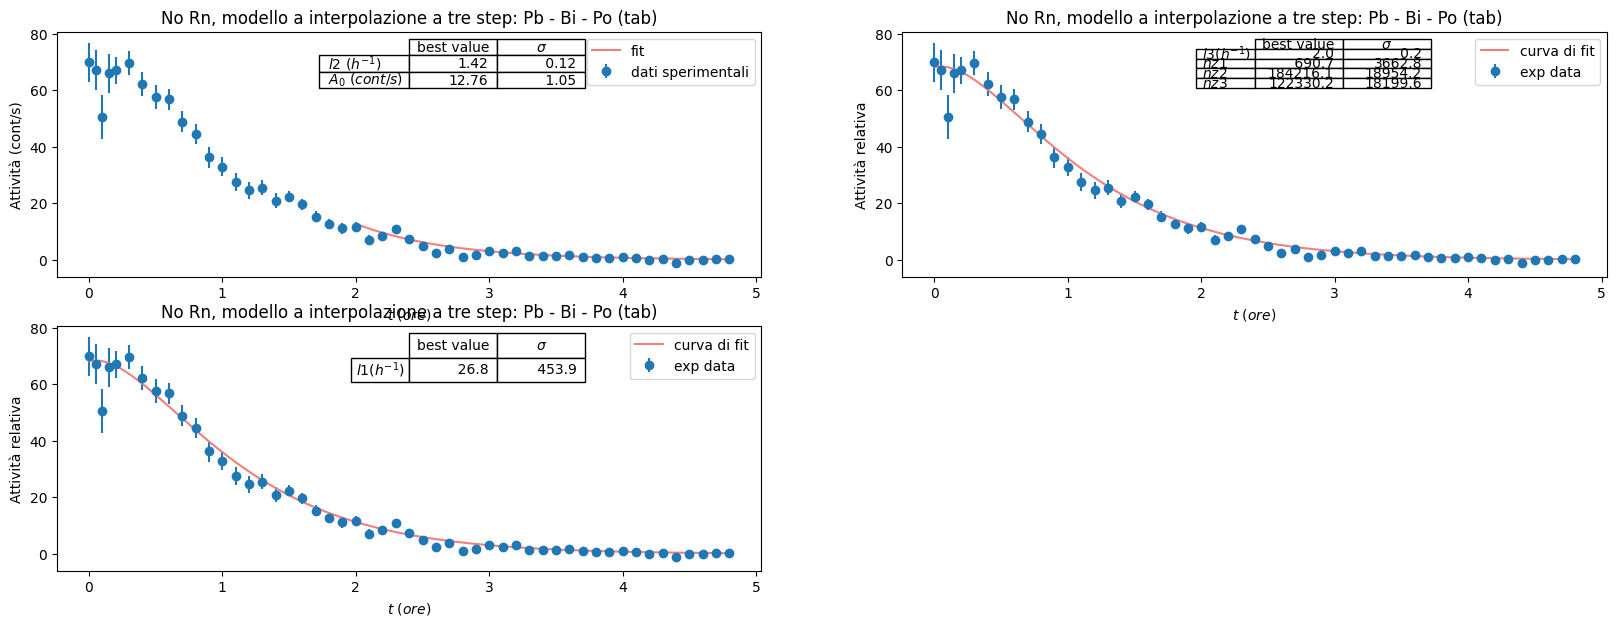

In [ ]:
#@title
# usa dati in ore o secondi dipendentemente da ut (se 0 ore, se 1 secondi)
# dati conteggi bismuto, no radon
# catena formata da Po218, Pb214, Bi214 (e Po214)

dati1=np.loadtxt('/content/drive/MyDrive/Tesi/DatiSperimentali/EqTran/Dati2_Bateman.txt', dtype=float, delimiter="\t", skiprows=0)
# !rm -r /content/drive.google.com
# dati in quattro colonne, formato    t (min) \ t (s) \ n cont \ inc cont
dati1[:,0] = dati1[:,0]/60       #     t (h)      "        "        "
ut = 0      # colonna da usare per le unità di tempo: 0 == ore, 1 == secondi
tmax = dati1[-1,ut]
A3_0 = 1#dati1[0,2]
dati1[:,3] = dati1[:,3]/A3_0
dati1[:,2] = dati1[:,2]/A3_0


# fit dell'esponenziale asintotico per l2
# fit esponenziale per t >= tmin

tmin = 2    # ore, limite inferiore per il fit


def esp(tesp, l, A0):
  As = A0*np.exp(-l*(tesp-tmin))
  return As
espv = np.vectorize(esp)


dati2 = dati1[dati1[:,0] >= tmin, :]

min=[1e-6, 0]/(pow(3600,ut)*np.ones(2))       # minimum values for lRn, ARn0
max=[1000, mt.inf]/(pow(3600,ut)*np.ones(2))  # maximum values for lRn, ARn0
p0 =[1/pow(3600,ut)]
p0 =np.hstack((p0, 1))
bounds=(min,max)
popt,  pcov = sop.curve_fit(espv, dati2[:,0], dati2[:,2], p0=p0, sigma=dati2[:,3])
ndata = len(dati2[:,0])
l2 = popt[0]
A0 = popt[1]
standard_error1 = np.sqrt(np.diag(pcov))
sigma = np.sqrt(ndata*np.diag(pcov))

tf = np.linspace(tmin, tmax, num=1000)


plt.figure(figsize=(20,7))
plt.subplot(221)
plt.errorbar(dati1[:,ut], dati1[:,2], yerr=dati1[:,3], marker='o', fmt='', linestyle='', label='dati sperimentali')
plt.plot(tf, espv(tf, l2, A0), color='lightcoral', label='fit')
plt.legend()
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività (cont/s)")
plt.title("No Rn, modello a interpolazione a tre step: Pb - Bi - Po (tab)")
# tabella parametri fit
rows = [r"$ l2 \ (h^{-1})$", r"$ A_0 \ (cont/s)$"]
cols = [r"best value", r"$ \sigma $"]
w, h = 2, 2
O = [[0 for x in range(w)] for y in range(h)]
for h in range(0,2):
  O[h][0]="%4.2f"%(popt[h])
  O[h][1]="%5.2f"%(standard_error1[h])
  #O[h][1]="%5.2f"%(sigma[h])
plt.table(cellText=O[:], rowLabels=rows, colLabels=cols,loc='top', bbox=[0.5,0.77,0.25,0.2])

print('Il valore tabulato per Pb214 è lambda_Pb = 1.54h-1')


# parametri di fit l3, nz1, nz2, nz3 con lam1 tabulato e l2 da fit precedente
lam1 = 3.73e-3*3600    # costante di decadimento del Po 218 in Pb 214 (h-1)

def eq3(ts, l3, nz1, nz2, nz3):
     #-time-grid-----------------------------------
     t  = np.linspace(0, tmax, 10000)
     #differential-eq-system----------------------
     def funct(y,t):
        Nm1=y[0]
        Nm2=y[1]
        Nm3=y[2]
        # the model equations
        f1 = -lam1*Nm1         # = dN1/dt
        f2 = -l2*Nm2+lam1*Nm1
        f3 = -l3*Nm3+l2*Nm2
        return [f1, f2, f3]
     #integrate------------------------------------
     Nz = nz1,nz2,nz3
     N  = integrate.odeint(funct,Nz,t)

     #opzione interpolazione
     N3 = N[:,2]
     N3f= itp.interp1d(t,N3,'cubic',fill_value="extrapolate")
     n3 = N3f(ts)

     #A1 = l1*n[:,0]
     #A2 = l2*n[:,1]
     A3 = l3*n3                           # attività in cont/h se ut=0, in cont/s se ut=1
     A3 = A3/pow(3600,1-ut)               # attività in cont/s come dati sperimentali [l3*n3]=[cont/h]=[cont/(3600s)]
     A3 = A3/A3_0                         # attività relativa
     return (A3)
eq3v=np.vectorize(eq3)


min=np.array([0.1])/pow(3600,ut)                  # minimum values for l3, nz1, nz2, nz3
min=np.hstack((min, [0, 0, 0]))
max=np.array([10])/pow(3600,ut)                   # maximum values for l3, nz1, nz2, nz3
max=np.hstack((max, [mt.inf, mt.inf, mt.inf]))
bounds=(min,max)
p0 =np.array([2.109])/pow(3600,ut)                # guess iniziali
p0 = np.hstack((p0, [10000,10000,10000]))                                                                        # p0=[1.536,2.109,1700,1600,1800]
popt,  pcov = sop.curve_fit(eq3, dati1[:,ut], dati1[:,2], p0=p0, sigma=dati1[:,3], bounds=bounds)
ndata = len(dati1[:,0])
l3 = popt[0]
nz1= popt[1]
nz2= popt[2]
nz3= popt[3]
standard_error1 = np.sqrt(np.diag(pcov))
sigma = np.sqrt(ndata*np.diag(pcov))

# calcolo il coefficiente R2 per valutare la bontà del fit
ts = dati1[:,ut]
y  = dati1[:,2]
tfit=np.linspace(0, tmax, num=1000)
residuals = y - eq3(ts,popt[0],popt[1],popt[2],popt[3])
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y-np.mean(y))**2)
r_squared_1 = 1 - (ss_res / ss_tot)


plt.subplot(222)
plt.errorbar(dati1[:,ut], dati1[:,2], yerr=dati1[:,3], marker='o', fmt='', linestyle='', label='exp data')
plt.plot(tfit, eq3(tfit,l3,nz1,nz2,nz3), color='lightcoral', label='curva di fit')
plt.legend()
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività relativa")
#plt.title("Dati sperimentali e fit senza Radon")
plt.title("No Rn, modello a interpolazione a tre step: Pb - Bi - Po (tab)")

# tabella parametri fit
rows = [r"$l3 (h^{-1})$", r"$nz1$", r"$nz2$", r"$nz3$"]
cols = [r"best value", r"$ \sigma $"]
w, h = 2, 4
O = [[0 for x in range(w)] for y in range(h)]
for h in range(0,4):
  O[h][0]="%6.1f"%(popt[h])
  O[h][1]="%6.1f"%(standard_error1[h])
  #O[h][1]="%5.4f"%(sigma[h])
plt.table(cellText=O[:], rowLabels=rows, colLabels=cols,loc='top', bbox=[0.5,0.77,0.25,0.2])

#print("R2 = %2.4f" %(r_squared))


#-di-nuovo----------------------------------------------------------------
# parametro di fit l1 con parametri l2, l3, nz1, nz2, nz3 di prima fissati

def eqq3(ts, l1):
     #-time-grid-----------------------------------
     t  = np.linspace(0, tmax, 10000)                            # per opzione interpolazione si può usare questo
     #differential-eq-system----------------------
     def funct(y,t):
        Nm1=y[0]
        Nm2=y[1]
        Nm3=y[2]
        # the model equations
        f1 = -l1*Nm1         # = dN1/dt
        f2 = -l2*Nm2+l1*Nm1
        f3 = -l3*Nm3+l2*Nm2
        return [f1, f2, f3]
     #integrate------------------------------------
     Nz = nz1,nz2,nz3
     N  = integrate.odeint(funct,Nz,t)

     #opzione interpolazione
     N3 = N[:,2]
     N3f= itp.interp1d(t,N3,'cubic',fill_value="extrapolate")
     n3 = N3f(ts)

     #A1 = l1*n[:,0]
     #A2 = l2*n[:,1]
     A3 = l3*n3                           # attività in cont/h se ut=0, in cont/s se ut=1
     A3 = A3/pow(3600,1-ut)               # attività in cont/s come dati sperimentali [l3*n3]=[cont/h]=[cont/(3600s)]
     A3 = A3/A3_0                         # attività relativa
     return (A3)
eqq3v=np.vectorize(eqq3)

min=5/pow(3600,ut)                    # minimum value for l1
max=100/pow(3600,ut)                  # maximum value for l1
bounds=(min,max)
p0 = 13.42/pow(3600,ut)               # guess iniziale 13.42
popt,  pcov = sop.curve_fit(eqq3v, dati1[:,ut], dati1[:,2], p0=p0, sigma=dati1[:,3], bounds=bounds)
ndata = len(dati1[:,0])
l1 = popt[0]
standard_error1 = np.sqrt(np.diag(pcov))
sigma = np.sqrt(ndata*np.diag(pcov))

# calcolo il coefficiente R2 per valutare la bontà del fit
ts = dati1[:,ut]
y  = dati1[:,2]
tfit=np.linspace(0, tmax, num=1000)
residuals = y - eqq3v(ts,popt[0])
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y-np.mean(y))**2)
r_squared = 1 - (ss_res / ss_tot)
print("R2 = %2.4f, %2.4f" %(r_squared_1, r_squared))

plt.subplot(223)
plt.errorbar(dati1[:,ut], dati1[:,2], yerr=dati1[:,3], marker='o', fmt='', linestyle='', label='exp data')
plt.plot(tfit, eqq3v(tfit,l1), color='lightcoral', label='curva di fit')
plt.legend()
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività relativa")
#plt.title("Dati sperimentali e fit senza Radon")
plt.title("No Rn, modello a interpolazione a tre step: Pb - Bi - Po (tab)")

# tabella parametri fit
rows = [r"$l1 (h^{-1})$"]
cols = [r"best value", r"$ \sigma $"]
w, h = 2, 1
O = [[0 for x in range(w)] for y in range(h)]
for h in range(0,1):
  O[h][0]="%6.1f"%(popt[h])
  O[h][1]="%6.1f"%(standard_error1[h])
  #O[h][1]="%5.4f"%(sigma[h])
plt.table(cellText=O[:], rowLabels=rows, colLabels=cols,loc='top', bbox=[0.5,0.77,0.25,0.2])

plt.show()

## Fit a 2 step: Pb - PoBi

Il valore tabulato per Pb214 è lambda_Pb = 1.54h-1


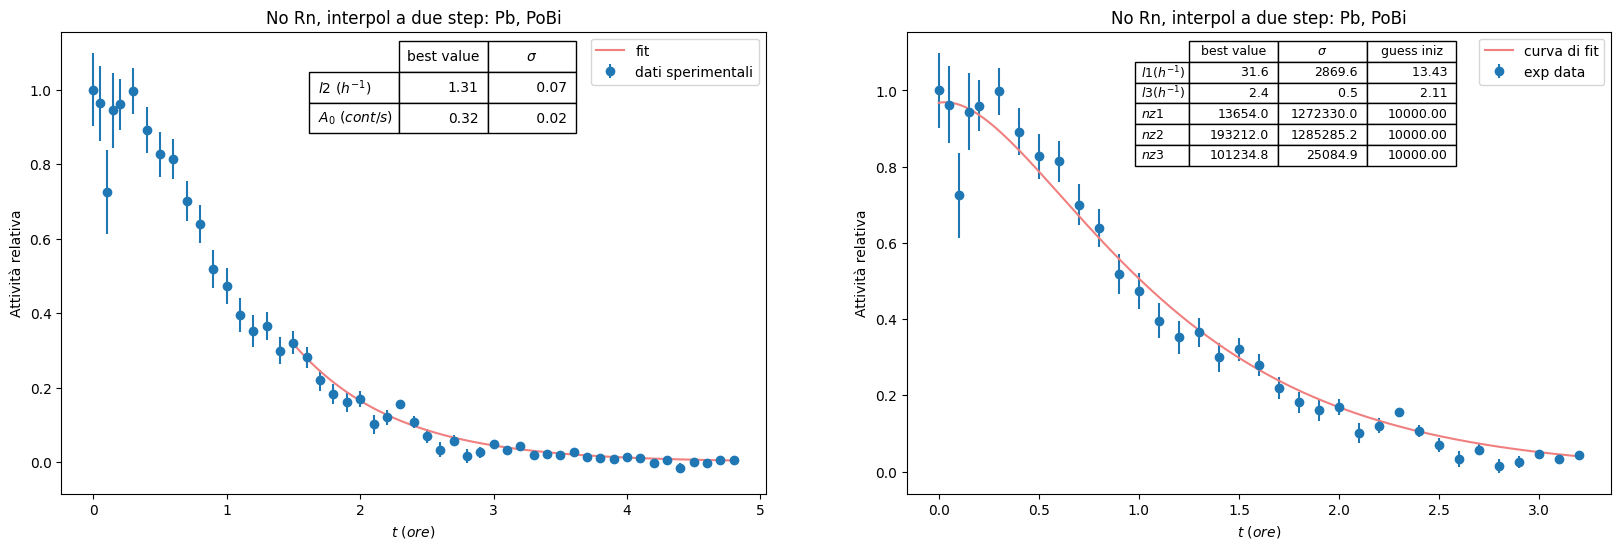

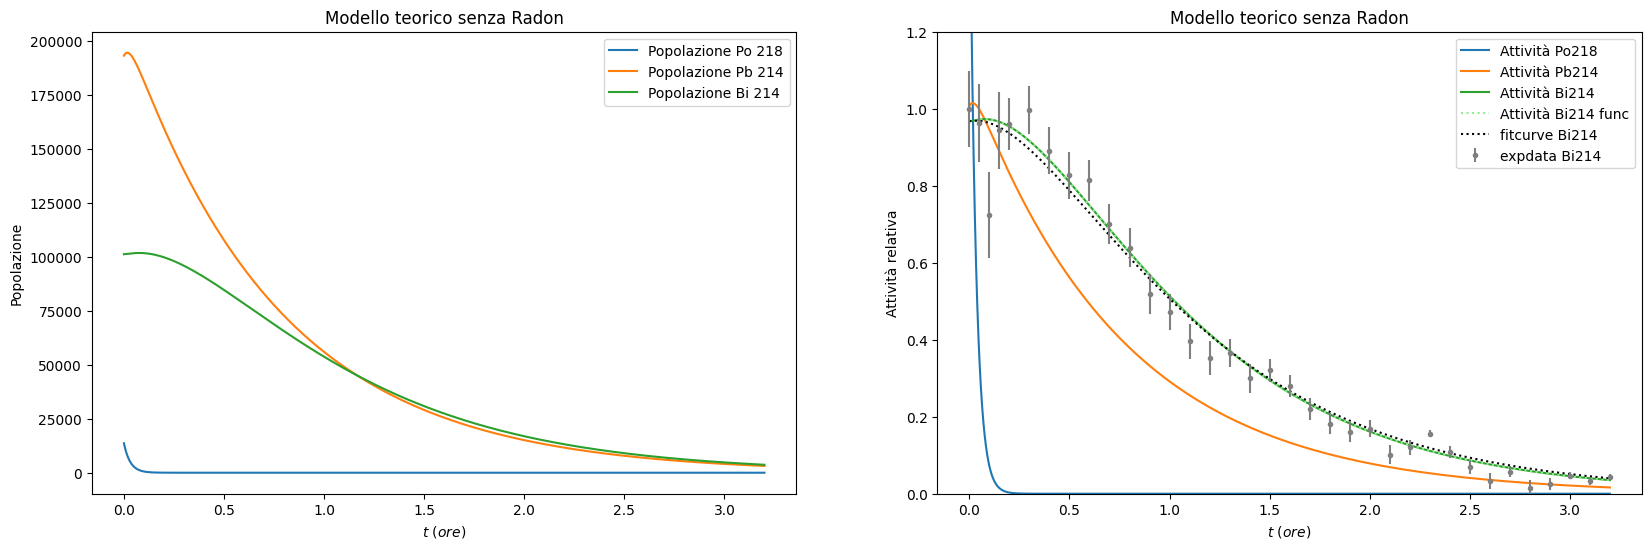

In [ ]:
#@title
# usa dati in ore o secondi dipendentemente da ut (se 0 ore, se 1 secondi)
# dati conteggi bismuto, no radon
# catena formata da Po218, Pb214, Bi214 (e Po214)

dati1=np.loadtxt('/content/drive/MyDrive/Tesi/DatiSperimentali/EqTran/Dati2_Bateman.txt', dtype=float, delimiter="\t", skiprows=0)
# !rm -r /content/drive.google.com
# dati in quattro colonne, formato    t (min) \ t (s) \ n cont \ inc cont
dati1[:,0] = dati1[:,0]/60       #     t (h)      "        "        "
ut = 0        # colonna da usare per le unità di tempo: 0 == ore, 1 == secondi          tenere 0
tmin = 1.5   # ore, limite inferiore per il fit su l2
tmax1 = dati1[-1,ut]
tmax2 = 3.2   # ore, limite inferiore per il fit su l1 e l3
A3_0 = dati1[0,2]
dati1[:,3] = dati1[:,3]/A3_0
dati1[:,2] = dati1[:,2]/A3_0
#dati1 = dati1[dati1[:,2] > 0, :]
dati2 = dati1[dati1[:,0] >= tmin,  :]
dati3 = dati1[dati1[:,0] <= tmax2, :]

# fit dell'esponenziale asintotico per l2
# fit esponenziale per t >= tmin

def esp(tesp, l, A0):
  As = A0*np.exp(-l*(tesp-tmin))
  return As
espv = np.vectorize(esp)

min=[1e-6, 0]/(pow(3600,ut)*np.ones(2))       # minimum values for lRn, ARn0
max=[1000, mt.inf]/(pow(3600,ut)*np.ones(2))  # maximum values for lRn, ARn0
p0 =[1/pow(3600,ut)]
p0 =np.hstack((p0, 1))
bounds=(min,max)
popt,  pcov = sop.curve_fit(espv, dati2[:,0], dati2[:,2], p0=p0, sigma=dati2[:,3])
ndata = len(dati2[:,0])
#l2 = popt[0]
l2 = round(popt[0], 2)
A0 = popt[1]
standard_error1 = np.sqrt(np.diag(pcov))
sigma = np.sqrt(ndata*np.diag(pcov))

tf = np.linspace(tmin, tmax1, num=1000)

plt.figure(figsize=(20,6))
plt.subplot(121)
plt.errorbar(dati1[:,ut], dati1[:,2], yerr=dati1[:,3], marker='o', fmt='', linestyle='', label='dati sperimentali')
plt.plot(tf, espv(tf, l2, A0), color='lightcoral', label='fit')
plt.legend()
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività relativa")
plt.title("No Rn, interpol a due step: Pb, PoBi")
# tabella parametri fit
rows = [r"$ l2 \ (h^{-1})$", r"$ A_0 \ (cont/s)$"]
cols = [r"best value", r"$ \sigma $"]
w, h = 2, 2
O = [[0 for x in range(w)] for y in range(h)]
for h in range(0,2):
  O[h][0]="%4.2f"%(popt[h])
  O[h][1]="%5.2f"%(standard_error1[h])
  #O[h][1]="%5.2f"%(sigma[h])
plt.table(cellText=O[:], rowLabels=rows, colLabels=cols,loc='top', bbox=[0.48,0.78,0.25,0.2])

print('Il valore tabulato per Pb214 è lambda_Pb = 1.54h-1')

#l2 = 1.54

# parametri di fit l3, nz1, nz2, nz3 con lam1 tabulato e l2 da fit precedente

def eq3(ts, l1, l3, nz1, nz2, nz3):
     #-time-grid-----------------------------------
     t  = np.linspace(0, tmax2, 100000)                            # per opzione interpolazione si può usare questo
     #differential-eq-system----------------------
     def funct(y,t):
        Nm1=y[0]
        Nm2=y[1]
        Nm3=y[2]
        # the model equations
        f1 = -l1*Nm1         # = dN1/dt
        f2 = -l2*Nm2+l1*Nm1
        f3 = -l3*Nm3+l2*Nm2
        return [f1, f2, f3]
     #integrate------------------------------------
     Nz = nz1,nz2,nz3
     N  = integrate.odeint(funct,Nz,t)

     #opzione interpolazione
     N3 = N[:,2]
     N3f= itp.interp1d(t,N3,'cubic',fill_value="extrapolate")
     n3 = N3f(ts)

     #A1 = l1*n[:,0]
     #A2 = l2*n[:,1]
     A3 = l3*n3                           # attività in cont/h se ut=0, in cont/s se ut=1
     A3 = A3/pow(3600,1-ut)               # attività in cont/s come dati sperimentali [l3*n3]=[cont/h]=[cont/(3600s)]
     A3 = A3/A3_0                         # attività relativa
     return (A3)
eq3v=np.vectorize(eq3)


min=[1, 0.2]/(pow(3600,ut)*np.ones(2))                  # minimum values for l1, l3, nz1, nz2, nz3
min = np.hstack((min, [1000, 1000, 1000]))
max=[100, 15]/(pow(3600,ut)*np.ones(2))                    # maximum values for l1, l3, nz1, nz2, nz3
max = np.hstack((max, [mt.inf, mt.inf, mt.inf]))
bounds=(min,max)
p0 = [13.43,2.109]/(pow(3600,ut)*np.ones(2))              # guess iniziali
p0 = np.hstack((p0, [1e4,1e4,1e4]))                                                                        # p0=[13.43,2.109,1700,1600,1800]
popt,  pcov = sop.curve_fit(eq3, dati3[:,ut], dati3[:,2], p0=p0, sigma=dati3[:,3], bounds=bounds)
ndata = len(dati3[:,0])
l1 = popt[0]
l3 = popt[1]
nz1= popt[2]
nz2= popt[3]
nz3= popt[4]
standard_error1 = np.sqrt(np.diag(pcov))
sigma = np.sqrt(ndata*np.diag(pcov))

# calcolo il coefficiente R2 per valutare la bontà del fit
ts = dati3[:,ut]
y  = dati3[:,2]
tfit = np.linspace(0, tmax2, num=1000)
residuals = y - eq3(ts,popt[0],popt[1],popt[2],popt[3],popt[4])
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y-np.mean(y))**2)
r_squared_1 = 1 - (ss_res / ss_tot)


plt.subplot(122)
plt.errorbar(dati3[:,ut], dati3[:,2], yerr=dati3[:,3], marker='o', fmt='', linestyle='', label='exp data')
plt.plot(tfit, eq3(tfit,l2,l3,nz1,nz2,nz3), color='lightcoral', label='curva di fit')
plt.legend()
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività relativa")
#plt.title("Dati sperimentali e fit senza Radon")
plt.title("No Rn, interpol a due step: Pb, PoBi")

# tabella parametri fit
rows = [r"$l1 (h^{-1})$", r"$l3 (h^{-1})$", r"$nz1$", r"$nz2$", r"$nz3$"]
cols = [r"best value", r"$ \sigma $", r"guess iniz"]
w, h = 3, 5
O = [[0 for x in range(w)] for y in range(h)]
for h in range(0,5):
  O[h][0]="%6.1f"%(popt[h])
  O[h][1]="%6.1f"%(standard_error1[h])
  O[h][2]="%6.2f"%(p0[h])
  #O[h][1]="%5.4f"%(sigma[h])
plt.table(cellText=O[:], rowLabels=rows, colLabels=cols,loc='top', bbox=[0.4,0.71,0.38,0.27])


Nt = 10000     # numero osservazioni temporali
t = np.linspace(0, tmax2, Nt)

N1 = np.zeros(Nt)
N2 = np.zeros(Nt)
N3 = np.zeros(Nt)
dN1dt = np.zeros(Nt)
dN2dt = np.zeros(Nt)
dN3dt = np.zeros(Nt)
A1 = np.zeros(Nt)
A2 = np.zeros(Nt)
A3 = np.zeros(Nt)

N1[0] = nz1
N2[0] = nz2
N3[0] = nz3

for i in range(0,Nt-1):
  dN1dt[i] = -l1*N1[i]
  dN2dt[i] = -l2*N2[i]+l1*N1[i]
  dN3dt[i] = -l3*N3[i]+l2*N2[i]
  A1[i] = l1*N1[i]/pow(3600,1-ut)
  A2[i] = l2*N2[i]/pow(3600,1-ut)
  A3[i] = l3*N3[i]/pow(3600,1-ut)
  N1[i+1] = N1[i]+dN1dt[i]*tmax2/(Nt-1)
  N2[i+1] = N2[i]+dN2dt[i]*tmax2/(Nt-1)
  N3[i+1] = N3[i]+dN3dt[i]*tmax2/(Nt-1)
dN1dt[Nt-1] = -l1*N1[Nt-1]
dN2dt[Nt-1] = -l2*N2[Nt-1]+l1*N1[Nt-1]
dN3dt[Nt-1] = -l3*N3[Nt-1]+l2*N2[Nt-1]
A1[Nt-1] = l1*N1[Nt-1]/pow(3600,1-ut)
A2[Nt-1] = l2*N2[Nt-1]/pow(3600,1-ut)
A3[Nt-1] = l3*N3[Nt-1]/pow(3600,1-ut)

plt.figure(figsize=(20,6))
plt.subplot(121)
plt.plot(t, N1, label='Popolazione Po 218')
plt.plot(t, N2, label='Popolazione Pb 214')
plt.plot(t, N3, label='Popolazione Bi 214')
plt.title("Modello teorico senza Radon")
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Popolazione")
plt.legend()
#plt.yscale('log')

Nt3 = (l1*l2/((l2-l1)*(l3-l1)))*nz1*np.exp(-l1*t) + (l2/(l3-l2))*(nz2-(l1/(l2-l1))*nz1)*np.exp(-l2*t) + (nz3-(l2/(l3-l2))*nz2+(l1*l2/((l3-l2)*(l3-l1)))*nz1)*np.exp(-l3*t)
At3 = l3*Nt3                           # attività in cont/h se ut=0, in cont/s se ut=1
At3 = At3/pow(3600,1-ut)               # attività in cont/s come dati sperimentali [l3*n3]=[cont/h]=[cont/(3600s)]

plt.subplot(122)
plt.plot(t, A1/A3_0, label='Attività Po218')
plt.plot(t, A2/A3_0, label='Attività Pb214')
plt.plot(t, A3/A3_0, label='Attività Bi214')
plt.plot(t, At3/A3_0, color='lightgreen', label='Attività Bi214 func', ls=':')
plt.plot(tfit, eq3(tfit,l2,l3,nz1,nz2,nz3), color='black', label='fitcurve Bi214', ls=':')
plt.errorbar(dati3[:,ut], dati3[:,2], yerr=dati3[:,3], marker='.', fmt='', linestyle='', label='expdata Bi214', color='grey')
plt.title("Modello teorico senza Radon")
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività relativa")
plt.legend()
plt.ylim([0, 1.2])
#plt.yscale('log')

# To avoid matplotlib text output
plt.show()

## Fit a 2 step: Pb - PoBi (no odeint)

Il valore tabulato per Pb214 è lambda_Pb = 1.54h-1


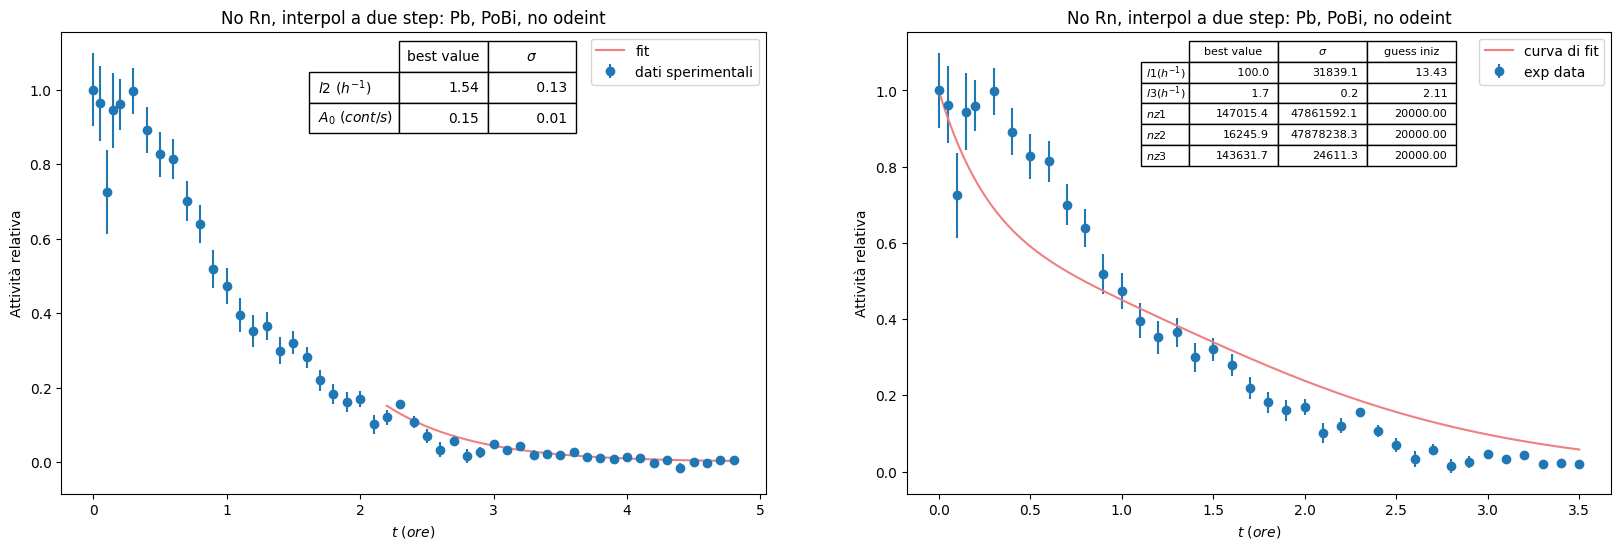

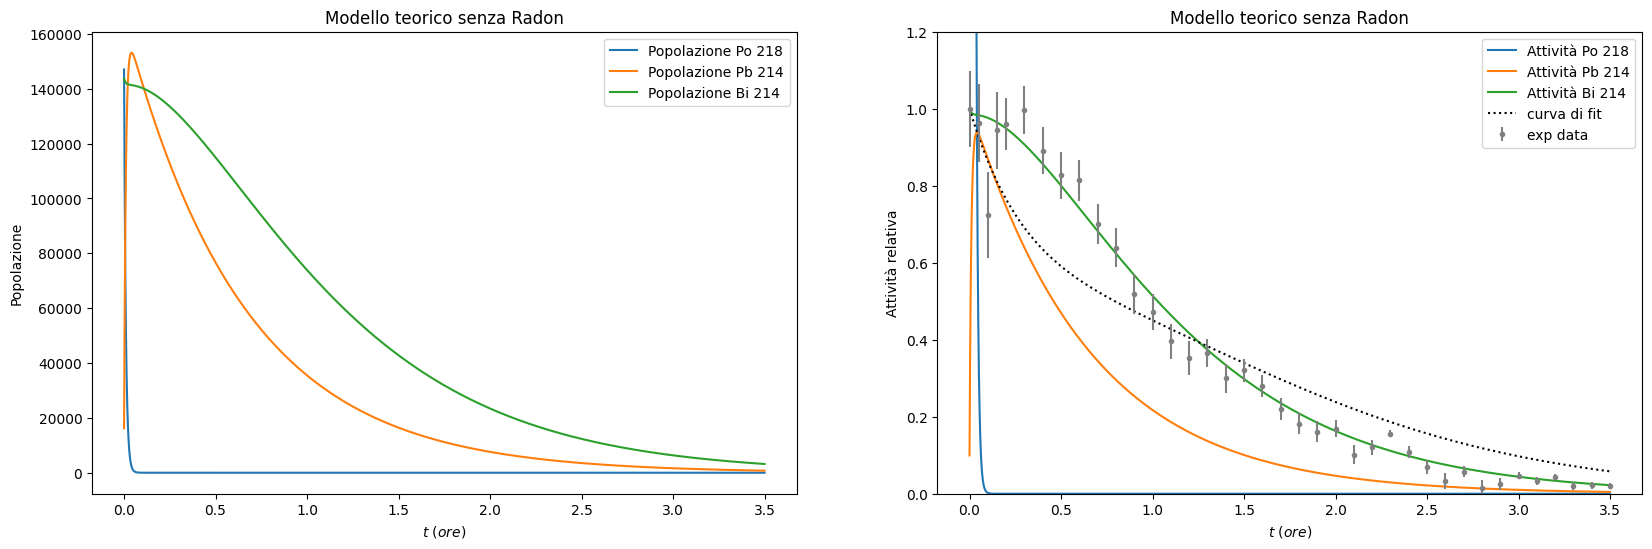

In [ ]:
#@title
# usa dati in ore o secondi dipendentemente da ut (se 0 ore, se 1 secondi)
# dati conteggi bismuto, no radon
# catena formata da Po218, Pb214, Bi214 (e Po214)

dati1=np.loadtxt('/content/drive/MyDrive/Tesi/DatiSperimentali/EqTran/Dati2_Bateman.txt', dtype=float, delimiter="\t", skiprows=0)
# !rm -r /content/drive.google.com
# dati in quattro colonne, formato    t (min) \ t (s) \ n cont \ inc cont
dati1[:,0] = dati1[:,0]/60       #     t (h)      "        "        "
ut = 0        # colonna da usare per le unità di tempo: 0 == ore, 1 == secondi          tenere 0
tmin = 2.2   # ore, limite inferiore per il fit su l2
tmax1 = dati1[-1,ut]
tmax2 = 3.5   # ore, limite inferiore per il fit su l1 e l3
A3_0 = dati1[0,2]
dati1[:,3] = dati1[:,3]/A3_0
dati1[:,2] = dati1[:,2]/A3_0
#dati1 = dati1[dati1[:,2] > 0, :]
dati2 = dati1[dati1[:,0] >= tmin,  :]
dati3 = dati1[dati1[:,0] <= tmax2, :]

# fit dell'esponenziale asintotico per l2
# fit esponenziale per t >= tmin

def esp(tesp, l, A0):
  As = A0*np.exp(-l*(tesp-tmin))
  return As
espv = np.vectorize(esp)

min=[1e-6, 0]/(pow(3600,ut)*np.ones(2))       # minimum values for lRn, ARn0
max=[1000, mt.inf]/(pow(3600,ut)*np.ones(2))  # maximum values for lRn, ARn0
p0 =[1/pow(3600,ut)]
p0 =np.hstack((p0, 1))
bounds=(min,max)
popt,  pcov = sop.curve_fit(espv, dati2[:,0], dati2[:,2], p0=p0, sigma=dati2[:,3])
ndata = len(dati2[:,0])
#l2 = popt[0]
l2 = round(popt[0], 2)
A0 = popt[1]
standard_error1 = np.sqrt(np.diag(pcov))
sigma = np.sqrt(ndata*np.diag(pcov))

tf = np.linspace(tmin, tmax1, num=1000)

plt.figure(figsize=(20,6))
plt.subplot(121)
plt.errorbar(dati1[:,ut], dati1[:,2], yerr=dati1[:,3], marker='o', fmt='', linestyle='', label='dati sperimentali')
plt.plot(tf, espv(tf, l2, A0), color='lightcoral', label='fit')
plt.legend()
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività relativa")
plt.title("No Rn, interpol a due step: Pb, PoBi, no odeint")
# tabella parametri fit
rows = [r"$ l2 \ (h^{-1})$", r"$ A_0 \ (cont/s)$"]
cols = [r"best value", r"$ \sigma $"]
w, h = 2, 2
O = [[0 for x in range(w)] for y in range(h)]
for h in range(0,2):
  O[h][0]="%4.2f"%(popt[h])
  O[h][1]="%5.2f"%(standard_error1[h])
  #O[h][1]="%5.2f"%(sigma[h])
plt.table(cellText=O[:], rowLabels=rows, colLabels=cols,loc='top', bbox=[0.48,0.78,0.25,0.2])

print('Il valore tabulato per Pb214 è lambda_Pb = 1.54h-1')

#l2 = 1.54

# parametri di fit l3, nz1, nz2, nz3 con lam1 tabulato e l2 da fit precedente

def eq3(ts, l1, l3, nz1, nz2, nz3):
    #-time-grid-----------------------------------
    t  = np.linspace(0, tmax2, 10000)                            # per opzione interpolazione si può usare questo

    #inizializzazione-----------------------------
    N1 = np.zeros(Nt)
    N2 = np.zeros(Nt)
    N3 = np.zeros(Nt)
    dN1dt = np.zeros(Nt)
    dN2dt = np.zeros(Nt)
    dN3dt = np.zeros(Nt)
    A1 = np.zeros(Nt)
    A2 = np.zeros(Nt)
    A3 = np.zeros(Nt)

    N1[0] = nz1
    N2[0] = nz2
    N3[0] = nz3

    #differential-eq-system----------------------
    for i in range(0,Nt-1):
      dN1dt[i] = -l1*N1[i]
      dN2dt[i] = -l2*N2[i]+l1*N1[i]
      dN3dt[i] = -l3*N3[i]+l2*N2[i]
      A1[i] = l1*N1[i]/pow(3600,1-ut)
      A2[i] = l2*N2[i]/pow(3600,1-ut)
      A3[i] = l3*N3[i]/pow(3600,1-ut)
      N1[i+1] = N1[i]+dN1dt[i]*tmax2/(Nt-1)
      N2[i+1] = N2[i]+dN2dt[i]*tmax2/(Nt-1)
      N3[i+1] = N3[i]+dN3dt[i]*tmax2/(Nt-1)
    dN1dt[Nt-1] = -l1*N1[Nt-1]
    dN2dt[Nt-1] = -l2*N2[Nt-1]+l1*N1[Nt-1]
    dN3dt[Nt-1] = -l3*N3[Nt-1]+l2*N2[Nt-1]
    A1[Nt-1] = l1*N1[Nt-1]/pow(3600,1-ut)
    A2[Nt-1] = l2*N2[Nt-1]/pow(3600,1-ut)
    A3[Nt-1] = l3*N3[Nt-1]/pow(3600,1-ut)

    A3f= itp.interp1d(t,A3,'cubic',fill_value="extrapolate")
    As3 = A3f(ts)
    Ars3= As3/A3_0
    return (Ars3)
eq3v=np.vectorize(eq3)



Nt = 10000     # numero osservazioni temporali
t = np.linspace(0, tmax2, Nt)

N1 = np.zeros(Nt)
N2 = np.zeros(Nt)
N3 = np.zeros(Nt)
dN1dt = np.zeros(Nt)
dN2dt = np.zeros(Nt)
dN3dt = np.zeros(Nt)
A1 = np.zeros(Nt)
A2 = np.zeros(Nt)
A3 = np.zeros(Nt)

N1[0] = nz1
N2[0] = nz2
N3[0] = nz3

for i in range(0,Nt-1):
  dN1dt[i] = -l1*N1[i]
  dN2dt[i] = -l2*N2[i]+l1*N1[i]
  dN3dt[i] = -l3*N3[i]+l2*N2[i]
  A1[i] = l1*N1[i]/pow(3600,1-ut)
  A2[i] = l2*N2[i]/pow(3600,1-ut)
  A3[i] = l3*N3[i]/pow(3600,1-ut)
  N1[i+1] = N1[i]+dN1dt[i]*tmax2/(Nt-1)
  N2[i+1] = N2[i]+dN2dt[i]*tmax2/(Nt-1)
  N3[i+1] = N3[i]+dN3dt[i]*tmax2/(Nt-1)
dN1dt[Nt-1] = -l1*N1[Nt-1]
dN2dt[Nt-1] = -l2*N2[Nt-1]+l1*N1[Nt-1]
dN3dt[Nt-1] = -l3*N3[Nt-1]+l2*N2[Nt-1]
A1[Nt-1] = l1*N1[Nt-1]/pow(3600,1-ut)
A2[Nt-1] = l2*N2[Nt-1]/pow(3600,1-ut)
A3[Nt-1] = l3*N3[Nt-1]/pow(3600,1-ut)





min=[1, 0.2]/(pow(3600,ut)*np.ones(2))                  # minimum values for l1, l3, nz1, nz2, nz3
min = np.hstack((min, [1000, 1000, 1000]))
max=[100, 15]/(pow(3600,ut)*np.ones(2))                    # maximum values for l1, l3, nz1, nz2, nz3
max = np.hstack((max, [mt.inf, mt.inf, mt.inf]))
bounds=(min,max)
p0 = [13.43,2.109]/(pow(3600,ut)*np.ones(2))              # guess iniziali
p0 = np.hstack((p0, [2e4,2e4,2e4]))                                                                        # p0=[13.43,2.109,1700,1600,1800]
popt,  pcov = sop.curve_fit(eq3, dati3[:,ut], dati3[:,2], p0=p0, sigma=dati3[:,3], bounds=bounds)
ndata = len(dati3[:,0])
l1 = popt[0]
l3 = popt[1]
nz1= popt[2]
nz2= popt[3]
nz3= popt[4]
standard_error1 = np.sqrt(np.diag(pcov))
sigma = np.sqrt(ndata*np.diag(pcov))

# calcolo il coefficiente R2 per valutare la bontà del fit
ts = dati3[:,ut]
y  = dati3[:,2]
tfit = np.linspace(0, tmax2, num=1000)
residuals = y - eq3(ts,popt[0],popt[1],popt[2],popt[3],popt[4])
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y-np.mean(y))**2)
r_squared_1 = 1 - (ss_res / ss_tot)


plt.subplot(122)
plt.errorbar(dati3[:,ut], dati3[:,2], yerr=dati3[:,3], marker='o', fmt='', linestyle='', label='exp data')
plt.plot(tfit, eq3(tfit,l2,l3,nz1,nz2,nz3), color='lightcoral', label='curva di fit')
plt.legend()
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività relativa")
#plt.title("Dati sperimentali e fit senza Radon")
plt.title("No Rn, interpol a due step: Pb, PoBi, no odeint")

# tabella parametri fit
rows = [r"$l1 (h^{-1})$", r"$l3 (h^{-1})$", r"$nz1$", r"$nz2$", r"$nz3$"]
cols = [r"best value", r"$ \sigma $", r"guess iniz"]
w, h = 3, 5
O = [[0 for x in range(w)] for y in range(h)]
for h in range(0,5):
  O[h][0]="%6.1f"%(popt[h])
  O[h][1]="%6.1f"%(standard_error1[h])
  O[h][2]="%6.2f"%(p0[h])
  #O[h][1]="%5.4f"%(sigma[h])
plt.table(cellText=O[:], rowLabels=rows, colLabels=cols,loc='top', bbox=[0.4,0.71,0.38,0.27])

Nt = 10000     # numero osservazioni temporali
t = np.linspace(0, tmax2, Nt)

N1 = np.zeros(Nt)
N2 = np.zeros(Nt)
N3 = np.zeros(Nt)
dN1dt = np.zeros(Nt)
dN2dt = np.zeros(Nt)
dN3dt = np.zeros(Nt)
A1 = np.zeros(Nt)
A2 = np.zeros(Nt)
A3 = np.zeros(Nt)

N1[0] = nz1
N2[0] = nz2
N3[0] = nz3

for i in range(0,Nt-1):
  dN1dt[i] = -l1*N1[i]
  dN2dt[i] = -l2*N2[i]+l1*N1[i]
  dN3dt[i] = -l3*N3[i]+l2*N2[i]
  A1[i] = l1*N1[i]/pow(3600,1-ut)
  A2[i] = l2*N2[i]/pow(3600,1-ut)
  A3[i] = l3*N3[i]/pow(3600,1-ut)
  N1[i+1] = N1[i]+dN1dt[i]*tmax2/(Nt-1)
  N2[i+1] = N2[i]+dN2dt[i]*tmax2/(Nt-1)
  N3[i+1] = N3[i]+dN3dt[i]*tmax2/(Nt-1)
dN1dt[Nt-1] = -l1*N1[Nt-1]
dN2dt[Nt-1] = -l2*N2[Nt-1]+l1*N1[Nt-1]
dN3dt[Nt-1] = -l3*N3[Nt-1]+l2*N2[Nt-1]
A1[Nt-1] = l1*N1[Nt-1]/pow(3600,1-ut)
A2[Nt-1] = l2*N2[Nt-1]/pow(3600,1-ut)
A3[Nt-1] = l3*N3[Nt-1]/pow(3600,1-ut)

plt.figure(figsize=(20,6))
plt.subplot(121)
plt.plot(t, N1, label='Popolazione Po 218')
plt.plot(t, N2, label='Popolazione Pb 214')
plt.plot(t, N3, label='Popolazione Bi 214')
plt.title("Modello teorico senza Radon")
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Popolazione")
plt.legend()
#plt.yscale('log')

plt.subplot(122)
plt.plot(t, A1/A3_0, label='Attività Po 218')
plt.plot(t, A2/A3_0, label='Attività Pb 214')
plt.plot(t, A3/A3_0, label='Attività Bi 214')
plt.plot(tfit, eq3(tfit,l2,l3,nz1,nz2,nz3), color='black', label='curva di fit', ls=':')
plt.errorbar(dati3[:,ut], dati3[:,2], yerr=dati3[:,3], marker='.', fmt='', linestyle='', label='exp data', color='grey')
plt.title("Modello teorico senza Radon")
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività relativa")
plt.legend()
plt.ylim([0, 1.2])
#plt.yscale('log')

# To avoid matplotlib text output
plt.show()

## Fit a 2 step: N - lambda

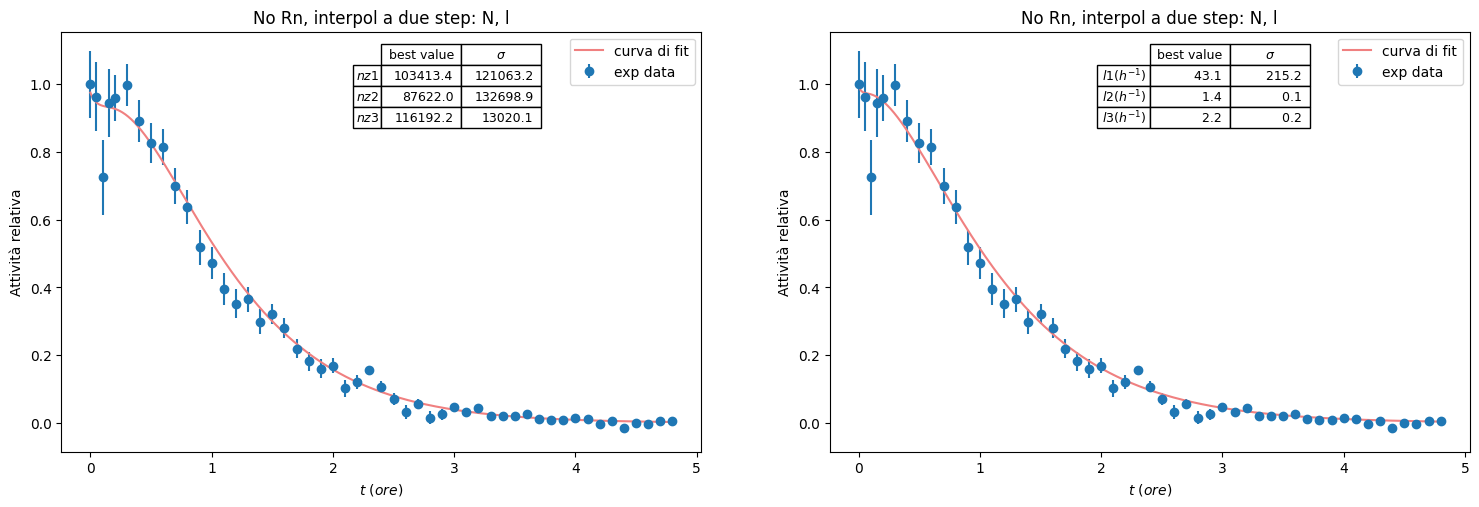

In [ ]:
#@title
# dati conteggi bismuto, no radon
# parametri di fit nz1, nz2, nz3 con lam1, lam2, lam3 tabulati
# catena formata da Po218, Pb214, Bi214 (e Po214)


dati1=np.loadtxt('/content/drive/MyDrive/Tesi/DatiSperimentali/EqTran/Dati2_Bateman.txt', dtype=float, delimiter="\t", skiprows=0)
# !rm -r /content/drive.google.com
# dati in quattro colonne, formato    t (min) \ t (s) \ n cont \ inc cont
dati1[:,0] = dati1[:,0]/60       #     t (h)      "        "        "
ut = 0      # colonna da usare per le unità di tempo: 0 == ore, 1 == secondi
tmax = dati1[-1,ut]
A3_0 = dati1[0,2]
dati1[:,3] = dati1[:,3]/A3_0
dati1[:,2] = dati1[:,2]/A3_0

lam1 = 3.729e-3*3600    # costante di decadimento del Po 218 in Pb 214 (h-1)
lam2 = 4.268e-4*3600    # costante di decadimento del Pb 214 in Bi 214 (h-1)
lam3 = 5.859e-4*3600    # costante di decadimento del Bi 214 in Po 214 (h-1)

def eqn3(ts, nz1, nz2, nz3):
     #-time-grid-----------------------------------
     t  = np.linspace(0, tmax, 10000)                            # per opzione interpolazione si può usare questo
     #differential-eq-system----------------------
     def funct(y,t):
        Nm1=y[0]
        Nm2=y[1]
        Nm3=y[2]
        # the model equations
        f1 = -lam1*Nm1         # = dN1/dt
        f2 = -lam2*Nm2+lam1*Nm1
        f3 = -lam3*Nm3+lam2*Nm2
        return [f1, f2, f3]
     #integrate------------------------------------
     Nz = nz1,nz2,nz3
     N  = integrate.odeint(funct,Nz,t)

     #opzione interpolazione
     N3 = N[:,2]
     N3f= itp.interp1d(t,N3,'cubic',fill_value="extrapolate")
     n3 = N3f(ts)

     #A1 = l1*n[:,0]
     #A2 = l2*n[:,1]
     A3 = lam3*n3                           # attività in cont/h se ut=0, in cont/s se ut=1
     A3 = A3/pow(3600,1-ut)               # attività in cont/s come dati sperimentali [l3*n3]=[cont/h]=[cont/(3600s)]
     A3 = A3/A3_0                         # attività relativa
     return (A3)
eqn3v=np.vectorize(eqn3)


min = [500, 500, 500]                               # minimum values for nz1, nz2, nz3
max = [mt.inf, mt.inf, mt.inf]                # maximum values for nz1, nz2, nz3
bounds=(min,max)
p0 = [10000,10000,10000]                         # guess iniziali                                                        # p0=[1.536,2.109,1700,1600,1800]
popt,  pcov = sop.curve_fit(eqn3, dati1[:,ut], dati1[:,2], p0=p0, sigma=dati1[:,3])#, bounds=bounds)
ndata = len(dati1[:,0])
nz1= popt[0]
nz2= popt[1]
nz3= popt[2]
standard_error1 = np.sqrt(np.diag(pcov))
sigma = np.sqrt(ndata*np.diag(pcov))

# calcolo il coefficiente R2 per valutare la bontà del fit
ts = dati1[:,ut]
y  = dati1[:,2]
tfit=np.linspace(0, tmax, num=1000)
residuals = y - eqn3(ts,popt[0],popt[1],popt[2])
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y-np.mean(y))**2)
r_squared_1 = 1 - (ss_res / ss_tot)


plt.figure(figsize=(38,12))
plt.subplot(241)
plt.errorbar(dati1[:,ut], dati1[:,2], yerr=dati1[:,3], marker='o', fmt='', linestyle='', label='exp data')
plt.plot(tfit, eqn3(tfit,nz1,nz2,nz3), color='lightcoral', label='curva di fit')
plt.legend()
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività relativa")
#plt.title("Dati sperimentali e fit senza Radon")
plt.title("No Rn, interpol a due step: N, l")

# tabella parametri fit
rows = [r"$nz1$", r"$nz2$", r"$nz3$"]
cols = [r"best value", r"$ \sigma $"]
w, h = 2, 3
O = [[0 for x in range(w)] for y in range(h)]
for h in range(0,3):
  O[h][0]="%6.1f"%(popt[h])
  O[h][1]="%6.1f"%(standard_error1[h])
  #O[h][1]="%5.4f"%(sigma[h])
plt.table(cellText=O[:], rowLabels=rows, colLabels=cols,loc='top', bbox=[0.5,0.77,0.25,0.2])

#print("R2 = %2.4f" %(r_squared))


#-di-nuovo----------------------------------------------------------------
# parametri di fit l1, l2, l3 con nz1, nz2, nz3 di prima fissati

def eql3(ts, l1, l2, l3):
     #-time-grid-----------------------------------
     t  = np.linspace(0, tmax, 10000)                            # per opzione interpolazione si può usare questo
     #differential-eq-system----------------------
     def funct(y,t):
        Nm1=y[0]
        Nm2=y[1]
        Nm3=y[2]
        # the model equations
        f1 = -l1*Nm1         # = dN1/dt
        f2 = -l2*Nm2+l1*Nm1
        f3 = -l3*Nm3+l2*Nm2
        return [f1, f2, f3]
     #integrate------------------------------------
     Nz = nz1,nz2,nz3
     N  = integrate.odeint(funct,Nz,t)

     #opzione interpolazione
     N3 = N[:,2]
     N3f= itp.interp1d(t,N3,'cubic',fill_value="extrapolate")
     n3 = N3f(ts)

     #A1 = l1*n[:,0]
     #A2 = l2*n[:,1]
     A3 = l3*n3                           # attività in cont/h se ut=0, in cont/s se ut=1
     A3 = A3/pow(3600,1-ut)               # attività in cont/s come dati sperimentali [l3*n3]=[cont/h]=[cont/(3600s)]
     A3 = A3/A3_0                         # attività relativa
     return (A3)
eql3v=np.vectorize(eql3)

min=[1, 0.1, 0.2]                 # minimum values for l1, l2, l3, nz1, nz2, nz3
max=[100, 10, 15]                 # maximum values for l1, l2, l3, nz1, nz2, nz3
bounds=(min,max)
p0 = [lam1, lam2, lam3]           # guess iniziale lam tabulati
popt,  pcov = sop.curve_fit(eql3v, dati1[:,ut], dati1[:,2], p0=p0, sigma=dati1[:,3])#, bounds=bounds)
ndata = len(dati1[:,0])
l1 = popt[0]
l2 = popt[1]
l3 = popt[2]
standard_error1 = np.sqrt(np.diag(pcov))
sigma = np.sqrt(ndata*np.diag(pcov))

# calcolo il coefficiente R2 per valutare la bontà del fit
ts = dati1[:,ut]
y  = dati1[:,2]
tfit=np.linspace(0, tmax, num=1000)
residuals = y - eql3(ts,popt[0],popt[1],popt[2])
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y-np.mean(y))**2)
r_squared_1 = 1 - (ss_res / ss_tot)

plt.subplot(242)
plt.errorbar(dati1[:,ut], dati1[:,2], yerr=dati1[:,3], marker='o', fmt='', linestyle='', label='exp data')
plt.plot(tfit, eql3(tfit,l1,l2,l3), color='lightcoral', label='curva di fit')
plt.legend()
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività relativa")
#plt.title("Dati sperimentali e fit senza Radon")
plt.title("No Rn, interpol a due step: N, l")

# tabella parametri fit
rows = [r"$l1 (h^{-1})$", r"$l2 (h^{-1})$", r"$l3 (h^{-1})$"]
cols = [r"best value", r"$ \sigma $"]
w, h = 2, 3
O = [[0 for x in range(w)] for y in range(h)]
for h in range(0,3):
  O[h][0]="%6.1f"%(popt[h])
  O[h][1]="%6.1f"%(standard_error1[h])
  #O[h][1]="%5.4f"%(sigma[h])
plt.table(cellText=O[:], rowLabels=rows, colLabels=cols,loc='top', bbox=[0.5,0.77,0.25,0.2])

plt.show()

## Fit a 3 step: Pb - N - PoBi

Il valore tabulato per Pb214 è lambda_Pb = 1.54h-1


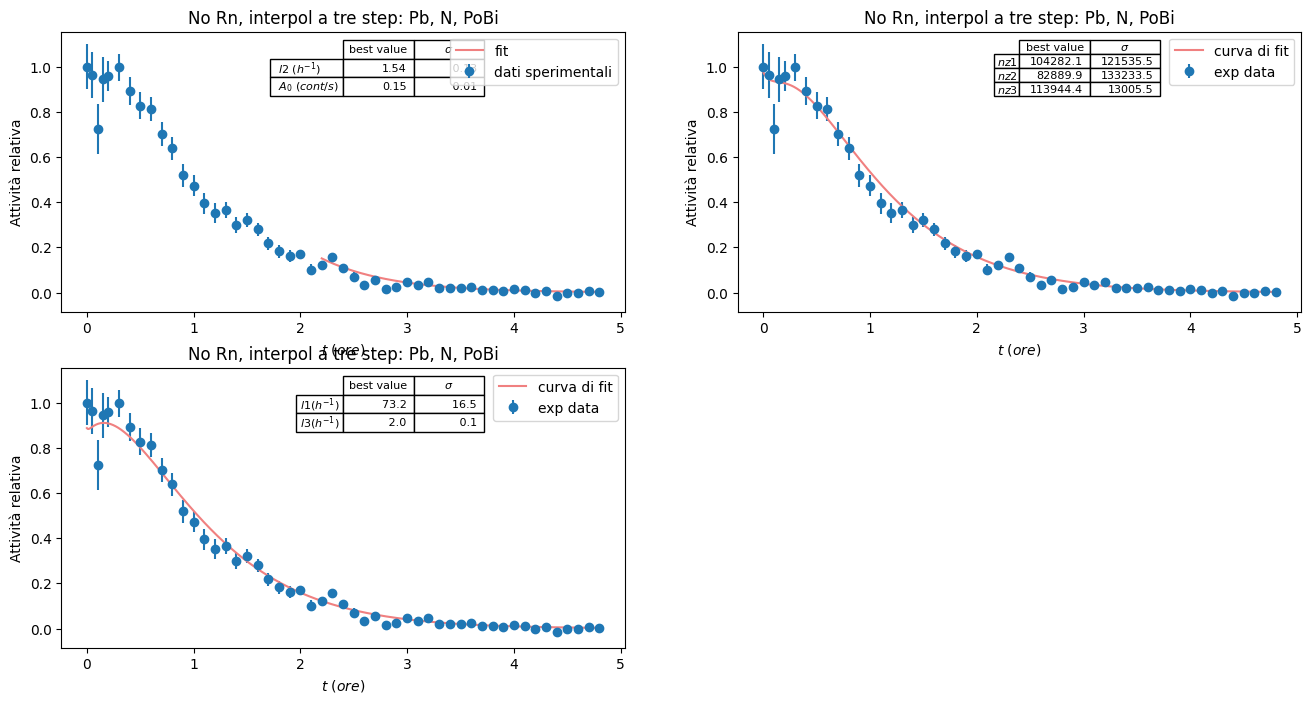

In [ ]:
#@title
# usa dati in ore o secondi dipendentemente da ut (se 0 ore, se 1 secondi)
# dati conteggi bismuto, no radon
# catena formata da Po218, Pb214, Bi214 (e Po214)

dati1=np.loadtxt('/content/drive/MyDrive/Tesi/DatiSperimentali/EqTran/Dati2_Bateman.txt', dtype=float, delimiter="\t", skiprows=0)
# !rm -r /content/drive.google.com
# dati in quattro colonne, formato    t (min) \ t (s) \ n cont \ inc cont
dati1[:,0] = dati1[:,0]/60       #     t (h)      "        "        "
ut = 0      # colonna da usare per le unità di tempo: 0 == ore, 1 == secondi
tmax = dati1[-1,ut]
A3_0 = dati1[0,2]
dati1[:,3] = dati1[:,3]/A3_0
dati1[:,2] = dati1[:,2]/A3_0


# fit dell'esponenziale asintotico per l2
# fit esponenziale per t >= tmin

tmin = 2.2    # ore, limite inferiore per il fit


def esp(tesp, l, A0):
  As = A0*np.exp(-l*(tesp-tmin))
  return As
espv = np.vectorize(esp)


dati2 = dati1[dati1[:,0] >= tmin, :]

min=[1e-6, 0]/(pow(3600,ut)*np.ones(2))       # minimum values for lRn, ARn0
max=[1000, mt.inf]/(pow(3600,ut)*np.ones(2))  # maximum values for lRn, ARn0
p0 =[1/pow(3600,ut)]
p0 =np.hstack((p0, 1))
bounds=(min,max)
popt,  pcov = sop.curve_fit(espv, dati2[:,0], dati2[:,2], p0=p0, sigma=dati2[:,3])
ndata = len(dati2[:,0])
l2 = round(popt[0],2)
A0 = popt[1]
standard_error1 = np.sqrt(np.diag(pcov))
sigma = np.sqrt(ndata*np.diag(pcov))

tf = np.linspace(tmin, tmax, num=1000)

plt.figure(figsize=(16,8))
plt.subplot(221)
plt.errorbar(dati1[:,ut], dati1[:,2], yerr=dati1[:,3], marker='o', fmt='', linestyle='', label='dati sperimentali')
plt.plot(tf, espv(tf, l2, A0), color='lightcoral', label='fit')
plt.legend()
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività relativa")
plt.title("No Rn, interpol a tre step: Pb, N, PoBi")
# tabella parametri fit
rows = [r"$ l2 \ (h^{-1})$", r"$ A_0 \ (cont/s)$"]
cols = [r"best value", r"$ \sigma $"]
w, h = 2, 2
O = [[0 for x in range(w)] for y in range(h)]
for h in range(0,2):
  O[h][0]="%4.2f"%(popt[h])
  O[h][1]="%5.2f"%(standard_error1[h])
  #O[h][1]="%5.2f"%(sigma[h])
plt.table(cellText=O[:], rowLabels=rows, colLabels=cols,loc='top', bbox=[0.5,0.77,0.25,0.2])

print('Il valore tabulato per Pb214 è lambda_Pb = 1.54h-1')



lam1 = 3.73e-3*3600    # costante di decadimento del Po 218 in Pb 214 (h-1)
lam3 = 5.86e-4*3600    # costante di decadimento del Bi 214 in Po 214 (h-1)

def eqn3(ts, nz1, nz2, nz3):
     #-time-grid-----------------------------------
     t  = np.linspace(0, tmax, 10000)                            # per opzione interpolazione si può usare questo
     #differential-eq-system----------------------
     def funct(y,t):
        Nm1=y[0]
        Nm2=y[1]
        Nm3=y[2]
        # the model equations
        f1 = -lam1*Nm1         # = dN1/dt
        f2 = -l2*Nm2+lam1*Nm1
        f3 = -lam3*Nm3+l2*Nm2
        return [f1, f2, f3]
     #integrate------------------------------------
     Nz = nz1,nz2,nz3
     N  = integrate.odeint(funct,Nz,t)

     #opzione interpolazione
     N3 = N[:,2]
     N3f= itp.interp1d(t,N3,'cubic',fill_value="extrapolate")
     n3 = N3f(ts)

     #A1 = l1*n[:,0]
     #A2 = l2*n[:,1]
     A3 = l3*n3                           # attività in cont/h se ut=0, in cont/s se ut=1
     A3 = A3/pow(3600,1-ut)               # attività in cont/s come dati sperimentali [l3*n3]=[cont/h]=[cont/(3600s)]
     A3 = A3/A3_0                         # attività relativa
     return (A3)
eqn3v=np.vectorize(eqn3)


min = [100, 0, 0]                               # minimum values for nz1, nz2, nz3
max = [mt.inf, mt.inf, mt.inf]                      # maximum values for nz1, nz2, nz3
bounds=(min,max)
p0 = [10000,10000,10000]                         # guess iniziali                                                        # p0=[1.536,2.109,1700,1600,1800]
popt,  pcov = sop.curve_fit(eqn3, dati1[:,ut], dati1[:,2], p0=p0, sigma=dati1[:,3], bounds=bounds)
ndata = len(dati1[:,0])
nz1= popt[0]
nz2= popt[1]
nz3= popt[2]
standard_error1 = np.sqrt(np.diag(pcov))
sigma = np.sqrt(ndata*np.diag(pcov))

# calcolo il coefficiente R2 per valutare la bontà del fit
ts = dati1[:,ut]
y  = dati1[:,2]
tfit=np.linspace(0, tmax, num=1000)
residuals = y - eqn3(ts,popt[0],popt[1],popt[2])
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y-np.mean(y))**2)
r_squared_1 = 1 - (ss_res / ss_tot)


plt.subplot(222)
plt.errorbar(dati1[:,ut], dati1[:,2], yerr=dati1[:,3], marker='o', fmt='', linestyle='', label='exp data')
plt.plot(tfit, eqn3(tfit,nz1,nz2,nz3), color='lightcoral', label='curva di fit')
plt.legend()
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività relativa")
#plt.title("Dati sperimentali e fit senza Radon")
plt.title("No Rn, interpol a tre step: Pb, N, PoBi")

# tabella parametri fit
rows = [r"$nz1$", r"$nz2$", r"$nz3$"]
cols = [r"best value", r"$ \sigma $"]
w, h = 2, 3
O = [[0 for x in range(w)] for y in range(h)]
for h in range(0,3):
  O[h][0]="%6.1f"%(popt[h])
  O[h][1]="%6.1f"%(standard_error1[h])
  #O[h][1]="%5.4f"%(sigma[h])
plt.table(cellText=O[:], rowLabels=rows, colLabels=cols,loc='top', bbox=[0.5,0.77,0.25,0.2])

#print("R2 = %2.4f" %(r_squared))


#-di-nuovo----------------------------------------------------------------
# parametro di fit l1 e l3 con parametri l2, nz1, nz2, nz3 di prima fissi

def eql3(ts, l1, l3):
     #-time-grid-----------------------------------
     t  = np.linspace(0, tmax, 10000)                            # per opzione interpolazione si può usare questo
     #differential-eq-system----------------------
     def funct(y,t):
        Nm1=y[0]
        Nm2=y[1]
        Nm3=y[2]
        # the model equations
        f1 = -l1*Nm1         # = dN1/dt
        f2 = -l2*Nm2+l1*Nm1
        f3 = -l3*Nm3+l2*Nm2
        return [f1, f2, f3]
     #integrate------------------------------------
     Nz = nz1,nz2,nz3
     N  = integrate.odeint(funct,Nz,t)

     #opzione interpolazione
     N3 = N[:,2]
     N3f= itp.interp1d(t,N3,'cubic',fill_value="extrapolate")
     n3 = N3f(ts)

     #A1 = l1*n[:,0]
     #A2 = l2*n[:,1]
     A3 = l3*n3                           # attività in cont/h se ut=0, in cont/s se ut=1
     A3 = A3/pow(3600,1-ut)               # attività in cont/s come dati sperimentali [l3*n3]=[cont/h]=[cont/(3600s)]
     A3 = A3/A3_0                         # attività relativa
     return (A3)
eql3v=np.vectorize(eql3)

min=[5, 0.2]                  # minimum values for l1, l3
max=[100, 15]                 # maximum values for l1, l3
bounds=(min,max)
p0 = [lam1, lam3]             # guess iniziale lam tabulati
popt,  pcov = sop.curve_fit(eql3v, dati1[:,ut], dati1[:,2], p0=p0, sigma=dati1[:,3], bounds=bounds)
ndata = len(dati1[:,0])
l1 = popt[0]
l3 = popt[1]
standard_error1 = np.sqrt(np.diag(pcov))
sigma = np.sqrt(ndata*np.diag(pcov))

# calcolo il coefficiente R2 per valutare la bontà del fit
ts = dati1[:,ut]
y  = dati1[:,2]
tfit=np.linspace(0, tmax, num=1000)
residuals = y - eql3(ts,popt[0],popt[1])
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y-np.mean(y))**2)
r_squared_1 = 1 - (ss_res / ss_tot)

plt.subplot(223)
plt.errorbar(dati1[:,ut], dati1[:,2], yerr=dati1[:,3], marker='o', fmt='', linestyle='', label='exp data')
plt.plot(tfit, eql3(tfit,l1,l3), color='lightcoral', label='curva di fit')
plt.legend()
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività relativa")
#plt.title("Dati sperimentali e fit senza Radon")
plt.title("No Rn, interpol a tre step: Pb, N, PoBi")

# tabella parametri fit
rows = [r"$l1 (h^{-1})$", r"$l3 (h^{-1})$"]
cols = [r"best value", r"$ \sigma $"]
w, h = 2, 2
O = [[0 for x in range(w)] for y in range(h)]
for h in range(0,2):
  O[h][0]="%6.1f"%(popt[h])
  O[h][1]="%6.1f"%(standard_error1[h])
  #O[h][1]="%5.4f"%(sigma[h])
plt.table(cellText=O[:], rowLabels=rows, colLabels=cols,loc='top', bbox=[0.5,0.77,0.25,0.2])

plt.show()

## Fit a 3 step: N - Pb - PoBi

Il valore tabulato per Pb214 è lambda_Pb = 1.32h-1


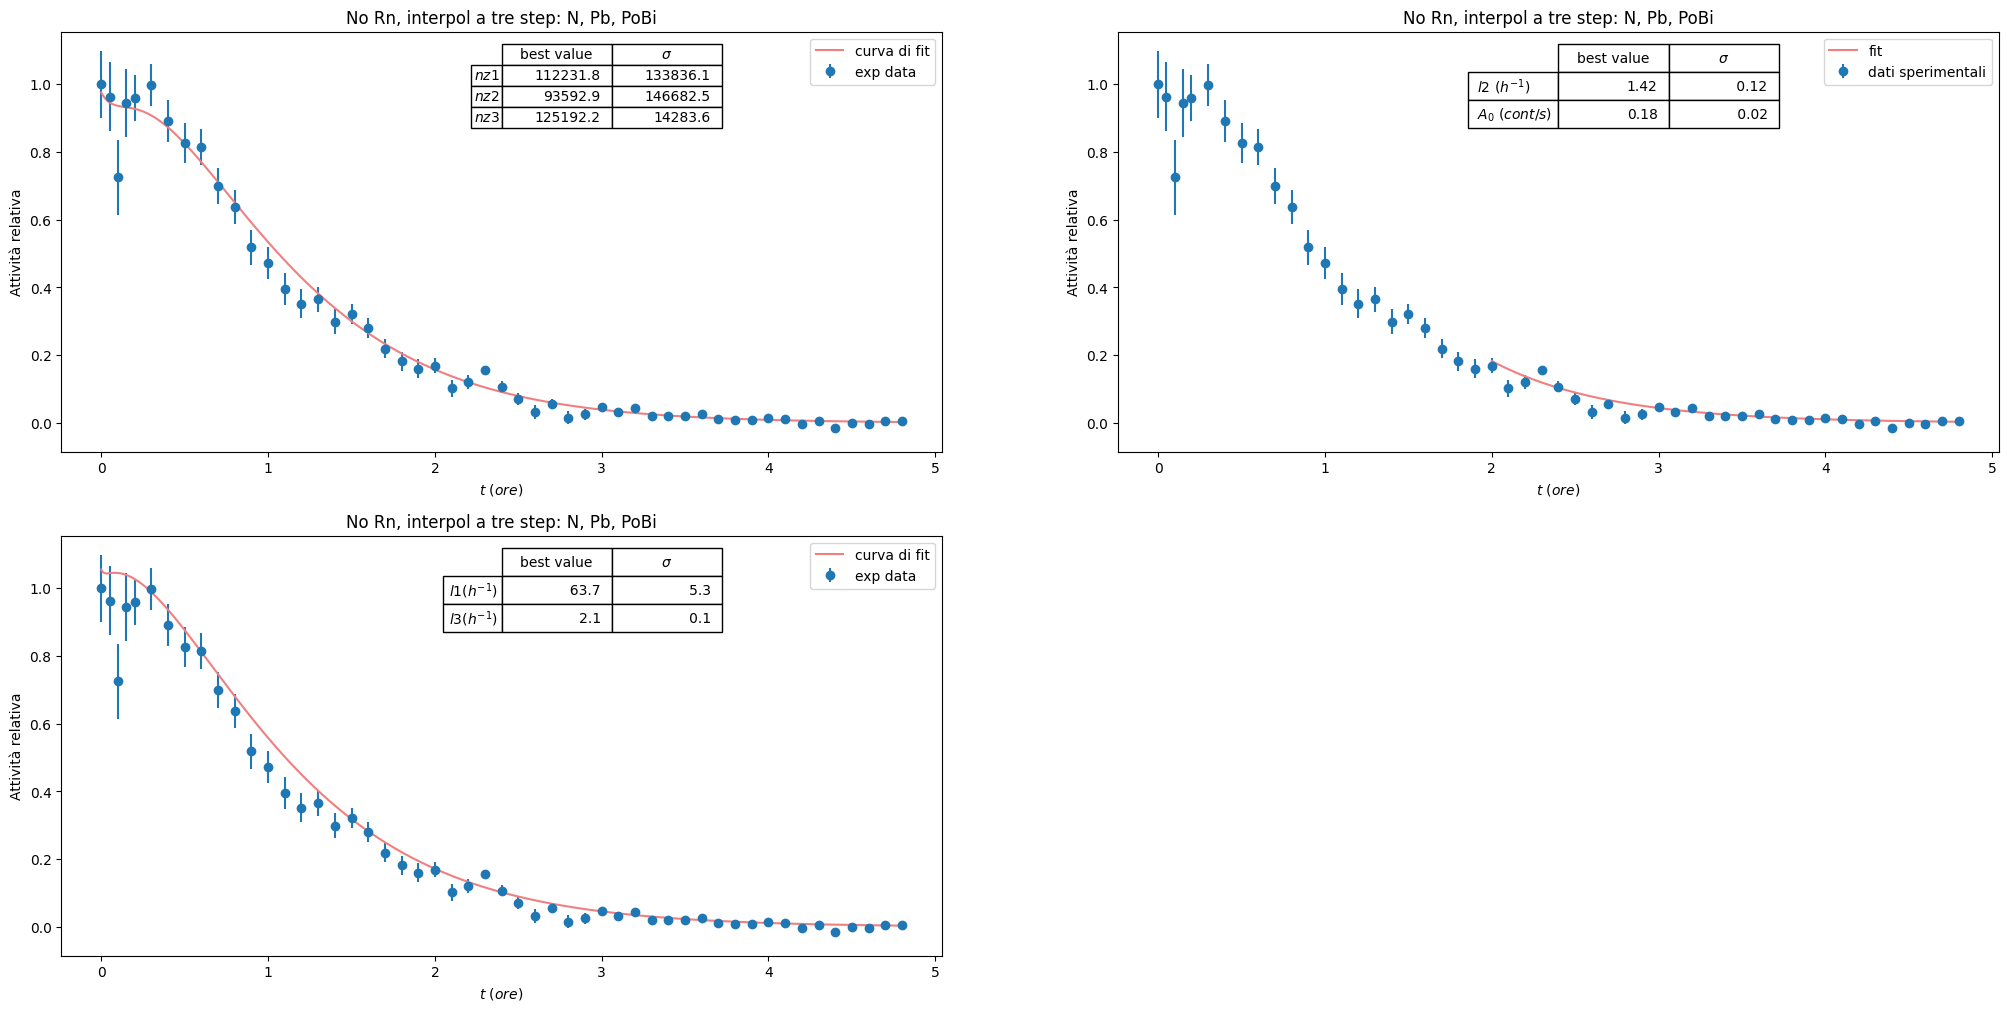

In [ ]:
#@title
# dati conteggi bismuto, no radon
# parametri di fit nz1, nz2, nz3 con lam1, lam2, lam3 tabulati
# catena formata da Po218, Pb214, Bi214 (e Po214)


dati1=np.loadtxt('/content/drive/MyDrive/Tesi/DatiSperimentali/EqTran/Dati2_Bateman.txt', dtype=float, delimiter="\t", skiprows=0)
# !rm -r /content/drive.google.com
# dati in quattro colonne, formato    t (min) \ t (s) \ n cont \ inc cont
dati1[:,0] = dati1[:,0]/60       #     t (h)      "        "        "
ut = 0      # colonna da usare per le unità di tempo: 0 == ore, 1 == secondi
tmax = dati1[-1,ut]
A3_0 = dati1[0,2]
dati1[:,3] = dati1[:,3]/A3_0
dati1[:,2] = dati1[:,2]/A3_0

lam1 = 3.73e-3*3600    # costante di decadimento del Po 218 in Pb 214 (h-1)
lam2 = 4.27e-4*3600    # costante di decadimento del Pb 214 in Bi 214 (h-1)
lam3 = 5.86e-4*3600    # costante di decadimento del Bi 214 in Po 214 (h-1)

def eqn3(ts, nz1, nz2, nz3):
     #-time-grid-----------------------------------
     t  = np.linspace(0, tmax, 10000)                            # per opzione interpolazione si può usare questo
     #differential-eq-system----------------------
     def funct(y,t):
        Nm1=y[0]
        Nm2=y[1]
        Nm3=y[2]
        # the model equations
        f1 = -lam1*Nm1         # = dN1/dt
        f2 = -lam2*Nm2+lam1*Nm1
        f3 = -lam3*Nm3+lam2*Nm2
        return [f1, f2, f3]
     #integrate------------------------------------
     Nz = nz1,nz2,nz3
     N  = integrate.odeint(funct,Nz,t)

     #opzione interpolazione
     N3 = N[:,2]
     N3f= itp.interp1d(t,N3,'cubic',fill_value="extrapolate")
     n3 = N3f(ts)

     #A1 = l1*n[:,0]
     #A2 = l2*n[:,1]
     A3 = l3*n3                           # attività in cont/h se ut=0, in cont/s se ut=1
     A3 = A3/pow(3600,1-ut)               # attività in cont/s come dati sperimentali [l3*n3]=[cont/h]=[cont/(3600s)]
     A3 = A3/A3_0                         # attività relativa
     return (A3)
eqn3v=np.vectorize(eqn3)


min = [500, 500, 500]                               # minimum values for nz1, nz2, nz3
max = [mt.inf, mt.inf, mt.inf]                # maximum values for nz1, nz2, nz3
bounds=(min,max)
p0 = [1700,1600,1800]                         # guess iniziali                                                        # p0=[1.536,2.109,1700,1600,1800]
popt,  pcov = sop.curve_fit(eqn3, dati1[:,ut], dati1[:,2], p0=p0, sigma=dati1[:,3])#, bounds=bounds)
ndata = len(dati1[:,0])
nz1= popt[0]
nz2= popt[1]
nz3= popt[2]
standard_error1 = np.sqrt(np.diag(pcov))
sigma = np.sqrt(ndata*np.diag(pcov))

# calcolo il coefficiente R2 per valutare la bontà del fit
ts = dati1[:,ut]
y  = dati1[:,2]
tfit=np.linspace(0, tmax, num=1000)
residuals = y - eqn3(ts,popt[0],popt[1],popt[2])
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y-np.mean(y))**2)
r_squared_1 = 1 - (ss_res / ss_tot)


plt.figure(figsize=(25,12))
plt.subplot(221)
plt.errorbar(dati1[:,ut], dati1[:,2], yerr=dati1[:,3], marker='o', fmt='', linestyle='', label='exp data')
plt.plot(tfit, eqn3(tfit,nz1,nz2,nz3), color='lightcoral', label='curva di fit')
plt.legend()
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività relativa")
#plt.title("Dati sperimentali e fit senza Radon")
plt.title("No Rn, interpol a tre step: N, Pb, PoBi")

# tabella parametri fit
rows = [r"$nz1$", r"$nz2$", r"$nz3$"]
cols = [r"best value", r"$ \sigma $"]
w, h = 2, 3
O = [[0 for x in range(w)] for y in range(h)]
for h in range(0,3):
  O[h][0]="%6.1f"%(popt[h])
  O[h][1]="%6.1f"%(standard_error1[h])
  #O[h][1]="%5.4f"%(sigma[h])
plt.table(cellText=O[:], rowLabels=rows, colLabels=cols,loc='top', bbox=[0.5,0.77,0.25,0.2])

#print("R2 = %2.4f" %(r_squared))




# fit dell'esponenziale asintotico per l2
# fit esponenziale per t >= tmin

tmin = 2    # ore, limite inferiore per il fit


def esp(tesp, l, A0):
  As = A0*np.exp(-l*(tesp-tmin))
  return As
espv = np.vectorize(esp)


dati2 = dati1[dati1[:,0] >= tmin, :]

min=[1e-6, 0]/(pow(3600,ut)*np.ones(2))       # minimum values for lRn, ARn0
max=[1000, mt.inf]/(pow(3600,ut)*np.ones(2))  # maximum values for lRn, ARn0
p0 =[1/pow(3600,ut)]
p0 =np.hstack((p0, 1))
bounds=(min,max)
popt,  pcov = sop.curve_fit(espv, dati2[:,0], dati2[:,2], p0=p0, sigma=dati2[:,3])
ndata = len(dati2[:,0])
l2 = popt[0]
A0 = popt[1]
standard_error1 = np.sqrt(np.diag(pcov))
sigma = np.sqrt(ndata*np.diag(pcov))

tf = np.linspace(tmin, tmax, num=1000)

plt.subplot(222)
plt.errorbar(dati1[:,ut], dati1[:,2], yerr=dati1[:,3], marker='o', fmt='', linestyle='', label='dati sperimentali')
plt.plot(tf, espv(tf, l2, A0), color='lightcoral', label='fit')
plt.legend()
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività relativa")
plt.title("No Rn, interpol a tre step: N, Pb, PoBi")
# tabella parametri fit
rows = [r"$ l2 \ (h^{-1})$", r"$ A_0 \ (cont/s)$"]
cols = [r"best value", r"$ \sigma $"]
w, h = 2, 2
O = [[0 for x in range(w)] for y in range(h)]
for h in range(0,2):
  O[h][0]="%4.2f"%(popt[h])
  O[h][1]="%5.2f"%(standard_error1[h])
  #O[h][1]="%5.2f"%(sigma[h])
plt.table(cellText=O[:], rowLabels=rows, colLabels=cols,loc='top', bbox=[0.5,0.77,0.25,0.2])

print('Il valore tabulato per Pb214 è lambda_Pb = 1.32h-1')



# parametro di fit l1 e l3 con parametri l2, nz1, nz2, nz3 di prima fissi

def eql3(ts, l1, l3):
     #-time-grid-----------------------------------
     t  = np.linspace(0, tmax, 10000)                            # per opzione interpolazione si può usare questo
     #differential-eq-system----------------------
     def funct(y,t):
        Nm1=y[0]
        Nm2=y[1]
        Nm3=y[2]
        # the model equations
        f1 = -l1*Nm1         # = dN1/dt
        f2 = -l2*Nm2+l1*Nm1
        f3 = -l3*Nm3+l2*Nm2
        return [f1, f2, f3]
     #integrate------------------------------------
     Nz = nz1,nz2,nz3
     N  = integrate.odeint(funct,Nz,t)

     #opzione interpolazione
     N3 = N[:,2]
     N3f= itp.interp1d(t,N3,'cubic',fill_value="extrapolate")
     n3 = N3f(ts)

     #A1 = l1*n[:,0]
     #A2 = l2*n[:,1]
     A3 = l3*n3                           # attività in cont/h se ut=0, in cont/s se ut=1
     A3 = A3/pow(3600,1-ut)               # attività in cont/s come dati sperimentali [l3*n3]=[cont/h]=[cont/(3600s)]
     A3 = A3/A3_0                         # attività relativa
     return (A3)
eql3v=np.vectorize(eql3)

min=[5, 0.2]                  # minimum values for l1, l3
max=[100, 15]                 # maximum values for l1, l3
bounds=(min,max)
p0 = [lam1, lam3]             # guess iniziale lam tabulati
popt,  pcov = sop.curve_fit(eql3v, dati1[:,ut], dati1[:,2], p0=p0, sigma=dati1[:,3], bounds=bounds)
ndata = len(dati1[:,0])
l1 = popt[0]
l3 = popt[1]
standard_error1 = np.sqrt(np.diag(pcov))
sigma = np.sqrt(ndata*np.diag(pcov))

# calcolo il coefficiente R2 per valutare la bontà del fit
ts = dati1[:,ut]
y  = dati1[:,2]
tfit=np.linspace(0, tmax, num=1000)
residuals = y - eql3(ts,popt[0],popt[1])
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y-np.mean(y))**2)
r_squared_1 = 1 - (ss_res / ss_tot)

plt.subplot(223)
plt.errorbar(dati1[:,ut], dati1[:,2], yerr=dati1[:,3], marker='o', fmt='', linestyle='', label='exp data')
plt.plot(tfit, eql3(tfit,l1,l3), color='lightcoral', label='curva di fit')
plt.legend()
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività relativa")
#plt.title("Dati sperimentali e fit senza Radon")
plt.title("No Rn, interpol a tre step: N, Pb, PoBi")

# tabella parametri fit
rows = [r"$l1 (h^{-1})$", r"$l3 (h^{-1})$"]
cols = [r"best value", r"$ \sigma $"]
w, h = 2, 2
O = [[0 for x in range(w)] for y in range(h)]
for h in range(0,2):
  O[h][0]="%6.1f"%(popt[h])
  O[h][1]="%6.1f"%(standard_error1[h])
  #O[h][1]="%5.4f"%(sigma[h])
plt.table(cellText=O[:], rowLabels=rows, colLabels=cols,loc='top', bbox=[0.5,0.77,0.25,0.2])

plt.show()

## Fit a 5 parametri a interpolazione

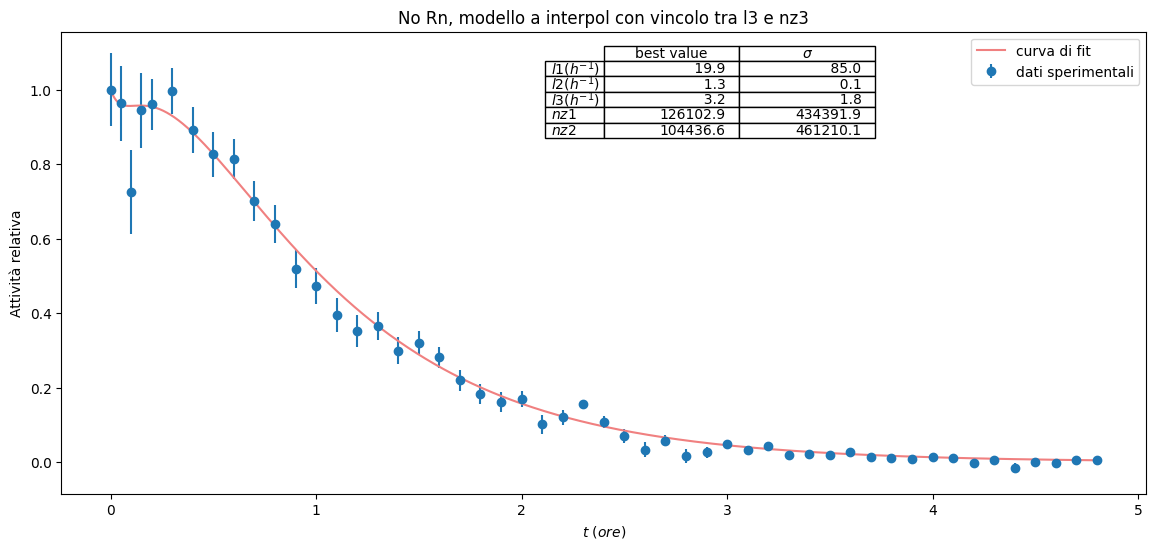

R2 = 0.9852


In [ ]:
#@title
# dati conteggi bismuto, no radon
# parametri di fit l1, l2, l3, nz1, nz2, nz3
# catena formata da Po218, Pb214, Bi214 (e Po214)
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy import integrate
from scipy import interpolate as itp

dati1=np.loadtxt('/content/drive/MyDrive/Tesi/DatiSperimentali/EqTran/Dati2_Bateman.txt', dtype=float, delimiter="\t", skiprows=0)
# !rm -r /content/drive.google.com
# dati in quattro colonne, formato    t (min) \ t (s) \ n cont \ inc cont
dati1[:,0] = dati1[:,0]/60       #     t (h)      "        "        "
ut = 0      # colonna da usare per le unità di tempo: 0 == ore, 1 == secondi
tmax = dati1[-1,ut]
A3_0 = dati1[0,2]
dati1[:,3] = dati1[:,3]/A3_0
dati1[:,2] = dati1[:,2]/A3_0


def eq3(ts, l1, l2, l3, nz1, nz2):
     #-time-grid-----------------------------------
     t  = np.linspace(0, tmax, 10000)                            # per opzione interpolazione si può usare questo
     #differential-eq-system----------------------
     def funct(y,t):
        Nm1=y[0]
        Nm2=y[1]
        Nm3=y[2]
        # the model equations
        f1 = -l1*Nm1         # = dN1/dt
        f2 = -l2*Nm2+l1*Nm1
        f3 = -l3*Nm3+l2*Nm2
        return [f1, f2, f3]
     #integrate------------------------------------
     Nz = nz1,nz2,((A3_0)*pow(3600,1-ut)/l3)
     N  = integrate.odeint(funct,Nz,t)

     #opzione interpolazione
     N3 = N[:,2]
     N3f= itp.interp1d(t,N3,'cubic',fill_value="extrapolate")
     n3 = N3f(ts)

     #A1 = l1*n[:,0]
     #A2 = l2*n[:,1]
     A3 = l3*n3                           # attività in cont/h se ut=0, in cont/s se ut=1
     A3 = A3/pow(3600,1-ut)               # attività in cont/s come dati sperimentali [l3*n3]=[cont/h]=[cont/(3600s)]
     A3 = A3/A3_0                         # normalizzazione
     return (A3)
eq3v=np.vectorize(eq3)


min=[5, 0.5, 0.7]/(pow(3600,ut)*np.ones(3))                  # minimum values for l1, l2, l3, nz1, nz2
min = np.hstack((min, [0, 0]))
max=[100, 10, 15]/(pow(3600,ut)*np.ones(3))                  # maximum values for l1, l2, l3, nz1, nz2
max = np.hstack((max, [mt.inf, mt.inf]))
bounds=(min,max)
p0 = [13.42,1.536,2.109]/(pow(3600,ut)*np.ones(3))           # guess iniziali
p0 = np.hstack((p0, [100000,100000]))
popt,  pcov = sop.curve_fit(eq3, dati1[:,ut], dati1[:,2], p0=p0, sigma=dati1[:,3], bounds=bounds)
ndata = len(dati1[:,0])
l1 = popt[0]
l2 = popt[1]
l3 = popt[2]
nz1= popt[3]
nz2= popt[4]
standard_error1 = np.sqrt(np.diag(pcov))
sigma = np.sqrt(ndata*np.diag(pcov))

# calcolo il coefficiente R2 per valutare la bontà del fit
ts = dati1[:,ut]
y  = dati1[:,2]
tfit=np.linspace(0, tmax, num=1000)
residuals = y - eq3(ts,popt[0],popt[1],popt[2],popt[3],popt[4])
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y-np.mean(y))**2)
r_squared = 1 - (ss_res / ss_tot)


plt.figure(figsize=(14,6))
plt.errorbar(dati1[:,ut], dati1[:,2], yerr=dati1[:,3], marker='o', fmt='', linestyle='', label='dati sperimentali')
plt.plot(tfit, eq3(tfit,l1,l2,l3,nz1,nz2), color='lightcoral', label='curva di fit')
plt.legend()
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività relativa")
#plt.title("Dati sperimentali e fit senza Radon")
plt.title("No Rn, modello a interpol con vincolo tra l3 e nz3")

# tabella parametri fit
rows = [r"$l1 (h^{-1})$", r"$l2 (h^{-1})$", r"$l3 (h^{-1})$", r"$nz1$", r"$nz2$"]
cols = [r"best value", r"$ \sigma $"]
w, h = 2, 5
O = [[0 for x in range(w)] for y in range(h)]
for h in range(0,5):
  O[h][0]="%5.1f"%(popt[h])
  O[h][1]="%5.1f"%(standard_error1[h])
  #O[h][1]="%5.4f"%(sigma[h])
plt.table(cellText=O[:], rowLabels=rows, colLabels=cols,loc='top', bbox=[0.5,0.77,0.25,0.2])

plt.show()
print("R2 = %2.4f" %(r_squared))

## Modello Giacomo Salsi senza Pb214

Parameters([('N1_0', <Parameter 'N1_0', value=10000.0, bounds=[0:inf]>), ('N2_0', <Parameter 'N2_0', value=10000.0, bounds=[0:inf]>), ('N3_0', <Parameter 'N3_0', value=10000.0, bounds=[0:inf]>), ('l_Po', <Parameter 'l_Po', value=13.425896028414595, bounds=[0:inf]>), ('l_Bi', <Parameter 'l_Bi', value=2.10958904109589, bounds=[0:inf]>)])
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 83
    # data points      = 51
    # variables        = 5
    chi-square         = 68.7881347
    reduced chi-square = 1.49539423
    Akaike info crit   = 25.2594875
    Bayesian info crit = 34.9186156
[[Variables]]
    N1_0:  157971.635 +/- 1039319.70 (657.92%) (init = 10000)
    N2_0:  5957.63797 +/- 1041080.28 (17474.72%) (init = 10000)
    N3_0:  142952.345 +/- 20947.4420 (14.65%) (init = 10000)
    l_Po:  106.387517 +/- 1187.57283 (1116.27%) (init = 13.4259)
    l_Bi:  1.75542746 +/- 0.14929240 (8.50%) (init = 2.109589)
[[Correlations]] (unreported correlations are < 0.100)

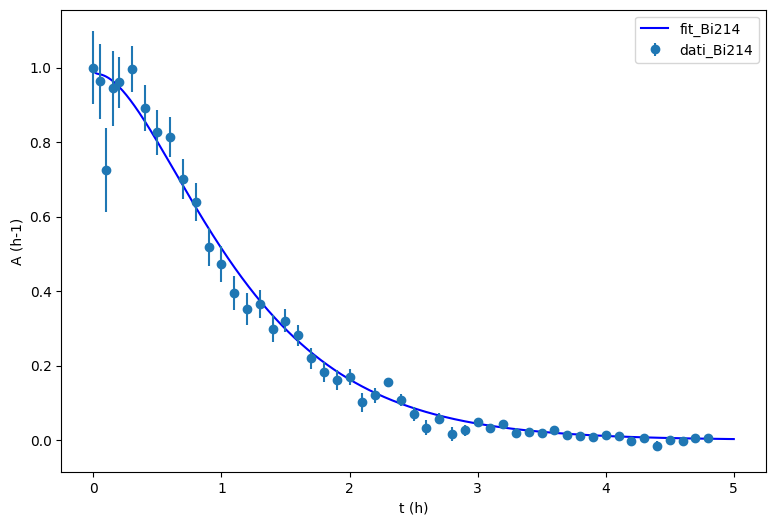

In [ ]:
# Script per la soluzione di un sistema di equazioni differenziali accoppiate e fit su dati sperimentali

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Load dei dati
data = np.loadtxt('/content/drive/MyDrive/Tesi/DatiSperimentali/EqTran/Dati2_Bateman.txt', dtype=float, delimiter="\t", skiprows=0)
data[:,0] = data[:,0]/60
A3_0 = data[0,2]
data[:,3] = data[:,3]/A3_0
data[:,2] = data[:,2]/A3_0
# dati in quattro colonne, formato    t (h) \ t (s) \ n cont/h \ inc cont/h

l2=1.54 #h-1

# Definizione del modello
def model(N, t, l):

	N1, N2, N3 = N
	l1, l3 = l #l2,

	dN1dt = - l1 * N1
	dN2dt = - l2 * N2 + l1 * N1
	dN3dt = - l3 * N3 + l2 * N2

	dNdt = [dN1dt, dN2dt, dN3dt]

	return dNdt


# Soluzione delle equazioni differenziali
def risolvi(t, N_0, l):

	x = odeint(model, N_0, t, args = (l,) )

	return x



# Residui per il fit
def residui(paras, t, data, errors):

	N0 = paras['N1_0'].value, paras['N2_0'].value, paras['N3_0'].value
	l = paras['l_Po'].value,  paras['l_Bi'].value #paras['l_Pb'].value,
	model = risolvi(t, N0, l)

	N3_model = model[:, 2]
	#print(np.shape(N3_model))
	A3_model = N3_model*l[1]/3600
	Ar3_model= A3_model/A3_0
	#print(N3_model)

	# Definizione dei residui
	resids = Ar3_model - data
	weighted = np.sqrt(resids ** 2 / errors ** 2)
	return weighted




# Condizioni iniziali
N1_0 = 10000.
N2_0 = 10000.
N3_0 = 10000.

N_0 = (N1_0, N2_0, N3_0)

# Punti temporali
n = 10000                        # numero di punti
t = np.linspace(0, 5, n)

# Parametri:

# Tempi di dimezzamento isotopi (h)
hl_Po218 = 3.097/60
hl_Pb214 = 27.06/60
hl_Bi214 = 19.71/60

# Costanti decadimento    (1/h)
Po218 = 0.693 / hl_Po218
Pb214 = 0.693 / hl_Pb214
Bi214 = 0.693 / hl_Bi214



l = (Po218, Bi214) #Pb214,



# Risoluzione delle equazioni con il guess dei parametri
result = risolvi(t, N_0, l)


# Fit modello sui dati sperimentali:

# 1) Impostazione dei parametri
params = Parameters()
params.add('N1_0', value = N_0[0], min=0)
params.add('N2_0', value = N_0[1], min=0)
params.add('N3_0', value = N_0[2], min=0)
params.add('l_Po', value = l[0], min=0)
#params.add('l_Pb', value = l[1], min=0)
params.add('l_Bi', value = l[1], min=0)
print(params)


# 2) Fit con il metodo dei minimi quadrati
fit = minimize(residui, params, args = (data[:, 0], data[:, 2], data[:, 3]))

# 3) Risoluzione delle equazioni con i parametri del fit
N10_fit = fit.params['N1_0'].value
N20_fit = fit.params['N2_0'].value
N30_fit = fit.params['N3_0'].value
l1_fit = fit.params['l_Po'].value
#l2_fit = fit.params['l_Pb'].value
l3_fit = fit.params['l_Bi'].value
N0_fit = (N10_fit, N20_fit, N30_fit)
l_fit = (l1_fit, l3_fit) #l2_fit,

data_fit = risolvi(t, N0_fit, l_fit)

# 4) Risultati del fit
report_fit(fit)
print(" ")
t1mezzi=0.693/l1_fit
#t2mezzi=0.693/l2_fit
t3mezzi=0.693/l3_fit

et1mezzi=(fit.covar[3][3]**0.5/l1_fit)*t1mezzi
#et2mezzi=(fit.covar[4][4]**0.5/l2_fit)*t2mezzi
et3mezzi=(fit.covar[4][4]**0.5/l3_fit)*t3mezzi


print('218Po fitted Half life' ,"%.2f" %t1mezzi ,"+-","%.2f"%et1mezzi,"h" ,  '(Initial', hl_Po218 ,")")
#print('214Pb fitted Half life' ,"%.2f" %t2mezzi,"+-","%.2f" %et2mezzi, "h" , '(Initial', hl_Pb214 ,")")
print('214Bi fitted Half life' ,"%.2f" %t3mezzi,"+-","%.2f" %et3mezzi,"h" , '(Initial', hl_Bi214 ,")")



# Plot grafico dei risultati
plt.figure(figsize=(20,6))
plt.subplot(121)
#plt.plot(t, l1_fit*data_fit[:, 0], 'r-', label='Pb')
#plt.plot(t, l2_fit*data_fit[:, 1], 'g-', label='Po')
plt.plot(t, l3_fit*data_fit[:, 2]/(A3_0*3600), 'b-', label='fit_Bi214')
plt.errorbar(data[:, 0], data[:, 2], yerr = data[:, 3], fmt='o', label='dati_Bi214')
#plt.scatter(data[:, 0], data[:, 2], label='dati_Bi')
plt.xlabel("t (h)")
plt.ylabel("A (h-1)")
plt.legend()
#plt.subplot(122)
#plt.plot(t, data_fit[:, 2], 'b-', label='Bi')
#plt.errorbar(data[:, 0], data[:, 2]/l3_fit, yerr = data[:, 3]/l3_fit, fmt='o', label='dati_Bi')
#plt.xlabel("t (min)")
#plt.ylabel("N")
#plt.legend()
plt.show()
plt.close()

## Fit con forma funzionale

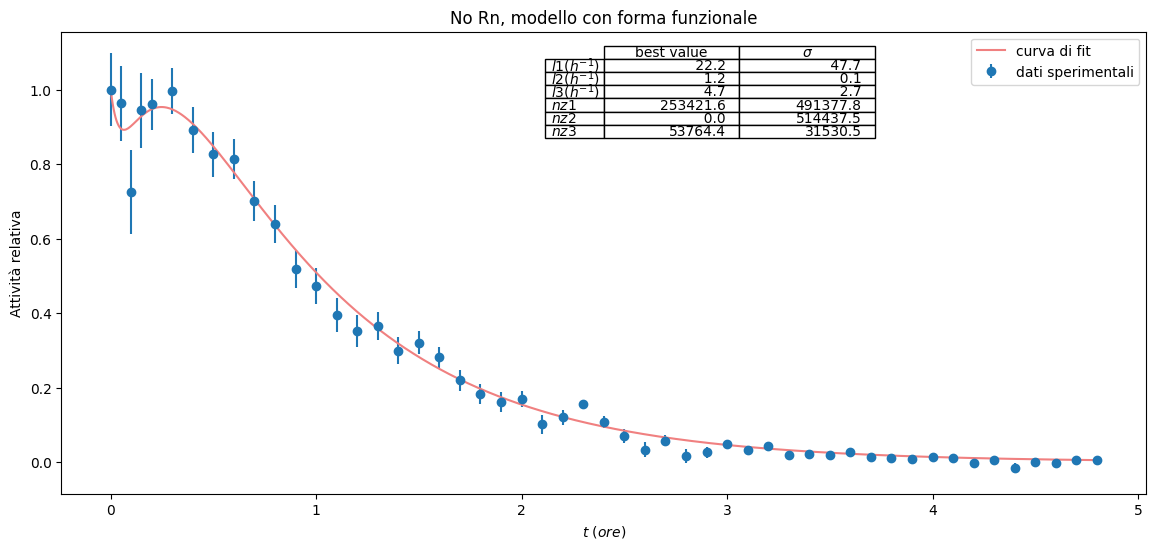

R2 = 0.9889


In [ ]:
dati1=np.loadtxt('/content/drive/MyDrive/Tesi/DatiSperimentali/EqTran/Dati2_Bateman.txt', dtype=float, delimiter="\t", skiprows=0)
# !rm -r /content/drive.google.com
# dati in quattro colonne, formato    t (min) \ t (s) \ n cont \ inc cont
dati1[:,0] = dati1[:,0]/60       #     t (h)      "        "        "
ut = 0        # colonna da usare per le unità di tempo: 0 == ore, 1 == secondi          tenere 0
tmin = 2.2   # ore, limite inferiore per il fit su l2
tmax1 = dati1[-1,ut]
tmax2 = 4.8   # ore, limite inferiore per il fit su l1 e l3
A3_0 = dati1[0,2]
dati1[:,3] = dati1[:,3]/A3_0
dati1[:,2] = dati1[:,2]/A3_0
#dati1 = dati1[dati1[:,2] > 0, :]
dati2 = dati1[dati1[:,0] >= tmin,  :]
dati3 = dati1[dati1[:,0] <= tmax2, :]

# fit A3
def A3fun(ts, l1, l2, l3, nz1, nz2, nz3):
  n3 = (l1*l2/((l2-l1)*(l3-l1)))*nz1*np.exp(-l1*ts) + (l2/(l3-l2))*(nz2-(l1/(l2-l1))*nz1)*np.exp(-l2*ts) + (nz3-(l2/(l3-l2))*nz2+(l1*l2/((l3-l2)*(l3-l1)))*nz1)*np.exp(-l3*ts)
  A3 = l3*n3                           # attività in cont/h se ut=0, in cont/s se ut=1
  A3 = A3/pow(3600,1-ut)               # attività in cont/s come dati sperimentali [l3*n3]=[cont/h]=[cont/(3600s)]
  A3 = A3/A3_0                         # attività relativa
  return A3
A3funv = np.vectorize(A3fun)

min=[5, 0.5, 0.7]/(pow(3600,ut)*np.ones(3))                  # minimum values for l1, l2, l3, nz1, nz2, nz3
min = np.hstack((min, [0, 0, 0]))
max=[100, 10, 15]/(pow(3600,ut)*np.ones(3))                  # maximum values for l1, l2, l3, nz1, nz2, nz3
max = np.hstack((max, [mt.inf, mt.inf, mt.inf]))
bounds=(min,max)
p0 = [13.42,1.536,2.109]/(pow(3600,ut)*np.ones(3))           # guess iniziali
p0 = np.hstack((p0, [20000,10000,10000]))
popt,  pcov = sop.curve_fit(A3funv, dati3[:,ut], dati3[:,2], p0=p0, sigma=dati3[:,3], bounds=bounds)      # p0=[13.42,1.536,2.109,1700,1600,1800]  p0=[40,1.2,2,100,10,35]
ndata = len(dati1[:,0])
l1 = popt[0]
l2 = popt[1]
l3 = popt[2]
nz1= popt[3]
nz2= popt[4]
nz3= popt[5]
standard_error1 = np.sqrt(np.diag(pcov))
sigma = np.sqrt(ndata*np.diag(pcov))

# calcolo il coefficiente R2 per valutare la bontà del fit
ts = dati1[:,ut]
y  = dati1[:,2]
tfit=np.linspace(0, tmax2, num=1000)
residuals = y - A3funv(ts,popt[0],popt[1],popt[2],popt[3],popt[4],popt[5])
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y-np.mean(y))**2)
r_squared = 1 - (ss_res / ss_tot)


plt.figure(figsize=(14,6))
plt.errorbar(dati3[:,ut], dati3[:,2], yerr=dati3[:,3], marker='o', fmt='', linestyle='', label='dati sperimentali')
plt.plot(tfit, A3funv(tfit,l1,l2,l3,nz1,nz2,nz3), color='lightcoral', label='curva di fit')
plt.legend()
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività relativa")
#plt.title("Dati sperimentali e fit senza Radon")
plt.title("No Rn, modello con forma funzionale")

# tabella parametri fit
rows = [r"$l1 (h^{-1})$", r"$l2 (h^{-1})$", r"$l3 (h^{-1})$", r"$nz1$", r"$nz2$", r"$nz3$"]
cols = [r"best value", r"$ \sigma $"]
w, h = 2, 6
O = [[0 for x in range(w)] for y in range(h)]
for h in range(0,6):
  O[h][0]="%5.1f"%(popt[h])
  O[h][1]="%5.1f"%(standard_error1[h])
  #O[h][1]="%5.4f"%(sigma[h])
plt.table(cellText=O[:], rowLabels=rows, colLabels=cols,loc='top', bbox=[0.5,0.77,0.25,0.2])

plt.show()
print("R2 = %2.4f" %(r_squared))

## Fit a 3 step: Pb - Bi - Po (diversi t)

Il valore tabulato per Pb214 è lambda_Pb = 1.54h-1


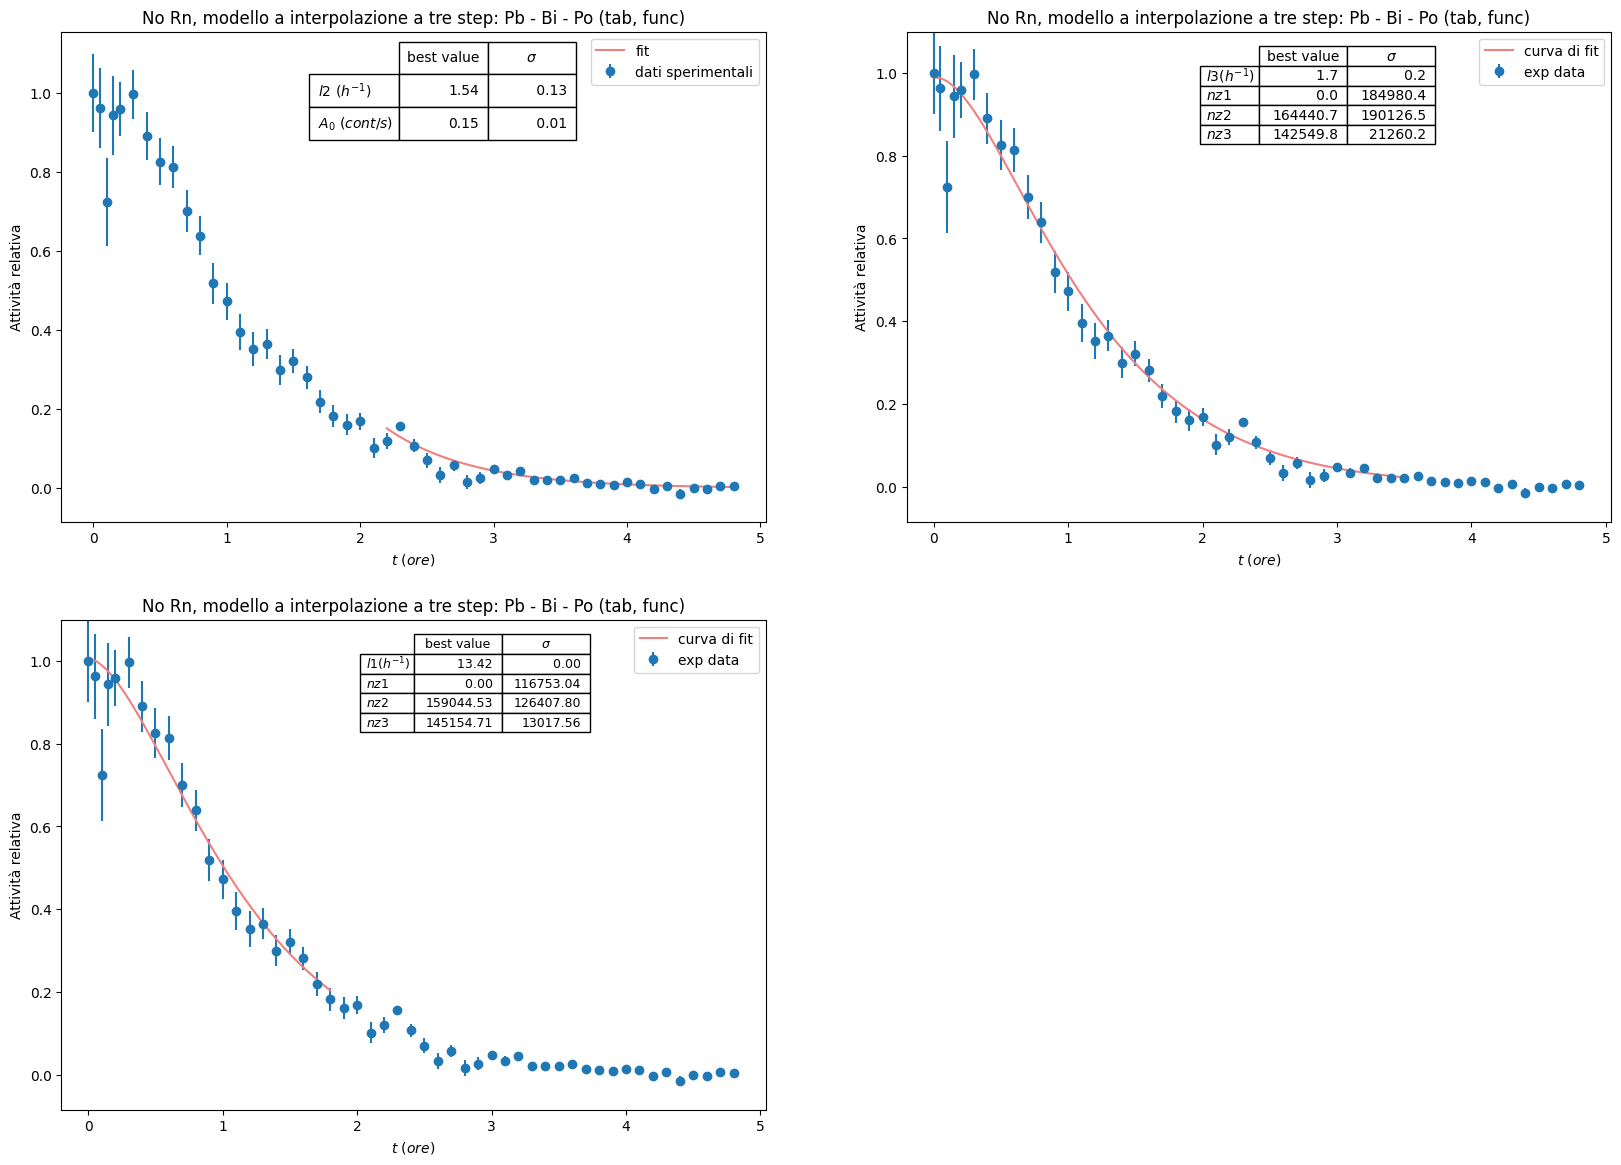

In [ ]:
#@title
# usa dati in ore o secondi dipendentemente da ut (se 0 ore, se 1 secondi)
# dati conteggi bismuto, no radon
# catena formata da Po218, Pb214, Bi214 (e Po214)

dati1=np.loadtxt('/content/drive/MyDrive/Tesi/DatiSperimentali/EqTran/Dati2_Bateman.txt', dtype=float, delimiter="\t", skiprows=0)
# !rm -r /content/drive.google.com
# dati in quattro colonne, formato    t (min) \ t (s) \ n cont \ inc cont
dati1[:,0] = dati1[:,0]/60       #     t (h)      "        "        "
ut = 0        # colonna da usare per le unità di tempo: 0 == ore, 1 == secondi          tenere 0
tmax1 = dati1[-1,ut]
tmin1 = 2.2   # ore, limite inferiore per il fit su l2
tmin2 = 0   # ore, limite inferiore per il fit su l1 e l3
tmax2 = 3.5   # ore, limite superiore per il fit su l3
tmax3 = 1.8   # ore, limite superiore per il fit su l1
A3_0 = dati1[0,2]
dati1[:,3] = dati1[:,3]/A3_0
dati1[:,2] = dati1[:,2]/A3_0
#dati1 = dati1[dati1[:,2] > 0, :]
dati2 = dati1[dati1[:,0] >= tmin1, :]
dati3 = dati1[dati1[:,0] >= tmin2, :]
dati3 = dati3[dati3[:,0] <= tmax2, :]
dati4 = dati1[dati1[:,0] >= tmin2, :]
dati4 = dati4[dati4[:,0] <= tmax3, :]

# fit dell'esponenziale asintotico per l2
# fit esponenziale per t >= tmin1

def esp(tesp, l, A0):
  As = A0*np.exp(-l*(tesp-tmin1))
  return As
espv = np.vectorize(esp)

min=[1e-6, 0]/(pow(3600,ut)*np.ones(2))       # minimum values for lRn, ARn0
max=[1000, mt.inf]/(pow(3600,ut)*np.ones(2))  # maximum values for lRn, ARn0
p0 =[1/pow(3600,ut)]
p0 =np.hstack((p0, 1))
bounds=(min,max)
popt,  pcov = sop.curve_fit(espv, dati2[:,0], dati2[:,2], p0=p0, sigma=dati2[:,3])
ndata = len(dati2[:,0])
#l2 = popt[0]
l2 = round(popt[0], 2)
A0 = popt[1]
standard_error1 = np.sqrt(np.diag(pcov))
sigma = np.sqrt(ndata*np.diag(pcov))

tf = np.linspace(tmin1, tmax1, num=1000)

plt.figure(figsize=(20,14))
plt.subplot(221)
plt.errorbar(dati1[:,ut], dati1[:,2], yerr=dati1[:,3], marker='o', fmt='', linestyle='', label='dati sperimentali')
plt.plot(tf, espv(tf, l2, A0), color='lightcoral', label='fit')
plt.legend()
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività relativa")
plt.title("No Rn, modello a interpolazione a tre step: Pb - Bi - Po (tab, func)")
# tabella parametri fit
rows = [r"$ l2 \ (h^{-1})$", r"$ A_0 \ (cont/s)$"]
cols = [r"best value", r"$ \sigma $"]
w, h = 2, 2
O = [[0 for x in range(w)] for y in range(h)]
for h in range(0,2):
  O[h][0]="%4.2f"%(popt[h])
  O[h][1]="%5.2f"%(standard_error1[h])
  #O[h][1]="%5.2f"%(sigma[h])
plt.table(cellText=O[:], rowLabels=rows, colLabels=cols,loc='top', bbox=[0.48,0.78,0.25,0.2])

print('Il valore tabulato per Pb214 è lambda_Pb = 1.54h-1')


#-------------------------------------------------------------------------------

# fit l3
def A3fun(ts, l3, nz1, nz2, nz3):
  l1 = 13.42
  n3 = (l1*l2/((l2-l1)*(l3-l1)))*nz1*np.exp(-l1*ts) + (l2/(l3-l2))*(nz2-(l1/(l2-l1))*nz1)*np.exp(-l2*ts) + (nz3-(l2/(l3-l2))*nz2+(l1*l2/((l3-l2)*(l3-l1)))*nz1)*np.exp(-l3*ts)
  A3 = l3*n3                           # attività in cont/h se ut=0, in cont/s se ut=1
  A3 = A3/pow(3600,1-ut)               # attività in cont/s come dati sperimentali [l3*n3]=[cont/h]=[cont/(3600s)]
  A3 = A3/A3_0                         # attività relativa
  return A3
A3funv = np.vectorize(A3fun)

min=np.array([0.1])/pow(3600,ut)                  # minimum values for l3, nz1, nz2, nz3
min=np.hstack((min, [0, 0, 0]))
max=np.array([10])/pow(3600,ut)                   # maximum values for l3, nz1, nz2, nz3
max=np.hstack((max, [mt.inf, mt.inf, mt.inf]))
bounds=(min,max)
p0 =np.array([2.109])/pow(3600,ut)                # guess iniziali
p0 = np.hstack((p0, [10000,10000,10000]))                                                                        # p0=[1.536,2.109,1700,1600,1800]
popt,  pcov = sop.curve_fit(A3funv, dati3[:,ut], dati3[:,2], p0=p0, sigma=dati3[:,3], bounds=bounds)
ndata = len(dati1[:,0])
l3 = popt[0]
nz1= popt[1]
nz2= popt[2]
nz3= popt[3]
standard_error1 = np.sqrt(np.diag(pcov))
sigma = np.sqrt(ndata*np.diag(pcov))

# calcolo il coefficiente R2 per valutare la bontà del fit
ts = dati3[:,ut]
y  = dati3[:,2]
tfit=np.linspace(tmin2, tmax2, num=1000)
residuals = y - A3funv(ts,popt[0],popt[1],popt[2],popt[3])
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y-np.mean(y))**2)
r_squared_1 = 1 - (ss_res / ss_tot)


plt.subplot(222)
plt.errorbar(dati1[:,ut], dati1[:,2], yerr=dati1[:,3], marker='o', fmt='', linestyle='', label='exp data')
plt.plot(tfit, A3funv(tfit,l3,nz1,nz2,nz3), color='lightcoral', label='curva di fit')
plt.legend()
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività relativa")
plt.xlim(left=-0.2)
plt.ylim(top=1.1)
plt.title("No Rn, modello a interpolazione a tre step: Pb - Bi - Po (tab, func)")

# tabella parametri fit
rows = [r"$l3 (h^{-1})$", r"$nz1$", r"$nz2$", r"$nz3$"]
cols = [r"best value", r"$ \sigma $"]
w, h = 2, 4
O = [[0 for x in range(w)] for y in range(h)]
for h in range(0,4):
  O[h][0]="%6.1f"%(popt[h])
  O[h][1]="%6.1f"%(standard_error1[h])
  #O[h][1]="%5.4f"%(sigma[h])
plt.table(cellText=O[:], rowLabels=rows, colLabels=cols,loc='top', bbox=[0.5,0.77,0.25,0.2])

#print("R2 = %2.4f" %(r_squared))

#-------------------------------------------------------------------------------

# fit l1
def A3fun(ts, l1, nz1, nz2, nz3):
  n3 = (l1*l2/((l2-l1)*(l3-l1)))*nz1*np.exp(-l1*ts) + (l2/(l3-l2))*(nz2-(l1/(l2-l1))*nz1)*np.exp(-l2*ts) + (nz3-(l2/(l3-l2))*nz2+(l1*l2/((l3-l2)*(l3-l1)))*nz1)*np.exp(-l3*ts)
  A3 = l3*n3                           # attività in cont/h se ut=0, in cont/s se ut=1
  A3 = A3/pow(3600,1-ut)               # attività in cont/s come dati sperimentali [l3*n3]=[cont/h]=[cont/(3600s)]
  A3 = A3/A3_0                         # attività relativa
  return A3
A3funv = np.vectorize(A3fun)

min=np.array([1])/pow(3600,ut)                  # minimum values for l1, nz1, nz2, nz3
min=np.hstack((min, [0, 0, 0]))
max=np.array([100])/pow(3600,ut)                   # maximum values for l3, nz1, nz2, nz3
max=np.hstack((max, [mt.inf, mt.inf, mt.inf]))
bounds=(min,max)
p0 =np.array([13.42])/pow(3600,ut)                # guess iniziali
p0 = np.hstack((p0, [nz1,nz2,nz3]))
popt,  pcov = sop.curve_fit(A3funv, dati4[:,ut], dati4[:,2], p0=p0, sigma=dati4[:,3], bounds=bounds)
ndata = len(dati1[:,0])
l1 = popt[0]
nz1= popt[1]
nz2= popt[2]
nz3= popt[3]
standard_error1 = np.sqrt(np.diag(pcov))
sigma = np.sqrt(ndata*np.diag(pcov))

# calcolo il coefficiente R2 per valutare la bontà del fit
ts = dati4[:,ut]
y  = dati4[:,2]
tfit=np.linspace(tmin2, tmax3, num=1000)
residuals = y - A3funv(ts,popt[0],popt[1],popt[2],popt[3])
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y-np.mean(y))**2)
r_squared_1 = 1 - (ss_res / ss_tot)


plt.subplot(223)
plt.errorbar(dati1[:,ut], dati1[:,2], yerr=dati1[:,3], marker='o', fmt='', linestyle='', label='exp data')
plt.plot(tfit, A3funv(tfit,l1,nz1,nz2,nz3), color='lightcoral', label='curva di fit')
plt.legend()
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività relativa")
plt.xlim(left=-0.2)
plt.ylim(top=1.1)
plt.title("No Rn, modello a interpolazione a tre step: Pb - Bi - Po (tab, func)")

# tabella parametri fit
rows = [r"$l1 (h^{-1})$", r"$nz1$", r"$nz2$", r"$nz3$"]
#rows = [r"$l1 (h^{-1})$"]
cols = [r"best value", r"$ \sigma $"]
w, h = 2, 4
O = [[0 for x in range(w)] for y in range(h)]
for h in range(0,4):
  O[h][0]="%6.2f"%(popt[h])
  O[h][1]="%6.2f"%(standard_error1[h])
  #O[h][1]="%5.4f"%(sigma[h])
plt.table(cellText=O[:], rowLabels=rows, colLabels=cols,loc='top', bbox=[0.5,0.77,0.25,0.2])

#print("R2 = %2.4f" %(r_squared))
plt.show()

## Fit a due step: Pb - PoBi (vincolo da funz su nz1) [migliore!!!]

$R^2_{\lambda_{Pb}}$ = 0.800
media dei residui Pb = -0.007
Il valore tabulato per Pb214 è lambda_Pb = 1.54h-1
nz1 = 186429.92
nz2 = 2481.32
nz3 = 116586.07
R^2 del fit totale = 0.985


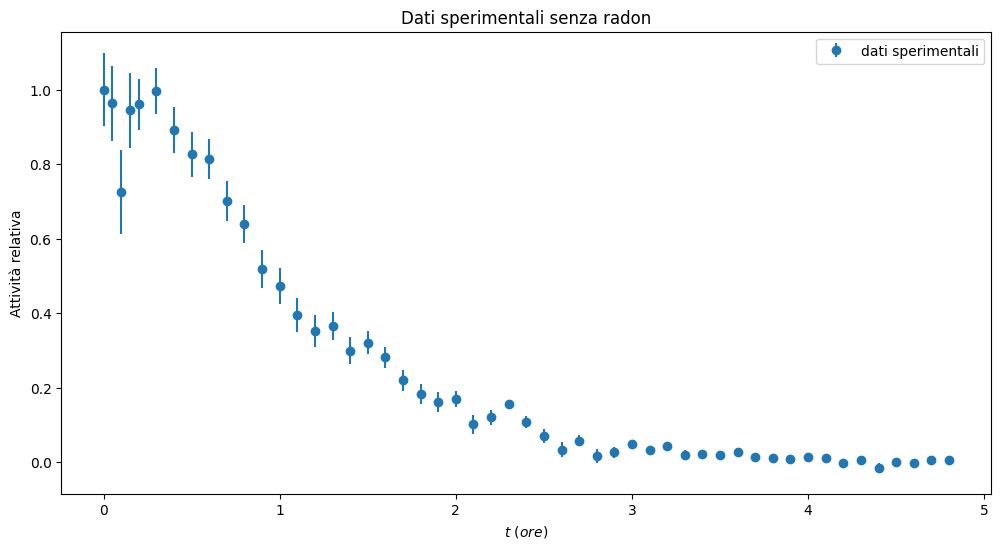

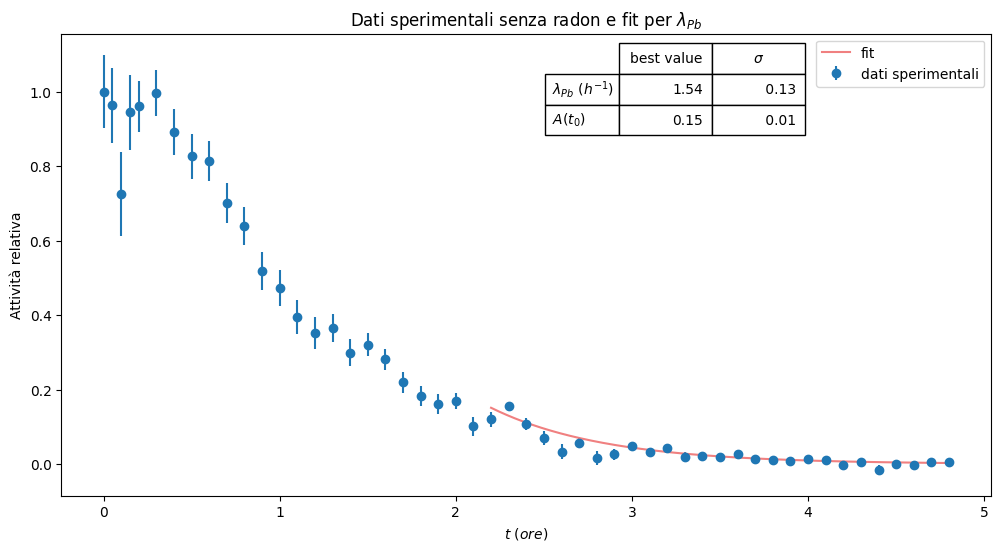

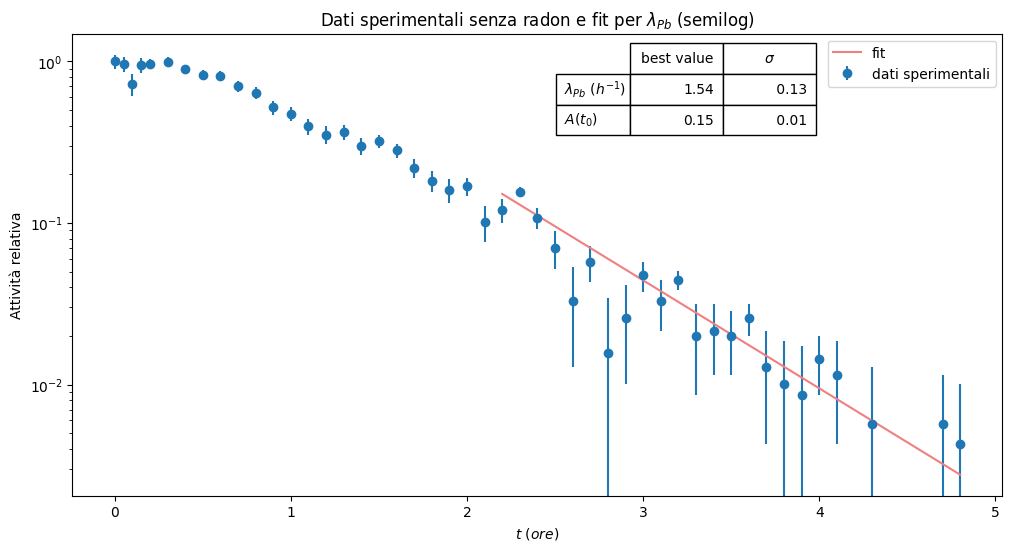

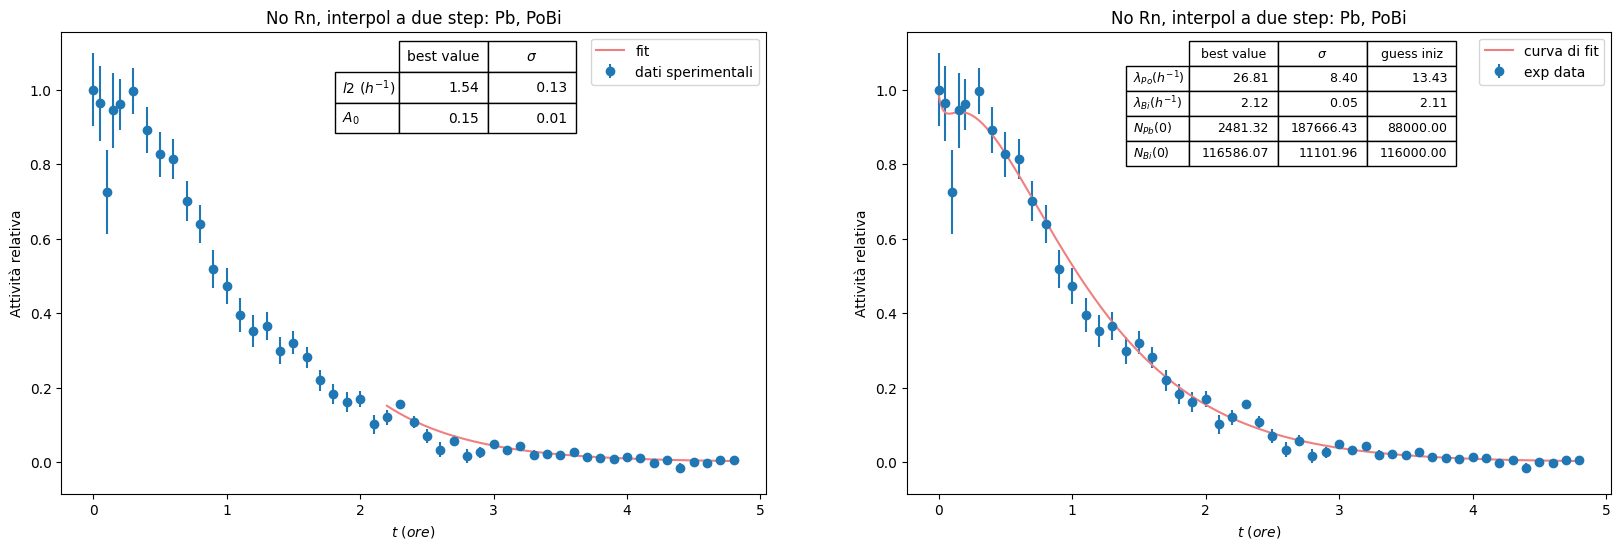

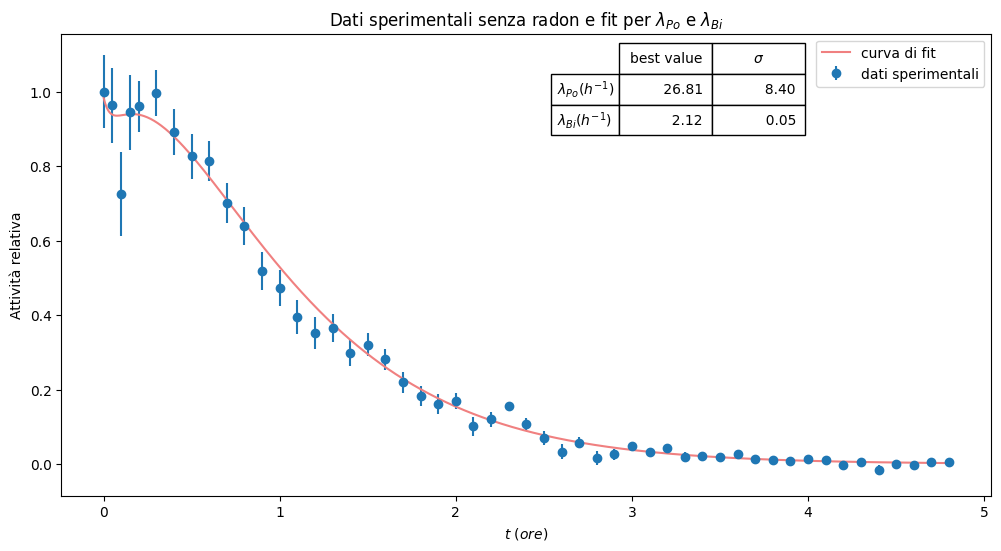

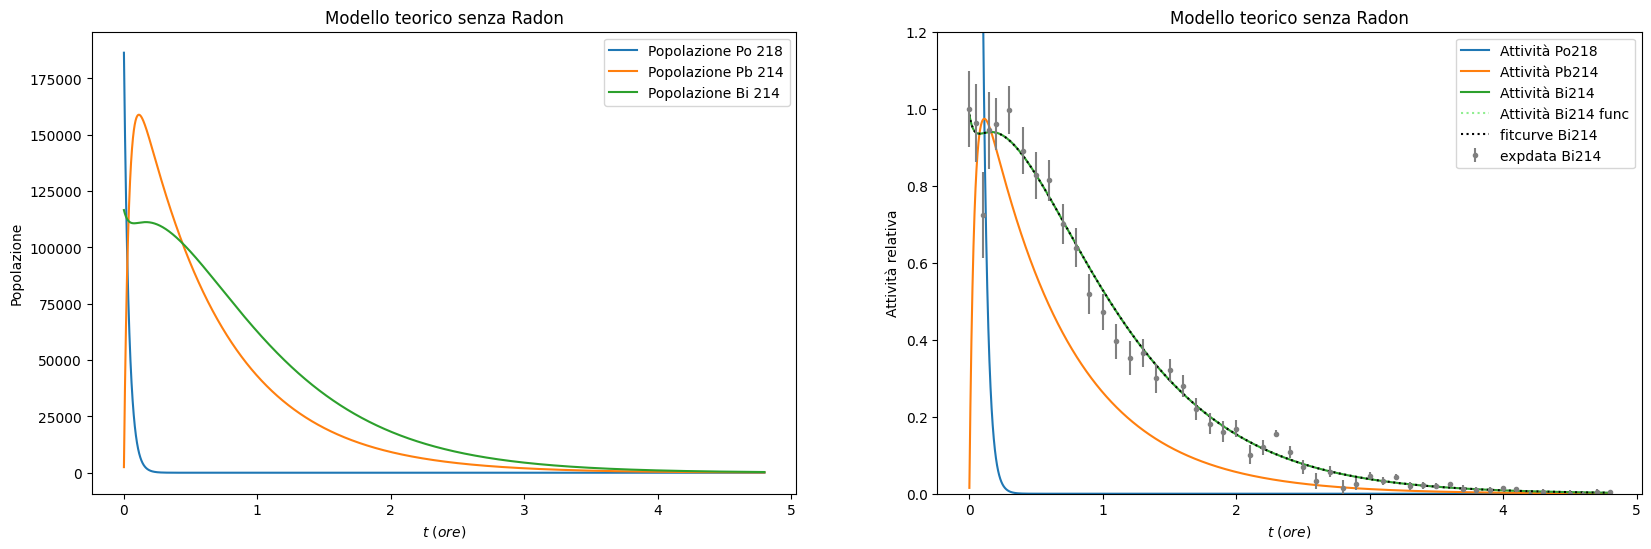

In [ ]:
#@title
# usa dati in ore o secondi dipendentemente da ut (se 0 ore, se 1 secondi)
# dati conteggi bismuto, no radon
# catena formata da Po218, Pb214, Bi214 (e Po214)

dati1=np.loadtxt('/content/drive/MyDrive/Tesi/DatiSperimentali/EqTran/Dati2_Bateman.txt', dtype=float, delimiter="\t", skiprows=0)
# !rm -r /content/drive.google.com
# dati in quattro colonne, formato    t (min) \ t (s) \ n cont \ inc cont
dati1[:,0] = dati1[:,0]/60       #     t (h)      "        "        "
ut = 0        # colonna da usare per le unità di tempo: 0 == ore, 1 == secondi          tenere 0
tmin = 2.2   # ore, limite inferiore per il fit su l2
tmax = dati1[-1,ut]
A3_0 = dati1[0,2]
dati1[:,3] = dati1[:,3]/A3_0
dati1[:,2] = dati1[:,2]/A3_0
#dati1 = dati1[dati1[:,2] > 0, :]
dati2 = dati1[dati1[:,0] >= tmin, :]
dati3 = dati1[dati1[:,0] <= tmax, :]

# fit dell'esponenziale asintotico per l2
# fit esponenziale per t >= tmin

def esp(tesp, l, A0):
  As = A0*np.exp(-l*(tesp-tmin))
  return As
espv = np.vectorize(esp)

min=[1e-6, 0]/(pow(3600,ut)*np.ones(2))       # minimum values for lRn, ARn0
max=[1000, mt.inf]/(pow(3600,ut)*np.ones(2))  # maximum values for lRn, ARn0
p0 =[1/pow(3600,ut)]
p0 =np.hstack((p0, 1))
bounds=(min,max)
popt,  pcov = sop.curve_fit(espv, dati2[:,0], dati2[:,2], p0=p0, sigma=dati2[:,3])
ndata = len(dati2[:,0])
l2 = popt[0]
A0 = popt[1]
standard_error1 = np.sqrt(np.diag(pcov))
sigma = np.sqrt(ndata*np.diag(pcov))

# calcolo il coefficiente R2 per valutare la bontà del fit
tPb = dati2[:,ut]
yPb  = dati2[:,2]
res_Pb = yPb - espv(tPb,popt[0],popt[1])
ss_res_Pb = np.sum(res_Pb**2)
ss_tot_Pb = np.sum((yPb-np.mean(yPb))**2)
r_squared = 1 - (ss_res_Pb / ss_tot_Pb)
print(r"$R^2_{\lambda_{Pb}}$ = %2.3f" %r_squared)
media_res_Pb = np.mean(res_Pb)
print("media dei residui Pb = %2.3f" %media_res_Pb)


plt.figure(figsize=(12,6))
plt.errorbar(dati1[:,ut], dati1[:,2], yerr=dati1[:,3], marker='o', fmt='', linestyle='', label='dati sperimentali')
plt.legend()
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività relativa")
plt.title("Dati sperimentali senza radon")

tf = np.linspace(tmin, tmax, num=1000)

plt.figure(figsize=(12,6))
plt.errorbar(dati1[:,ut], dati1[:,2], yerr=dati1[:,3], marker='o', fmt='', linestyle='', label='dati sperimentali')
plt.plot(tf, espv(tf, l2, A0), color='lightcoral', label='fit')
plt.legend()
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività relativa")
plt.title("Dati sperimentali senza radon e fit per $\lambda_{Pb}$")
# tabella parametri fit
rows = [r"$ \lambda_{Pb} \ (h^{-1})$", r"$ A(t_0)$"]
cols = [r"best value", r"$ \sigma $"]
w, h = 2, 2
O = [[0 for x in range(w)] for y in range(h)]
for h in range(0,2):
  O[h][0]="%4.2f"%(popt[h])
  O[h][1]="%5.2f"%(standard_error1[h])
  #O[h][1]="%5.2f"%(sigma[h])
plt.table(cellText=O[:], rowLabels=rows, colLabels=cols,loc='top', bbox=[0.6,0.78,0.2,0.2])

plt.figure(figsize=(12,6))
plt.errorbar(dati1[dati1[:,2] > 0, ut], dati1[dati1[:,2] > 0, 2], yerr=dati1[dati1[:,2] > 0, 3], marker='o', fmt='', linestyle='', label='dati sperimentali')
plt.plot(tf, espv(tf, l2, A0), color='lightcoral', label='fit')
plt.legend()
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività relativa")
plt.yscale('log')
plt.title("Dati sperimentali senza radon e fit per $\lambda_{Pb}$ (semilog)")
# tabella parametri fit
rows = [r"$ \lambda_{Pb} \ (h^{-1})$", r"$ A(t_0)$"]
cols = [r"best value", r"$ \sigma $"]
w, h = 2, 2
O = [[0 for x in range(w)] for y in range(h)]
for h in range(0,2):
  O[h][0]="%4.2f"%(popt[h])
  O[h][1]="%5.2f"%(standard_error1[h])
  #O[h][1]="%5.2f"%(sigma[h])
plt.table(cellText=O[:], rowLabels=rows, colLabels=cols,loc='top', bbox=[0.6,0.78,0.2,0.2])

plt.figure(figsize=(20,6))
plt.subplot(121)
plt.errorbar(dati1[:,ut], dati1[:,2], yerr=dati1[:,3], marker='o', fmt='', linestyle='', label='dati sperimentali')
plt.plot(tf, espv(tf, l2, A0), color='lightcoral', label='fit')
plt.legend()
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività relativa")
plt.title("No Rn, interpol a due step: Pb, PoBi")
# tabella parametri fit
rows = [r"$ l2 \ (h^{-1})$", r"$ A_0$"]
cols = [r"best value", r"$ \sigma $"]
w, h = 2, 2
O = [[0 for x in range(w)] for y in range(h)]
for h in range(0,2):
  O[h][0]="%4.2f"%(popt[h])
  O[h][1]="%5.2f"%(standard_error1[h])
  #O[h][1]="%5.2f"%(sigma[h])
plt.table(cellText=O[:], rowLabels=rows, colLabels=cols,loc='top', bbox=[0.48,0.78,0.25,0.2])

print('Il valore tabulato per Pb214 è lambda_Pb = 1.54h-1')

#l2 = 1.54
l2 = round(popt[0], 2)

A0 = A0*A3_0*pow(3600,1-ut)
# parametri di fit l3, nz2, nz3 con lam1 tabulato e l2 da fit precedente

def eq3(ts, l1, l3, nz2, nz3):
     #-time-grid-----------------------------------
     t  = np.linspace(0, tmax, 100000)                            # per opzione interpolazione si può usare questo
     #differential-eq-system----------------------
     def funct(y,t):
        Nm1=y[0]
        Nm2=y[1]
        Nm3=y[2]
        # the model equations
        f1 = -l1*Nm1         # = dN1/dt
        f2 = -l2*Nm2+l1*Nm1
        f3 = -l3*Nm3+l2*Nm2
        return [f1, f2, f3]
     #integrate------------------------------------
     nz1 = ((l2-l1)/l1)*(nz2-((l3-l2)/(l2*l3))*A0*np.exp(l2*tmin))
     Nz = nz1,nz2,nz3
     N  = integrate.odeint(funct,Nz,t)

     #opzione interpolazione
     N3 = N[:,2]
     N3f= itp.interp1d(t,N3,'cubic',fill_value="extrapolate")
     n3 = N3f(ts)

     #A1 = l1*n[:,0]
     #A2 = l2*n[:,1]
     A3 = l3*n3                           # attività in cont/h se ut=0, in cont/s se ut=1
     A3 = A3/pow(3600,1-ut)               # attività in cont/s come dati sperimentali [l3*n3]=[cont/h]=[cont/(3600s)]
     A3 = A3/A3_0                         # attività relativa
     return (A3)
eq3v=np.vectorize(eq3)

''' non funziona
def eq3(ts, l1, l3, nz2, nz3):
    nz1 = ((l2-l1)/l1)*(nz2-((l3-l2)/(l2*l3))*A0*np.exp(l2*tmin))
    Nt3 = (l1*l2/((l2-l1)*(l3-l1)))*nz1*np.exp(-l1*ts) + (l2/(l3-l2))*(nz2-(l1/(l2-l1))*nz1)*np.exp(-l2*ts) + (nz3-(l2/(l3-l2))*nz2+(l1*l2/((l3-l2)*(l3-l1)))*nz1)*np.exp(-l3*ts)
    At3 = l3*Nt3                           # attività in cont/h se ut=0, in cont/s se ut=1
    Ar3 = At3/A3_0                         # attività relativa
    return (Ar3)
eq3v=np.vectorize(eq3)
'''

min=[10, 0.2]/(pow(3600,ut)*np.ones(2))                  # minimum values for l1, l3, nz2, nz3
min = np.hstack((min, [1000, 1000]))
max=[50, 15]/(pow(3600,ut)*np.ones(2))                    # maximum values for l1, l3, nz2, nz3
max = np.hstack((max, [mt.inf, mt.inf]))
bounds=(min,max)
p0 = [13.43,2.109]/(pow(3600,ut)*np.ones(2))              # guess iniziali
p0 = np.hstack((p0, [88e3,116e3]))                                                                        # p0=[13.43,2.109,1700,1600,1800]
popt,  pcov = sop.curve_fit(eq3, dati3[:,ut], dati3[:,2], p0=p0, sigma=dati3[:,3], bounds=bounds)
ndata = len(dati3[:,0])
l1 = popt[0]
l3 = popt[1]
nz2= popt[2]
nz3= popt[3]
nz1 = ((l2-l1)/l1)*(nz2-((l3-l2)/(l2*l3))*A0*np.exp(l2*tmin))
standard_error1 = np.sqrt(np.diag(pcov))
sigma = np.sqrt(ndata*np.diag(pcov))

print("nz1 = %5.2f" %nz1)
print("nz2 = %5.2f" %nz2)
print("nz3 = %5.2f" %nz3)

# calcolo il coefficiente R2 per valutare la bontà del fit
ts = dati3[:,ut]
y  = dati3[:,2]
tfit = np.linspace(0, tmax, num=1000)
residuals = y - eq3(ts,popt[0],popt[1],popt[2],popt[3])
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y-np.mean(y))**2)
r_squared_1 = 1 - (ss_res / ss_tot)
print(r"R^2 del fit totale = %2.3f" %r_squared_1)

plt.subplot(122)
plt.errorbar(dati3[:,ut], dati3[:,2], yerr=dati3[:,3], marker='o', fmt='', linestyle='', label='exp data')
plt.plot(tfit, eq3(tfit,l1,l3,nz2,nz3), color='lightcoral', label='curva di fit')
plt.legend()
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività relativa")
#plt.title("Dati sperimentali e fit senza Radon")
plt.title("No Rn, interpol a due step: Pb, PoBi")
# tabella parametri fit
rows = [r"$\lambda_{Po} (h^{-1})$", r"$\lambda_{Bi} (h^{-1})$", r"$N_{Pb}(0)$", r"$N_{Bi}(0)$"]
cols = [r"best value", r"$ \sigma $", r"guess iniz"]
w, h = 3, 4
O = [[0 for x in range(w)] for y in range(h)]
for h in range(0,4):
  O[h][0]="%6.2f"%(popt[h])
  O[h][1]="%6.2f"%(standard_error1[h])
  O[h][2]="%6.2f"%(p0[h])
  #O[h][1]="%5.4f"%(sigma[h])
plt.table(cellText=O[:], rowLabels=rows, colLabels=cols,loc='top', bbox=[0.4,0.71,0.38,0.27])

plt.figure(figsize=(12,6))
plt.errorbar(dati3[:,ut], dati3[:,2], yerr=dati3[:,3], marker='o', fmt='', linestyle='', label='dati sperimentali')
plt.plot(tfit, eq3(tfit,l1,l3,nz2,nz3), color='lightcoral', label='curva di fit')
plt.legend()
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività relativa")
#plt.title("Dati sperimentali e fit senza Radon")
plt.title("Dati sperimentali senza radon e fit per $\lambda_{Po}$ e $\lambda_{Bi}$")
# tabella parametri fit
rows = [r"$\lambda_{Po} (h^{-1})$", r"$\lambda_{Bi} (h^{-1})$"]
cols = [r"best value", r"$ \sigma $"]
w, h = 2, 2
O = [[0 for x in range(w)] for y in range(h)]
for h in range(0,2):
  O[h][0]="%6.2f"%(popt[h])
  O[h][1]="%6.2f"%(standard_error1[h])
  #O[h][2]="%6.2f"%(p0[h])
  #O[h][1]="%5.4f"%(sigma[h])
plt.table(cellText=O[:], rowLabels=rows, colLabels=cols,loc='top', bbox=[0.6,0.78,0.2,0.20])


Nt = 10000     # numero osservazioni temporali
t = np.linspace(0, tmax, Nt)

N1 = np.zeros(Nt)
N2 = np.zeros(Nt)
N3 = np.zeros(Nt)
dN1dt = np.zeros(Nt)
dN2dt = np.zeros(Nt)
dN3dt = np.zeros(Nt)
A1 = np.zeros(Nt)
A2 = np.zeros(Nt)
A3 = np.zeros(Nt)

N1[0] = nz1
N2[0] = nz2
N3[0] = nz3

for i in range(0,Nt-1):
  dN1dt[i] = -l1*N1[i]
  dN2dt[i] = -l2*N2[i]+l1*N1[i]
  dN3dt[i] = -l3*N3[i]+l2*N2[i]
  A1[i] = l1*N1[i]/pow(3600,1-ut)
  A2[i] = l2*N2[i]/pow(3600,1-ut)
  A3[i] = l3*N3[i]/pow(3600,1-ut)
  N1[i+1] = N1[i]+dN1dt[i]*tmax/(Nt-1)
  N2[i+1] = N2[i]+dN2dt[i]*tmax/(Nt-1)
  N3[i+1] = N3[i]+dN3dt[i]*tmax/(Nt-1)
dN1dt[Nt-1] = -l1*N1[Nt-1]
dN2dt[Nt-1] = -l2*N2[Nt-1]+l1*N1[Nt-1]
dN3dt[Nt-1] = -l3*N3[Nt-1]+l2*N2[Nt-1]
A1[Nt-1] = l1*N1[Nt-1]/pow(3600,1-ut)
A2[Nt-1] = l2*N2[Nt-1]/pow(3600,1-ut)
A3[Nt-1] = l3*N3[Nt-1]/pow(3600,1-ut)

plt.figure(figsize=(20,6))
plt.subplot(121)
plt.plot(t, N1, label='Popolazione Po 218')
plt.plot(t, N2, label='Popolazione Pb 214')
plt.plot(t, N3, label='Popolazione Bi 214')
plt.title("Modello teorico senza Radon")
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Popolazione")
plt.legend()
#plt.yscale('log')

Nt3 = (l1*l2/((l2-l1)*(l3-l1)))*nz1*np.exp(-l1*t) + (l2/(l3-l2))*(nz2-(l1/(l2-l1))*nz1)*np.exp(-l2*t) + (nz3-(l2/(l3-l2))*nz2+(l1*l2/((l3-l2)*(l3-l1)))*nz1)*np.exp(-l3*t)
At3 = l3*Nt3                           # attività in cont/h se ut=0, in cont/s se ut=1
At3 = At3/pow(3600,1-ut)               # attività in cont/s come dati sperimentali [l3*n3]=[cont/h]=[cont/(3600s)]

plt.subplot(122)
plt.plot(t, A1/A3_0, label='Attività Po218')
plt.plot(t, A2/A3_0, label='Attività Pb214')
plt.plot(t, A3/A3_0, label='Attività Bi214')
plt.plot(t, At3/A3_0, color='lightgreen', label='Attività Bi214 func', ls=':')
plt.plot(tfit, eq3(tfit,l1,l3,nz2,nz3), color='black', label='fitcurve Bi214', ls=':')
plt.errorbar(dati3[:,ut], dati3[:,2], yerr=dati3[:,3], marker='.', fmt='', linestyle='', label='expdata Bi214', color='grey')
plt.title("Modello teorico senza Radon")
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività relativa")
plt.legend()
plt.ylim([0, 1.2])
#plt.yscale('log')

# To avoid matplotlib text output
plt.show()

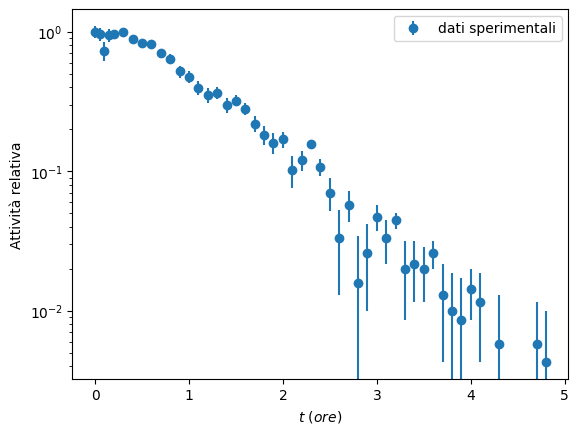

In [ ]:
dati1p = dati1[dati1[:,2] > 0, :]
plt.errorbar(dati1p[:,ut], dati1p[:,2], yerr=dati1p[:,3], marker='o', fmt='', linestyle='', label='dati sperimentali')
plt.legend()
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività relativa")
plt.yscale('log')

## Fit a due step: Pb - PoBi (analitica, vincolo da funz su nz1)

Il valore tabulato per Pb214 è lambda_Pb = 1.54h-1
nz1 = 188407.33


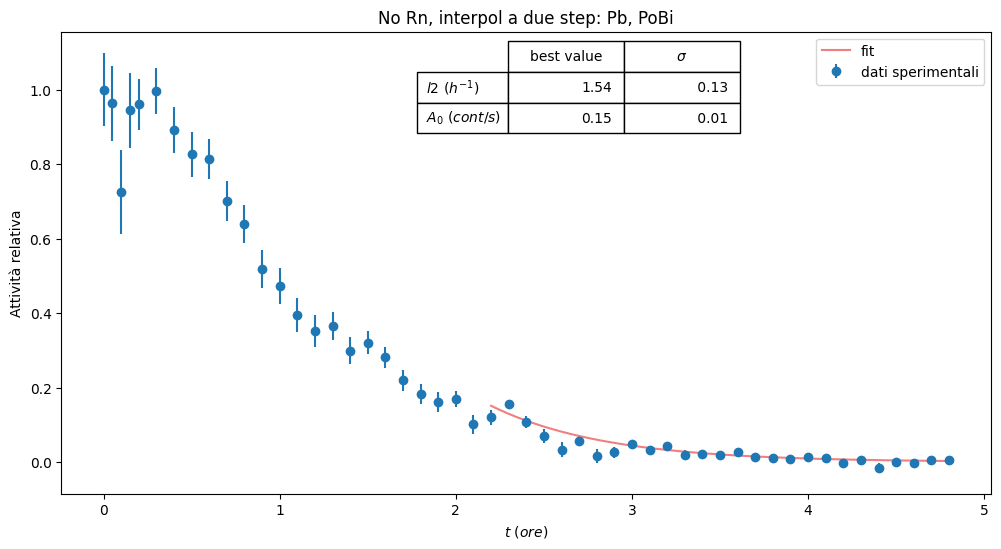

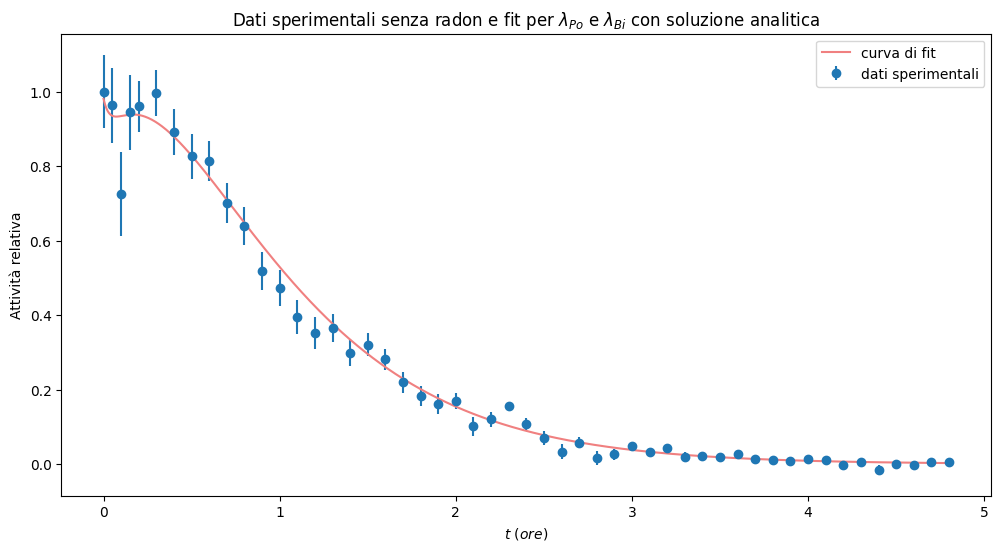

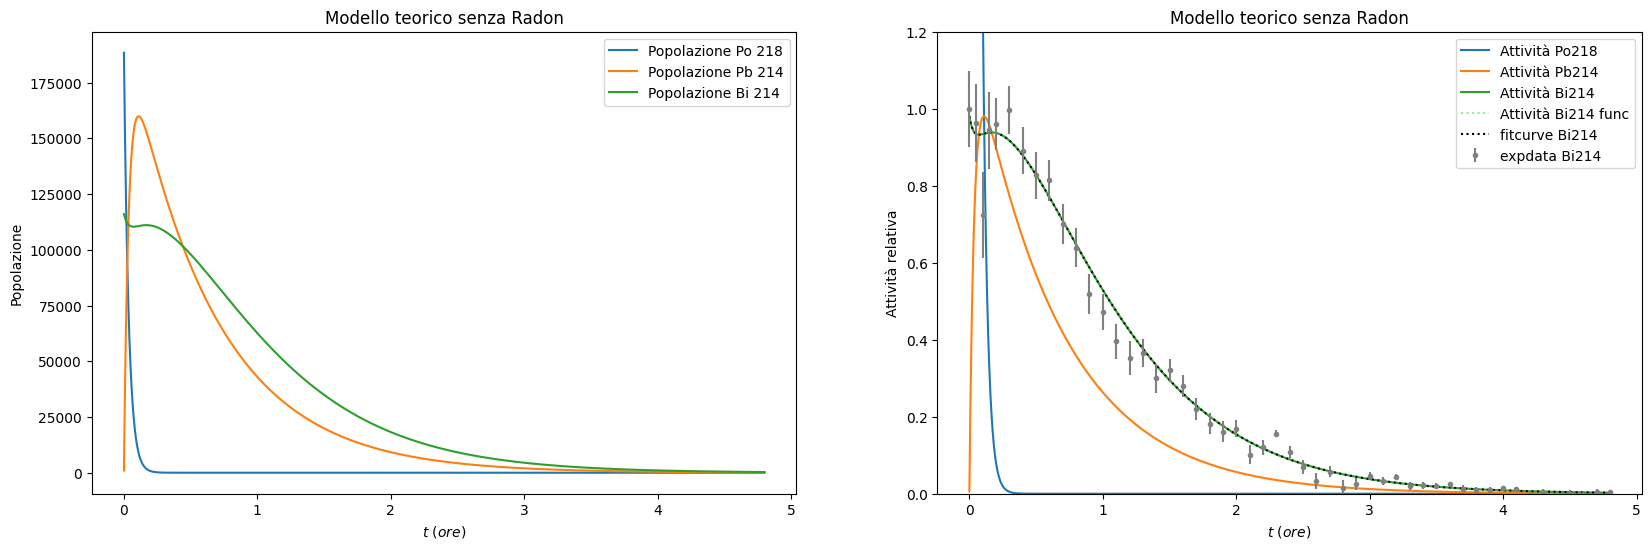

In [ ]:
#@title
# usa dati in ore o secondi dipendentemente da ut (se 0 ore, se 1 secondi)
# dati conteggi bismuto, no radon
# catena formata da Po218, Pb214, Bi214 (e Po214)

dati1=np.loadtxt('/content/drive/MyDrive/Tesi/DatiSperimentali/EqTran/Dati2_Bateman.txt', dtype=float, delimiter="\t", skiprows=0)
# !rm -r /content/drive.google.com
# dati in quattro colonne, formato    t (min) \ t (s) \ n cont \ inc cont
dati1[:,0] = dati1[:,0]/60       #     t (h)      "        "        "
ut = 0        # colonna da usare per le unità di tempo: 0 == ore, 1 == secondi          tenere 0
tmin = 2.2   # ore, limite inferiore per il fit su l2
tmax1 = dati1[-1,ut]
tmax2 = tmax1   # ore, limite superiore per il fit su l1 e l3
A3_0 = dati1[0,2]
dati1[:,3] = dati1[:,3]/A3_0
dati1[:,2] = dati1[:,2]/A3_0
#dati1 = dati1[dati1[:,2] > 0, :]
dati2 = dati1[dati1[:,0] >= tmin,  :]
dati3 = dati1[dati1[:,0] <= tmax2, :]

# fit dell'esponenziale asintotico per l2
# fit esponenziale per t >= tmin

def esp(tesp, l, A0):
  As = A0*np.exp(-l*(tesp-tmin))
  return As
espv = np.vectorize(esp)

min=[1e-6, 0]/(pow(3600,ut)*np.ones(2))       # minimum values for lRn, ARn0
max=[1000, mt.inf]/(pow(3600,ut)*np.ones(2))  # maximum values for lRn, ARn0
p0 =[1/pow(3600,ut)]
p0 =np.hstack((p0, 1))
bounds=(min,max)
popt,  pcov = sop.curve_fit(espv, dati2[:,0], dati2[:,2], p0=p0, sigma=dati2[:,3])
ndata = len(dati2[:,0])
#l2 = popt[0]
l2 = round(popt[0], 2)
A0 = popt[1]
standard_error1 = np.sqrt(np.diag(pcov))
sigma = np.sqrt(ndata*np.diag(pcov))

tf = np.linspace(tmin, tmax1, num=1000)

plt.figure(figsize=(12,6))
#plt.figure(figsize=(20,6))
#plt.subplot(121)
plt.errorbar(dati1[:,ut], dati1[:,2], yerr=dati1[:,3], marker='o', fmt='', linestyle='', label='dati sperimentali')
plt.plot(tf, espv(tf, l2, A0), color='lightcoral', label='fit')
plt.legend()
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività relativa")
plt.title("No Rn, interpol a due step: Pb, PoBi")
# tabella parametri fit
rows = [r"$ l2 \ (h^{-1})$", r"$ A_0 \ (cont/s)$"]
cols = [r"best value", r"$ \sigma $"]
w, h = 2, 2
O = [[0 for x in range(w)] for y in range(h)]
for h in range(0,2):
  O[h][0]="%4.2f"%(popt[h])
  O[h][1]="%5.2f"%(standard_error1[h])
  #O[h][1]="%5.2f"%(sigma[h])
plt.table(cellText=O[:], rowLabels=rows, colLabels=cols,loc='top', bbox=[0.48,0.78,0.25,0.2])

print('Il valore tabulato per Pb214 è lambda_Pb = 1.54h-1')

#l2 = 1.54

A0 = A0*A3_0*pow(3600,1-ut)
# parametri di fit l3, nz2, nz3 con lam1 tabulato e l2 da fit precedente

# fit A3
def eq3(ts, l1, l3, nz2, nz3):
  nz1= ((l2-l1)/l1)*(nz2-((l3-l2)/(l2*l3))*A0*np.exp(l2*tmin))
  n3 = (l1*l2/((l2-l1)*(l3-l1)))*nz1*np.exp(-l1*ts) + (l2/(l3-l2))*(nz2-(l1/(l2-l1))*nz1)*np.exp(-l2*ts) + (nz3-(l2/(l3-l2))*nz2+(l1*l2/((l3-l2)*(l3-l1)))*nz1)*np.exp(-l3*ts)
  A3 = l3*n3                           # attività in cont/h se ut=0, in cont/s se ut=1
  A3 = A3/pow(3600,1-ut)               # attività in cont/s come dati sperimentali [l3*n3]=[cont/h]=[cont/(3600s)]
  A3 = A3/A3_0                         # attività relativa
  return A3
eq3v = np.vectorize(eq3)

min=[10, 0.2]/(pow(3600,ut)*np.ones(2))                  # minimum values for l1, l3, nz2, nz3
min = np.hstack((min, [1000, 1000]))
max=[50, 15]/(pow(3600,ut)*np.ones(2))                    # maximum values for l1, l3, nz2, nz3
max = np.hstack((max, [mt.inf, mt.inf]))
bounds=(min,max)
p0 = [13.43,2.109]/(pow(3600,ut)*np.ones(2))              # guess iniziali
p0 = np.hstack((p0, [88e3,116e3]))                                                                        # p0=[13.43,2.109,1700,1600,1800]
popt,  pcov = sop.curve_fit(eq3, dati3[:,ut], dati3[:,2], p0=p0, sigma=dati3[:,3], bounds=bounds)
ndata = len(dati3[:,0])
l1 = popt[0]
l3 = popt[1]
nz2= popt[2]
nz3= popt[3]
nz1 = ((l2-l1)/l1)*(nz2-((l3-l2)/(l2*l3))*A0*np.exp(l2*tmin))
standard_error1 = np.sqrt(np.diag(pcov))
sigma = np.sqrt(ndata*np.diag(pcov))

print("nz1 = %5.2f" %nz1)

# calcolo il coefficiente R2 per valutare la bontà del fit
ts = dati3[:,ut]
y  = dati3[:,2]
tfit = np.linspace(0, tmax2, num=1000)
residuals = y - eq3(ts,popt[0],popt[1],popt[2],popt[3])
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y-np.mean(y))**2)
r_squared_1 = 1 - (ss_res / ss_tot)

plt.figure(figsize=(12,6))
#plt.subplot(122)
plt.errorbar(dati3[:,ut], dati3[:,2], yerr=dati3[:,3], marker='o', fmt='', linestyle='', label='dati sperimentali')
plt.plot(tfit, eq3(tfit,l1,l3,nz2,nz3), color='lightcoral', label='curva di fit')
plt.legend()
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività relativa")
plt.title("Dati sperimentali senza radon e fit per $\lambda_{Po}$ e $\lambda_{Bi}$ con soluzione analitica")

'''
# tabella parametri fit
rows = [r"$l1 (h^{-1})$", r"$l3 (h^{-1})$", r"$nz2$", r"$nz3$"]
cols = [r"best value", r"$ \sigma $", r"guess iniz"]
w, h = 3, 4
O = [[0 for x in range(w)] for y in range(h)]
for h in range(0,4):
  O[h][0]="%6.2f"%(popt[h])
  O[h][1]="%6.2f"%(standard_error1[h])
  O[h][2]="%6.2f"%(p0[h])
  #O[h][1]="%5.4f"%(sigma[h])
plt.table(cellText=O[:], rowLabels=rows, colLabels=cols,loc='top', bbox=[0.4,0.71,0.38,0.27])
'''

Nt = 10000     # numero osservazioni temporali
t = np.linspace(0, tmax2, Nt)

N1 = np.zeros(Nt)
N2 = np.zeros(Nt)
N3 = np.zeros(Nt)
dN1dt = np.zeros(Nt)
dN2dt = np.zeros(Nt)
dN3dt = np.zeros(Nt)
A1 = np.zeros(Nt)
A2 = np.zeros(Nt)
A3 = np.zeros(Nt)

N1[0] = nz1
N2[0] = nz2
N3[0] = nz3

for i in range(0,Nt-1):
  dN1dt[i] = -l1*N1[i]
  dN2dt[i] = -l2*N2[i]+l1*N1[i]
  dN3dt[i] = -l3*N3[i]+l2*N2[i]
  A1[i] = l1*N1[i]/pow(3600,1-ut)
  A2[i] = l2*N2[i]/pow(3600,1-ut)
  A3[i] = l3*N3[i]/pow(3600,1-ut)
  N1[i+1] = N1[i]+dN1dt[i]*tmax2/(Nt-1)
  N2[i+1] = N2[i]+dN2dt[i]*tmax2/(Nt-1)
  N3[i+1] = N3[i]+dN3dt[i]*tmax2/(Nt-1)
dN1dt[Nt-1] = -l1*N1[Nt-1]
dN2dt[Nt-1] = -l2*N2[Nt-1]+l1*N1[Nt-1]
dN3dt[Nt-1] = -l3*N3[Nt-1]+l2*N2[Nt-1]
A1[Nt-1] = l1*N1[Nt-1]/pow(3600,1-ut)
A2[Nt-1] = l2*N2[Nt-1]/pow(3600,1-ut)
A3[Nt-1] = l3*N3[Nt-1]/pow(3600,1-ut)

plt.figure(figsize=(20,6))
plt.subplot(121)
plt.plot(t, N1, label='Popolazione Po 218')
plt.plot(t, N2, label='Popolazione Pb 214')
plt.plot(t, N3, label='Popolazione Bi 214')
plt.title("Modello teorico senza Radon")
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Popolazione")
plt.legend()
#plt.yscale('log')

Nt3 = (l1*l2/((l2-l1)*(l3-l1)))*nz1*np.exp(-l1*t) + (l2/(l3-l2))*(nz2-(l1/(l2-l1))*nz1)*np.exp(-l2*t) + (nz3-(l2/(l3-l2))*nz2+(l1*l2/((l3-l2)*(l3-l1)))*nz1)*np.exp(-l3*t)
At3 = l3*Nt3                           # attività in cont/h se ut=0, in cont/s se ut=1
At3 = At3/pow(3600,1-ut)               # attività in cont/s come dati sperimentali [l3*n3]=[cont/h]=[cont/(3600s)]

plt.subplot(122)
plt.plot(t, A1/A3_0, label='Attività Po218')
plt.plot(t, A2/A3_0, label='Attività Pb214')
plt.plot(t, A3/A3_0, label='Attività Bi214')
plt.plot(t, At3/A3_0, color='lightgreen', label='Attività Bi214 func', ls=':')
plt.plot(tfit, eq3(tfit,l1,l3,nz2,nz3), color='black', label='fitcurve Bi214', ls=':')
plt.errorbar(dati3[:,ut], dati3[:,2], yerr=dati3[:,3], marker='.', fmt='', linestyle='', label='expdata Bi214', color='grey')
plt.title("Modello teorico senza Radon")
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività relativa")
plt.legend()
plt.ylim([0, 1.2])
#plt.yscale('log')

# To avoid matplotlib text output
plt.show()

## Fit a due step: Pb - PoBi (vincolo da funz su l1)

Il valore tabulato per Pb214 è lambda_Pb = 1.54h-1


<ipython-input-28-b82bef6903ad>:80: RuntimeWarning: overflow encountered in scalar multiply
  f1 = -l1*Nm1         # = dN1/dt
<ipython-input-28-b82bef6903ad>:81: RuntimeWarning: overflow encountered in scalar multiply
  f2 = -l2*Nm2+l1*Nm1
<ipython-input-28-b82bef6903ad>:81: RuntimeWarning: invalid value encountered in scalar add
  f2 = -l2*Nm2+l1*Nm1
<ipython-input-28-b82bef6903ad>:86: ODEintWarning: Excess accuracy requested (tolerances too small). Run with full_output = 1 to get quantitative information.
  N  = integrate.odeint(funct,Nz,t)


l1 = 72.77 h-1


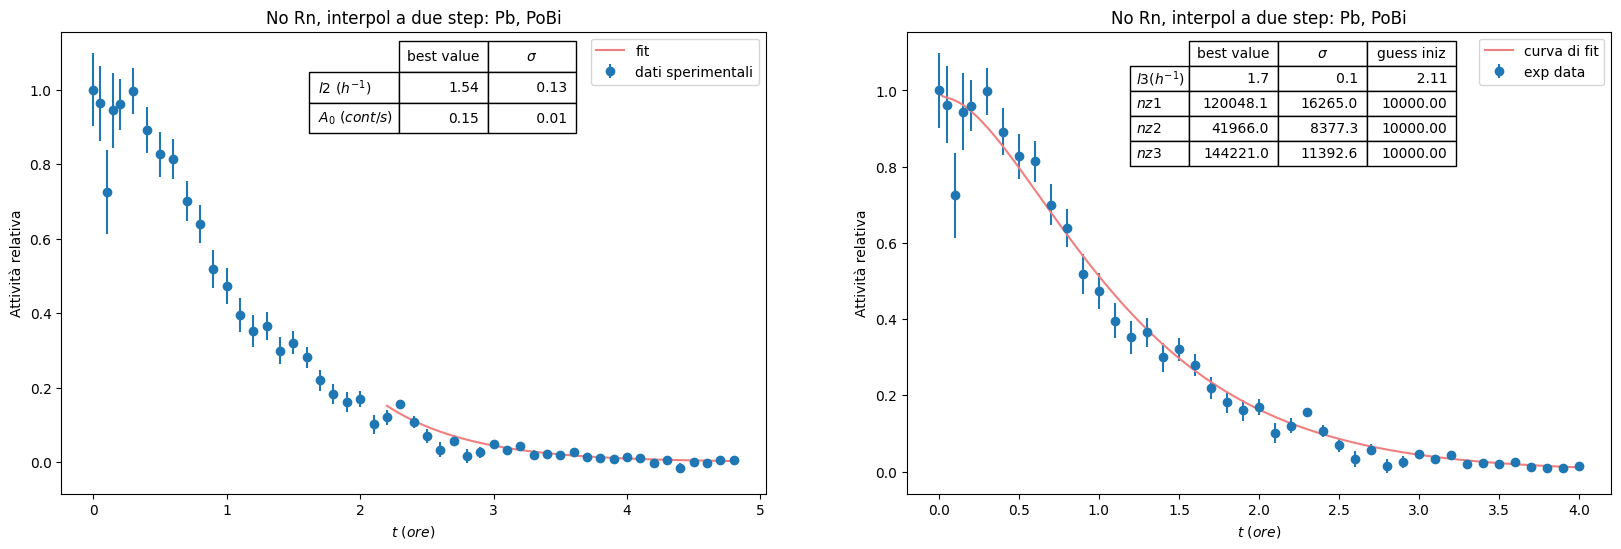

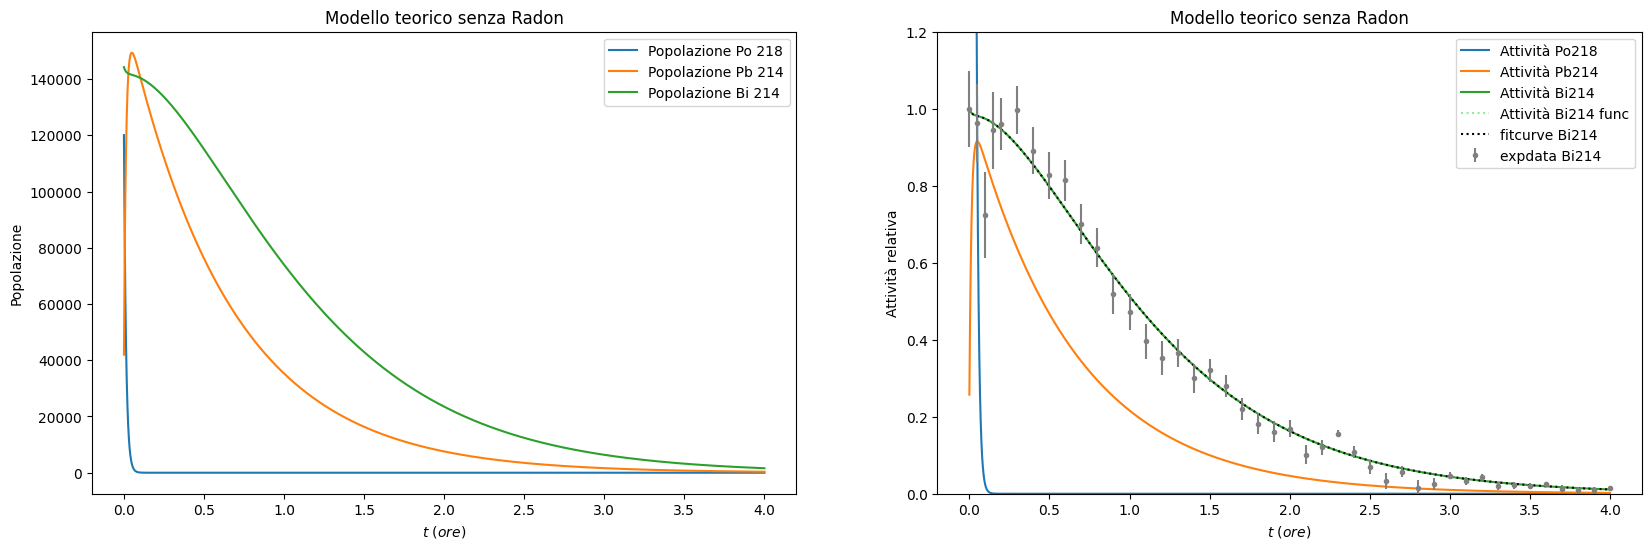

In [ ]:
#@title
# usa dati in ore o secondi dipendentemente da ut (se 0 ore, se 1 secondi)
# dati conteggi bismuto, no radon
# catena formata da Po218, Pb214, Bi214 (e Po214)

dati1=np.loadtxt('/content/drive/MyDrive/Tesi/DatiSperimentali/EqTran/Dati2_Bateman.txt', dtype=float, delimiter="\t", skiprows=0)
# !rm -r /content/drive.google.com
# dati in quattro colonne, formato    t (min) \ t (s) \ n cont \ inc cont
dati1[:,0] = dati1[:,0]/60       #     t (h)      "        "        "
ut = 0        # colonna da usare per le unità di tempo: 0 == ore, 1 == secondi          tenere 0
tmin = 2.2   # ore, limite inferiore per il fit su l2
tmax1 = dati1[-1,ut]
tmax2 = 4   # ore, limite inferiore per il fit su l1 e l3
A3_0 = dati1[0,2]
dati1[:,3] = dati1[:,3]/A3_0
dati1[:,2] = dati1[:,2]/A3_0
#dati1 = dati1[dati1[:,2] > 0, :]
dati2 = dati1[dati1[:,0] >= tmin,  :]
dati3 = dati1[dati1[:,0] <= tmax2, :]

# fit dell'esponenziale asintotico per l2
# fit esponenziale per t >= tmin

def esp(tesp, l, A0):
  As = A0*np.exp(-l*(tesp-tmin))
  return As
espv = np.vectorize(esp)

min=[1e-6, 0]/(pow(3600,ut)*np.ones(2))       # minimum values for lRn, ARn0
max=[1000, mt.inf]/(pow(3600,ut)*np.ones(2))  # maximum values for lRn, ARn0
p0 =[1/pow(3600,ut)]
p0 =np.hstack((p0, 1))
bounds=(min,max)
popt,  pcov = sop.curve_fit(espv, dati2[:,0], dati2[:,2], p0=p0, sigma=dati2[:,3])
ndata = len(dati2[:,0])
#l2 = popt[0]
l2 = round(popt[0], 2)
A0 = popt[1]
standard_error1 = np.sqrt(np.diag(pcov))
sigma = np.sqrt(ndata*np.diag(pcov))

tf = np.linspace(tmin, tmax1, num=1000)

plt.figure(figsize=(20,6))
plt.subplot(121)
plt.errorbar(dati1[:,ut], dati1[:,2], yerr=dati1[:,3], marker='o', fmt='', linestyle='', label='dati sperimentali')
plt.plot(tf, espv(tf, l2, A0), color='lightcoral', label='fit')
plt.legend()
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività relativa")
plt.title("No Rn, interpol a due step: Pb, PoBi")
# tabella parametri fit
rows = [r"$ l2 \ (h^{-1})$", r"$ A_0 \ (cont/s)$"]
cols = [r"best value", r"$ \sigma $"]
w, h = 2, 2
O = [[0 for x in range(w)] for y in range(h)]
for h in range(0,2):
  O[h][0]="%4.2f"%(popt[h])
  O[h][1]="%5.2f"%(standard_error1[h])
  #O[h][1]="%5.2f"%(sigma[h])
plt.table(cellText=O[:], rowLabels=rows, colLabels=cols,loc='top', bbox=[0.48,0.78,0.25,0.2])

print('Il valore tabulato per Pb214 è lambda_Pb = 1.54h-1')

#l2 = 1.54

# parametri di fit l3, nz1, nz2, nz3 e l2 da fit precedente

A0 = A0*A3_0*pow(3600,1-ut)
def eq3(ts, l3, nz1, nz2, nz3):
     #-time-grid-----------------------------------
     t  = np.linspace(0, tmax2, 100000)                            # per opzione interpolazione si può usare questo
     l1 = l2/(1+(nz2/(nz2-(l3-l2)*A0*np.exp(l2*tmin)/(l2*l3))))
     #differential-eq-system----------------------
     def funct(y,t):
        Nm1=y[0]
        Nm2=y[1]
        Nm3=y[2]
        # the model equations
        f1 = -l1*Nm1         # = dN1/dt
        f2 = -l2*Nm2+l1*Nm1
        f3 = -l3*Nm3+l2*Nm2
        return [f1, f2, f3]
     #integrate------------------------------------
     Nz = nz1,nz2,nz3
     N  = integrate.odeint(funct,Nz,t)

     #opzione interpolazione
     N3 = N[:,2]
     N3f= itp.interp1d(t,N3,'cubic',fill_value="extrapolate")
     n3 = N3f(ts)

     #A1 = l1*n[:,0]
     #A2 = l2*n[:,1]
     A3 = l3*n3                           # attività in cont/h se ut=0, in cont/s se ut=1
     A3 = A3/pow(3600,1-ut)               # attività in cont/s come dati sperimentali [l3*n3]=[cont/h]=[cont/(3600s)]
     A3 = A3/A3_0                         # attività relativa
     return (A3)
eq3v=np.vectorize(eq3)

''' non funziona
def eq3(ts, l1, l3, nz2, nz3):
    nz1 = ((l2-l1)/l1)*(nz2-((l3-l2)/(l2*l3))*A0*np.exp(l2*tmin))
    Nt3 = (l1*l2/((l2-l1)*(l3-l1)))*nz1*np.exp(-l1*ts) + (l2/(l3-l2))*(nz2-(l1/(l2-l1))*nz1)*np.exp(-l2*ts) + (nz3-(l2/(l3-l2))*nz2+(l1*l2/((l3-l2)*(l3-l1)))*nz1)*np.exp(-l3*ts)
    At3 = l3*Nt3                           # attività in cont/h se ut=0, in cont/s se ut=1
    Ar3 = At3/A3_0                         # attività relativa
    return (Ar3)
eq3v=np.vectorize(eq3)
'''

min=[1]/(pow(3600,ut)*np.ones(1))                  # minimum values for l3, nz1, nz2, nz3
min = np.hstack((min, [1000, 1000, 1000]))
max=[7]/(pow(3600,ut)*np.ones(1))                    # maximum values for l3, nz1, nz2, nz3
max = np.hstack((max, [mt.inf, mt.inf, mt.inf]))
bounds=(min,max)
p0 = [2.109]/(pow(3600,ut)*np.ones(1))              # guess iniziali
p0 = np.hstack((p0, [1e4,1e4,1e4]))                                                                        # p0=[13.43,2.109,1700,1600,1800]
popt,  pcov = sop.curve_fit(eq3, dati3[:,ut], dati3[:,2], p0=p0, sigma=dati3[:,3], bounds=bounds)
ndata = len(dati3[:,0])
l3 = popt[0]
nz1= popt[1]
nz2= popt[2]
nz3= popt[3]
l1 = l2/(1+(nz2/(nz2-(l3-l2)*A0*np.exp(l2*tmin)/(l2*l3))))
standard_error1 = np.sqrt(np.diag(pcov))
sigma = np.sqrt(ndata*np.diag(pcov))

print("l1 = %5.2f h-1" %l1)

# calcolo il coefficiente R2 per valutare la bontà del fit
ts = dati3[:,ut]
y  = dati3[:,2]
tfit = np.linspace(0, tmax2, num=1000)
residuals = y - eq3(ts,popt[0],popt[1],popt[2],popt[3])
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y-np.mean(y))**2)
r_squared_1 = 1 - (ss_res / ss_tot)


plt.subplot(122)
plt.errorbar(dati3[:,ut], dati3[:,2], yerr=dati3[:,3], marker='o', fmt='', linestyle='', label='exp data')
plt.plot(tfit, eq3(tfit,l3,nz1,nz2,nz3), color='lightcoral', label='curva di fit')
plt.legend()
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività relativa")
#plt.title("Dati sperimentali e fit senza Radon")
plt.title("No Rn, interpol a due step: Pb, PoBi")

# tabella parametri fit
rows = [r"$l3 (h^{-1})$", r"$nz1$", r"$nz2$", r"$nz3$"]
cols = [r"best value", r"$ \sigma $", r"guess iniz"]
w, h = 3, 4
O = [[0 for x in range(w)] for y in range(h)]
for h in range(0,4):
  O[h][0]="%6.1f"%(popt[h])
  O[h][1]="%6.1f"%(standard_error1[h])
  O[h][2]="%6.2f"%(p0[h])
  #O[h][1]="%5.4f"%(sigma[h])
plt.table(cellText=O[:], rowLabels=rows, colLabels=cols,loc='top', bbox=[0.4,0.71,0.38,0.27])


Nt = 10000     # numero osservazioni temporali
t = np.linspace(0, tmax2, Nt)

N1 = np.zeros(Nt)
N2 = np.zeros(Nt)
N3 = np.zeros(Nt)
dN1dt = np.zeros(Nt)
dN2dt = np.zeros(Nt)
dN3dt = np.zeros(Nt)
A1 = np.zeros(Nt)
A2 = np.zeros(Nt)
A3 = np.zeros(Nt)

N1[0] = nz1
N2[0] = nz2
N3[0] = nz3

for i in range(0,Nt-1):
  dN1dt[i] = -l1*N1[i]
  dN2dt[i] = -l2*N2[i]+l1*N1[i]
  dN3dt[i] = -l3*N3[i]+l2*N2[i]
  A1[i] = l1*N1[i]/pow(3600,1-ut)
  A2[i] = l2*N2[i]/pow(3600,1-ut)
  A3[i] = l3*N3[i]/pow(3600,1-ut)
  N1[i+1] = N1[i]+dN1dt[i]*tmax2/(Nt-1)
  N2[i+1] = N2[i]+dN2dt[i]*tmax2/(Nt-1)
  N3[i+1] = N3[i]+dN3dt[i]*tmax2/(Nt-1)
dN1dt[Nt-1] = -l1*N1[Nt-1]
dN2dt[Nt-1] = -l2*N2[Nt-1]+l1*N1[Nt-1]
dN3dt[Nt-1] = -l3*N3[Nt-1]+l2*N2[Nt-1]
A1[Nt-1] = l1*N1[Nt-1]/pow(3600,1-ut)
A2[Nt-1] = l2*N2[Nt-1]/pow(3600,1-ut)
A3[Nt-1] = l3*N3[Nt-1]/pow(3600,1-ut)

plt.figure(figsize=(20,6))
plt.subplot(121)
plt.plot(t, N1, label='Popolazione Po 218')
plt.plot(t, N2, label='Popolazione Pb 214')
plt.plot(t, N3, label='Popolazione Bi 214')
plt.title("Modello teorico senza Radon")
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Popolazione")
plt.legend()
#plt.yscale('log')

Nt3 = (l1*l2/((l2-l1)*(l3-l1)))*nz1*np.exp(-l1*t) + (l2/(l3-l2))*(nz2-(l1/(l2-l1))*nz1)*np.exp(-l2*t) + (nz3-(l2/(l3-l2))*nz2+(l1*l2/((l3-l2)*(l3-l1)))*nz1)*np.exp(-l3*t)
At3 = l3*Nt3                           # attività in cont/h se ut=0, in cont/s se ut=1
At3 = At3/pow(3600,1-ut)               # attività in cont/s come dati sperimentali [l3*n3]=[cont/h]=[cont/(3600s)]

plt.subplot(122)
plt.plot(t, A1/A3_0, label='Attività Po218')
plt.plot(t, A2/A3_0, label='Attività Pb214')
plt.plot(t, A3/A3_0, label='Attività Bi214')
plt.plot(t, At3/A3_0, color='lightgreen', label='Attività Bi214 func', ls=':')
plt.plot(tfit, eq3(tfit,l3,nz1,nz2,nz3), color='black', label='fitcurve Bi214', ls=':')
plt.errorbar(dati3[:,ut], dati3[:,2], yerr=dati3[:,3], marker='.', fmt='', linestyle='', label='expdata Bi214', color='grey')
plt.title("Modello teorico senza Radon")
plt.xlabel(r"$ t \ (ore)$")
plt.ylabel(r"Attività relativa")
plt.legend()
plt.ylim([0, 1.2])
#plt.yscale('log')

# To avoid matplotlib text output
plt.show()

# Dati sperimentali, con Radon

In [ ]:
#@title
# dati conteggi bismuto, con radon

path = '/content/drive/MyDrive/Tesi/DatiSperimentali/EqSec/DatiAlcool_Radon/'
filelist = os.listdir(path)

dtRn = np.array([[None, None, None, None]])

# Make empty list to store all paths to subdirectories in
path2 = []
for x in filelist:
    path2.append(path + x + '/')
# print(path2)
k = 0                             # counter sulle righe
for i in path2:
    filelist2 = os.listdir(i)
    for j in filelist2:
        if j.endswith('.Chn'):
          a = 1                   # serve solo a ignorare gli spettri
        else:
          file = pd.read_csv(i+j, sep="\t", header = [0])
          head = file.columns
          head = head.str.replace("-", " ")
          head = head.str.replace(":", " ")
          head = head[0].split()
          #print(head)
          tinz = (float(head[3])-12) + (float(head[7])-10)/24 + (float(head[8])-14)/(24*60) + (float(head[9])-23)/(24*3600)     # t di osserv in giorni
          lvtm = float(head[15])             # live time in secondi
          #print(tinz)
          #print(lvtm)
          fil1 = pd.read_csv(i+j, sep="\t", header = [4])
          data = fil1.columns
          data = data[0].split()
          netc = np.array([[ float(data[4])/lvtm, float(data[5])/lvtm ]]).astype(float)   # conteggi netti e inc, normalizzati al livetime
          #print(netc)
          dtRn = np.append(dtRn, [[tinz, lvtm, netc[0,0], netc[0,1]]], 0).astype(float)
          #print(dtRn)

dtRn = np.delete(dtRn, (0), axis=0)     # rimuove la riga di None che darebbe problemi con errorbar
#print(dtRn)

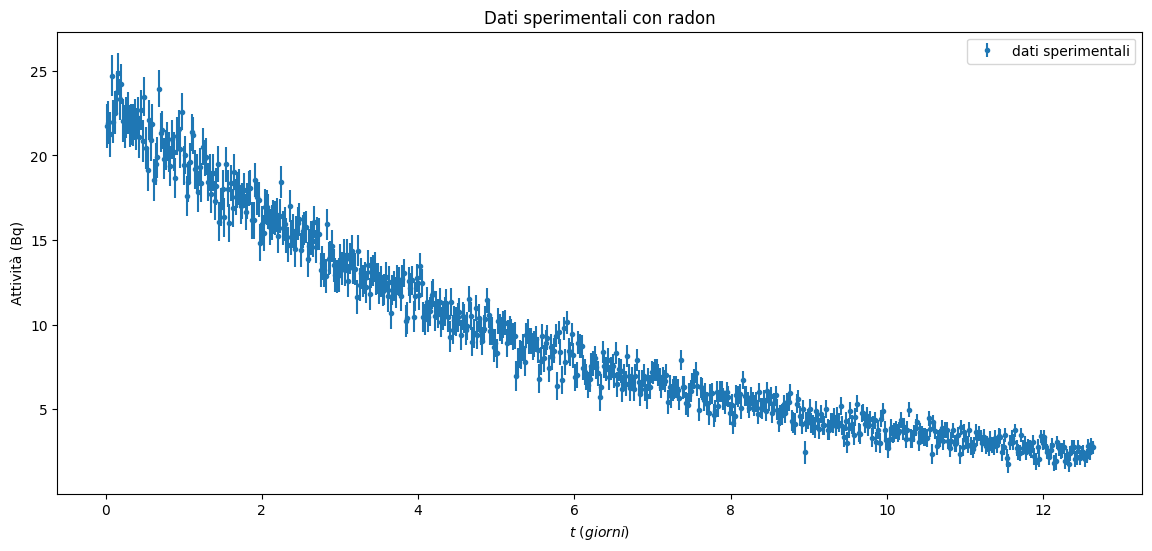

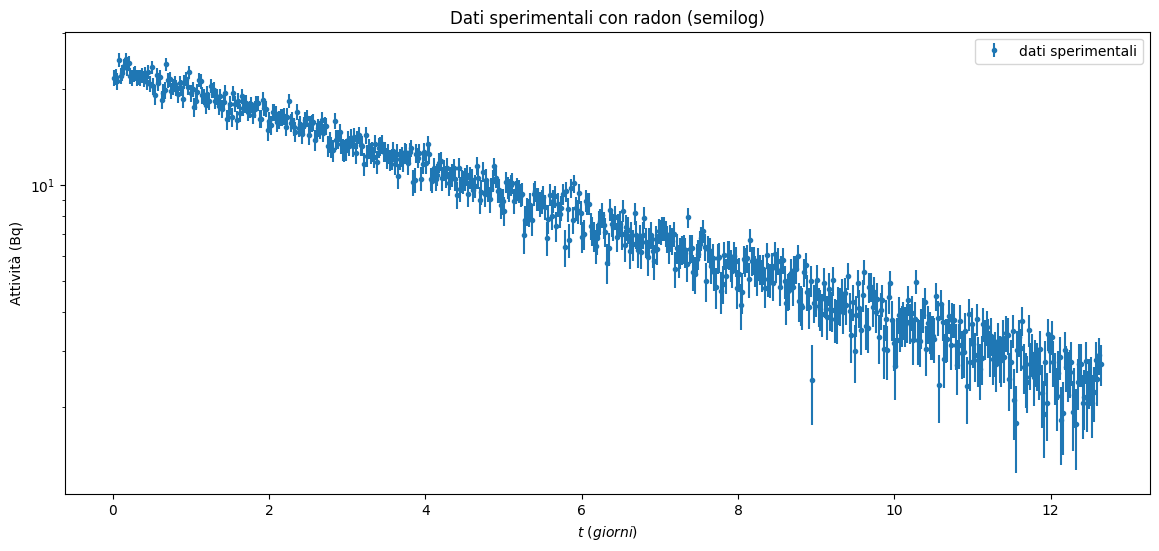

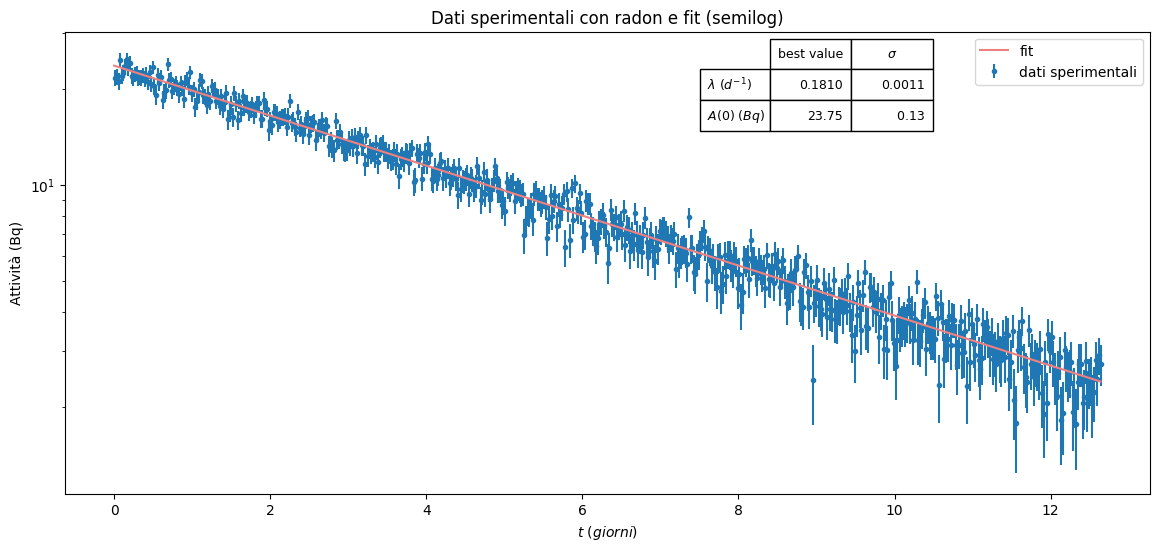

Il valore tabulato è lambda_Rn = 0.181gg-1


In [ ]:
#@title
# fit e grafici

gmin = 3.3    # giorni, limite inferiore per il tempo per il fit

dtRn2 = dtRn[dtRn[:,0] >= gmin, :]
# convert list to numpy array
arrn = np.array(dtRn2[:,0])

# fit esponenziale
def espRn(ts, lRn, ARn0):
  AsRn = ARn0*np.exp(-lRn*(ts-gmin))
  return AsRn
espRnv = np.vectorize(espRn)

'''
#fit lineare
def linRn(ts, lRn, lnARn0):
  lnAsRn = lnARn0 - lRn*(ts-gmin)
  return lnAsRn
linRnv = np.vectorize(linRn)
'''

min=[1e-6, 0]       # minimum values for lRn, ARn0
max=[1000, mt.inf]  # maximum values for lRn, ARn0
bounds=(min,max)
popt,  pcov = sop.curve_fit(espRnv, dtRn2[:,0], dtRn2[:,2], p0=[0.18,45], sigma=dtRn2[:,3])
ndata = len(dtRn[:,0])
lRn = popt[0]
ARn0= popt[1]
standard_error1 = np.sqrt(np.diag(pcov))
sigma = np.sqrt(ndata*np.diag(pcov))

# find max value in column 0
gmax = np.max(arrn)
tfRn = np.linspace(gmin, gmax, num=1000)

plt.figure(figsize=(14,6))
plt.errorbar(dtRn2[:,0]-gmin, dtRn2[:,2], yerr=dtRn2[:,3], marker='.', fmt='', linestyle='', label='dati sperimentali', zorder=-1)
plt.legend()
plt.xlabel(r"$ t \ (giorni)$")
plt.ylabel(r"Attività (Bq)")
plt.title("Dati sperimentali con radon")

'''
plt.figure(figsize=(14,6))
plt.errorbar(dtRn2[:,0]-gmin, dtRn2[:,2], yerr=dtRn2[:,3], marker='.', fmt='', linestyle='', label='dati sperimentali', zorder=-1)
plt.plot(tfRn-gmin, espRnv(tfRn, lRn, ARn0), color='lightcoral', label='fit')
plt.legend()
plt.xlabel(r"$ t \ (giorni)$")
plt.ylabel(r"Conteggi al secondo")
plt.title("Dati sperimentali con Radon")
# tabella parametri fit
rows = [r"$ l_{Rn} \ (d^{-1})$", r"$ A_{Rn}(t=0) \ (cont/s)$"]
cols = [r"best value", r"$ \sigma $"]
w, h = 2, 2
O = [[0 for x in range(w)] for y in range(h)]
"""
for h in range(0,2):
  O[h][0]="%4.3f"%(popt[h])
  O[h][1]="%5.3f"%(standard_error1[h])
  #O[h][1]="%5.4f"%(sigma[h])
"""
O[0][0]="%4.4f"%(popt[0])
O[0][1]="%5.4f"%(standard_error1[0])
O[1][0]="%4.2f"%(popt[1])
O[1][1]="%5.2f"%(standard_error1[1])
plt.table(cellText=O[:], rowLabels=rows, colLabels=cols,loc='top', bbox=[0.5,0.77,0.25,0.2])
'''
'''
plt.figure(figsize=(14,6))
plt.errorbar(dtRn2[:,0]-gmin, np.log(dtRn2[:,2]), yerr=np.log(np.absolute(dtRn2[:,3])), marker='.', fmt='', linestyle='', label='dati sperimentali', zorder=-1)
#plt.plot(tfRn-gmin, espRnv(tfRn, lRn, ARn0), color='lightcoral', label='fit')
plt.legend()
plt.xlabel(r"$ t \ (giorni)$")
plt.ylabel(r"Conteggi al secondo")
plt.title("Dati sperimentali con Radon")
'''

plt.figure(figsize=(14,6))
plt.errorbar(dtRn2[:,0]-gmin, dtRn2[:,2], yerr=dtRn2[:,3], marker='.', fmt='', linestyle='', label='dati sperimentali', zorder=-1)
plt.legend()
plt.xlabel(r"$ t \ (giorni)$")
plt.ylabel(r"Attività (Bq)")
plt.yscale('log')
plt.title("Dati sperimentali con radon (semilog)")

plt.figure(figsize=(14,6))
plt.errorbar(dtRn2[:,0]-gmin, dtRn2[:,2], yerr=dtRn2[:,3], marker='.', fmt='', linestyle='', label='dati sperimentali', zorder=-1)
plt.plot(tfRn-gmin, espRnv(tfRn, lRn, ARn0), color='lightcoral', label='fit')
plt.legend()
plt.xlabel(r"$ t \ (giorni)$")
plt.ylabel(r"Attività (Bq)")
plt.yscale('log')
plt.title("Dati sperimentali con radon e fit (semilog)")
# tabella parametri fit
rows = [r"$ \lambda \ (d^{-1})$", r"$ A(0) \ (Bq)$"]
cols = [r"best value", r"$ \sigma $"]
w, h = 2, 2
O = [[0 for x in range(w)] for y in range(h)]
'''
for h in range(0,2):
  O[h][0]="%4.3f"%(popt[h])
  O[h][1]="%5.3f"%(standard_error1[h])
  #O[h][1]="%5.4f"%(sigma[h])
'''
O[0][0]="%4.4f"%(popt[0])
O[0][1]="%5.4f"%(standard_error1[0])
O[1][0]="%4.2f"%(popt[1])
O[1][1]="%5.2f"%(standard_error1[1])
plt.table(cellText=O[:], rowLabels=rows, colLabels=cols,loc='top', bbox=[0.65,0.785,0.15,0.2])

plt.show()

#print('Il valore tabulato è' , sp.printing.latex(sp.symbols('lambda_{Rn}')), '=' , sp.printing.latex(sp.symbols('0.181gg**{-1}')))
print('Il valore tabulato è lambda_Rn = 0.181gg-1')

In [ ]:
#@title
'''
# fit e grafici

gmin = 3.2    # giorni, limite inferiore per il tempo per il fit

dtRn = dtRn[dtRn[:,0] >= gmin, :]

# fit esponenziale
def espRn(tesp, lRn, ARn0):
  AsRn = ARn0*np.exp(-lRn*(tesp))
  return AsRn
espRnv = np.vectorize(espRn)

min=[1e-6, 0]       # minimum values for lRn, ARn0
max=[1000, mt.inf]  # maximum values for lRn, ARn0
bounds=(min,max)
popt,  pcov = sop.curve_fit(espRnv, dtRn[:,0], dtRn[:,2], p0=[0.18,45], sigma=dtRn[:,3])
ndata = len(dtRn[:,0])
lRn = popt[0]
ARn0= popt[1]
standard_error1 = np.sqrt(np.diag(pcov))
sigma = np.sqrt(ndata*np.diag(pcov))

# convert list to numpy array
arrn = np.array(dtRn[:,0])
# find max value in column 0
tinmax = np.max(arrn)
tfRn = np.linspace(gmin, tinmax, num=1000)

plt.figure(figsize=(14,6))
plt.errorbar(dtRn[:,0]-gmin, dtRn[:,2], yerr=dtRn[:,3], marker='.', fmt='', linestyle='', label='dati sperimentali', zorder=-1)
plt.plot(tfRn-gmin, espRnv(tfRn, lRn, ARn0), color='lightcoral', label='fit')
plt.legend()
plt.xlabel(r"$ t \ (giorni)$")
plt.ylabel(r"Conteggi al secondo")
plt.title("Dati sperimentali con Radon")
# tabella parametri fit
rows = [r"$ l_{Rn} \ (gg^{-1})$", r"$ A_{Rn}(t=0) \ (cont/s)$"]
cols = [r"best value", r"$ \sigma $"]
w, h = 2, 2
O = [[0 for x in range(w)] for y in range(h)]
for h in range(0,2):
  O[h][0]="%4.4f"%(popt[h])
  O[h][1]="%5.4f"%(standard_error1[h])
  #O[h][1]="%5.4f"%(sigma[h])
plt.table(cellText=O[:], rowLabels=rows, colLabels=cols,loc='top', bbox=[0.5,0.77,0.25,0.2])

plt.figure(figsize=(14,6))
plt.errorbar(dtRn[:,0]-gmin, dtRn[:,2], yerr=dtRn[:,3], marker='.', fmt='', linestyle='', label='dati sperimentali', zorder=-1)
plt.plot(tfRn-gmin, espRnv(tfRn, lRn, ARn0), color='lightcoral', label='fit')
plt.legend()
plt.xlabel(r"$ t \ (giorni)$")
plt.ylabel(r"Conteggi al secondo")
plt.yscale('log')
plt.title("Dati sperimentali con Radon (Semilog)")
# tabella parametri fit
rows = [r"$ l_{Rn} \ (gg^{-1})$", r"$ A_{Rn}(t=0) \ (cont/s)$"]
cols = [r"best value", r"$ \sigma $"]
w, h = 2, 2
O = [[0 for x in range(w)] for y in range(h)]
for h in range(0,2):
  O[h][0]="%4.4f"%(popt[h])
  O[h][1]="%5.4f"%(standard_error1[h])
  #O[h][1]="%5.4f"%(sigma[h])
plt.table(cellText=O[:], rowLabels=rows, colLabels=cols,loc='top', bbox=[0.5,0.77,0.25,0.2])
plt.show()

#print('Il valore tabulato è' , sp.printing.latex(sp.symbols('lambda_{Rn}')), '=' , sp.printing.latex(sp.symbols('0.181gg**{-1}')))
print('Il valore tabulato è lambda_Rn = 0.181gg-1')
'''

'\n# fit e grafici\n\ngmin = 3.2    # giorni, limite inferiore per il tempo per il fit\n\ndtRn = dtRn[dtRn[:,0] >= gmin, :]\n\n# fit esponenziale\ndef espRn(tesp, lRn, ARn0):\n  AsRn = ARn0*np.exp(-lRn*(tesp))\n  return AsRn\nespRnv = np.vectorize(espRn)\n\nmin=[1e-6, 0]       # minimum values for lRn, ARn0\nmax=[1000, mt.inf]  # maximum values for lRn, ARn0\nbounds=(min,max)\npopt,  pcov = sop.curve_fit(espRnv, dtRn[:,0], dtRn[:,2], p0=[0.18,45], sigma=dtRn[:,3])\nndata = len(dtRn[:,0])\nlRn = popt[0]\nARn0= popt[1]\nstandard_error1 = np.sqrt(np.diag(pcov))\nsigma = np.sqrt(ndata*np.diag(pcov))\n\n# convert list to numpy array\narrn = np.array(dtRn[:,0])\n# find max value in column 0\ntinmax = np.max(arrn)\ntfRn = np.linspace(gmin, tinmax, num=1000)\n\nplt.figure(figsize=(14,6))\nplt.errorbar(dtRn[:,0]-gmin, dtRn[:,2], yerr=dtRn[:,3], marker=\'.\', fmt=\'\', linestyle=\'\', label=\'dati sperimentali\', zorder=-1)\nplt.plot(tfRn-gmin, espRnv(tfRn, lRn, ARn0), color=\'lightcoral\', labe